# CICESE - Foundations of Deep Learning
Assignment 2: CNN Architecture Design and Optimization

Instructor: Jesús Guillermo Falcón Cardona


Student: Javier Ramírez

---

### Table of Contents
1. [Setup and Imports](#setup)
2. [Part 1: Architectural Design and Theoretical Justification](#part1)
3. [Model Implementation](#implementation)
4. [Part 2: Experiments](#part2)
5. [Part 3: Analytical Discussion](#part3)
6. [Part 4: Engineering Constraint](#part4)
7. [Results Summary](#summary)


----

<a id='setup'></a>
## 1. Imports

In [10]:
# Standard library imports
import os
import sys
import time
import json
import csv
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

# Metrics and visualization
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Create directories for results
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)
(results_dir / 'csvs').mkdir(exist_ok=True)
(results_dir / 'figures').mkdir(exist_ok=True)
(results_dir / 'models').mkdir(exist_ok=True)


Using device: cuda
GPU: NVIDIA GeForce RTX 3060
CUDA Version: 12.8


## 1.1 Diseño

Se utilizaron dos arquitecturas de CNN para el conjunto de datos CIFAR-10, ambas siguen los mismos principios de diseño pero difieren en su escala y número de parámetros. 

La primera arquitectura, denominada Modelo A, supera el millón de parámetros, mientras que la segunda, Modelo B, se mantiene por debajo de los quinientos mil parámetros.

### Tamaños de kernel

En ambas arquitecturas se implementan kernels de tamaño 3×3, con capas de proyección 1×1. Esto por Simonyan & Zisserman (2014) en su trabajo sobre VGGNet, donde demostraron que el apilamiento de kernels pequeños permite obtener un campo receptivo equivalente al de kernels más grandes pero con una cantidad menor de parámetros [1]. Se menciona que, por ejemplo; que dos capas convolucionales de 3×3 generan un campo receptivo efectivo de 5×5, mientras que tres capas de 3×3 alcanzan un campo de 7×7, logrando además una mayor no-linealidad al incorporar funciones de activación adicionales. En términos de eficiencia paramétrica, una capa con kernel 3×3 requiere $(3 \times 3 \times C)$ parámetros frente a los $(5 \times 5 \times C)$ que necesitaría una capa con kernel 5×5.

Las capas de convolución 1×1, cumplen una función complementaria [2], ya que estas capas permiten realizar mezclas entre canales sin afectar las dimensiones espaciales, funcionan de cierta forma como mecanismos de reducción de dimensionalidad y aportan no-linealidad adicional sin necesidad de filtrado espacial. 

### Profundidad de la red

En cuanto a la profundidad, el Modelo A se construye con 12 capas convolucionales, mientras que el Modelo B incorpora 9 capas. 

No existe una fórmula exacta para determinar la profundidad óptima, ya que depende en gran medida del problema y del tipo de arquitectura, elegir el número de capas no es una decisión trivial, si se apilan más capas de las necesarias, el rendimiento teórico puede degradarse por problemas de optimización o sobreajuste y si se utilizan menos capas de las requeridas para representar la función del problema, el modelo tendrá una capacidad insuficiente y su rendimiento se verá limitado. Para esta práctica se seleccionaron profundidades de 9 y 12 capas principalmente para evitar modelos  grandes y computacionalmente costosos, además agregar unas cuantas capas adicionales incrementa significativamente el costo computacional a costa de una mejora o no, en el rendimiento.

El campo receptivo efectivo en Luo et al. (2016), menciona que este crece aproximadamente como $O(\sqrt{n})$, donde $n$ representa el número de capas. Con 9 a 12 capas y la inclusión de operaciones de submuestreo (pooling), el campo receptivo podría cubrir objetos de tamaño de los objetos en CIFAR-10. 


#### Campo Receptivo Teórico para CNN_ModelB_Small

Para la arquitectura más pequeña, que utiliza convoluciones 3×3 (stride=1) y operaciones de pooling 2×2, cada convolución con kernel $k$ aporta un incremento de $(k-1)$ multiplicado por el stride acumulado hasta ese punto.

Para calcular el campo receptivo en la capa $l$ es:

$$RF_{l} = RF_{l-1} + (k_l - 1) \times \prod_{i=1}^{l-1} s_i$$

donde $RF_{l-1}$ es el campo receptivo de la capa anterior, $k_l$ es el tamaño del kernel en la capa actual, y $s_i$ son los strides acumulados de las capas previas.

Para **CNN_ModelB_Small**:

**Bloque 1** (mantiene resolución de 32×32 hasta el pooling):
- Capa 1: Conv 3×3, stride=1 → $RF_1 = 3$
- Capa 2: Conv 1×1, stride=1 → $RF_2 = 3 + (1-1) \times 1 = 3$
- Capa 3: Conv 1×1, stride=1 → $RF_3 = 3 + (1-1) \times 1 = 3$
- MaxPool 2×2, stride=2 → El stride se multiplica por 2, y el campo receptivo se escala:
  $$RF_{\text{pool}} = RF_3 \times 2 = 3 \times 2 = 6$$

**Bloque 2** (resolución 16×16, stride acumulado = 2):
- Capa 4: Conv 3×3, stride=1 → $RF_4 = 6 + (3-1) \times 2 = 6 + 4 = 10$
- Capa 5: Conv 1×1, stride=1 → $RF_5 = 10 + (1-1) \times 2 = 10$
- Capa 6: Conv 1×1, stride=1 → $RF_6 = 10 + (1-1) \times 2 = 10$
- AvgPool 2×2, stride=2 → stride acumulado pasa a ser 4:
  $$RF_{\text{pool2}} = 10 \times 2 = 20$$

**Bloque 3** (resolución 8×8, stride acumulado = 4):
- Capa 7: Conv 3×3, stride=1 → $RF_7 = 20 + (3-1) \times 4 = 20 + 8 = 28$
- Capa 8: Conv 1×1, stride=1 → $RF_8 = 28 + (1-1) \times 4 = 28$
- Capa 9: Conv 1×1, stride=1 → $RF_9 = 28 + (1-1) \times 4 = 28$


$$RF_{\text{final}} = 28 \times 28 \text{ píxeles}$$

Antes del Global Average Pooling tiene un campo receptivo teórico de 28×28 píxeles sobre la imagen original de 32×32. Dado que los objetos en CIFAR-10 suelen ocupar regiones centrales de aproximadamente 20×20 píxeles (pues están centrados y no ocupan todo el encuadre), este campo receptivo es suficiente para capturar la información relevante de cada clase.


### Conexiones residuales

A pesar de que las conexiones residuales introducidas por He et al. (2016) en ResNet para entrenar redes extremadamente profundas [5] son mencionadas en la mayoria de los artículos, no se incluyeron en ninguna de las dos arquitecturas propuestas. 


Esto debido a que ambos modelos tienen una profundidad relativamente pequeña (9 y 12 capas) comparada a esas grandes arquitecturas, con esa profundidad la degradación del gradiente no se convierte en un problema como tal para esta implementación, y el artículo de Luo et al. (2016) señala que las conexiones de salto pueden reducir el tamaño del campo receptivo efectivo [4], lo que podría limitar la capacidad de la red para capturar contexto global al menos para la red pequeña.



### Ubicación de las capas de normalización

Las capas de Batch Normalization se colocan antes de la función de activación, siguiendo la pre-activación de Ioffe & Szegedy (2015) [6]. Esta disposición normaliza las entradas que recibe la no-linealidad, lo que reduce el problema conocido como internal covariate shift y acelera la convergencia del entrenamiento. El trabajo de Franceschi & Jang (2020) analizó sistemáticamente el impacto de la ubicación de BatchNorm y concluyó que, para redes sin conexiones de salto como las aquí presentadas, la diferencia entre pre-activación y post-activación es mínima en términos de rendimiento final [7]. Se mantiene entonces la pre-activación por coherencia con la literatura clásica y por la estabilidad que proporciona durante el entrenamiento.

La formulación matemática de BatchNorm para una activación $x_i$ se expresa como:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$

donde $\mu_B$ y $\sigma_B^2$ representan la media y varianza del mini-batch, mientras que $\gamma$ y $\beta$ son parámetros aprendibles de escala y desplazamiento.

### Función de activación

Como función de activación se implementa RReLU (Randomized Leaky ReLU), basándose en la evaluación empírica exhaustiva realizada por Xu et al. (2015) sobre diversas activaciones rectificadas en los conjuntos CIFAR-10 y CIFAR-100 [8]. Este estudio demostró que RReLU supera consistentemente a ReLU estándar al actuar como un regularizador implícito. Durante el entrenamiento, la pendiente negativa $\alpha$ se muestrea aleatoriamente de una distribución uniforme $\alpha \sim U[l, u]$, típicamente con valores $l=1/8$ y $u=1/3$. Durante la inferencia, se utiliza el valor promedio $\alpha = (l + u)/2$.

La expresión matemática de RReLU es:

$$\text{RReLU}(x) = \begin{cases} x & \text{si } x \geq 0 \\ \alpha x & \text{si } x < 0 \end{cases}$$

Esta activación presenta dos ventajas fundamentales: previene el problema de "neuronas muertas" característico de ReLU al mantener un gradiente no nulo para entradas negativas, y la aleatoriedad introducida durante el entrenamiento contribuye a reducir el sobreajuste. En los experimentos reportados por Xu et al., una red Inception con BatchNorm que utilizaba RReLU alcanzó un 75.68% de precisión en CIFAR-100 sin necesidad de ensambles.

### Número de parámetros y capacidad del modelo

El cálculo de parámetros para cada capa convolucional sigue la expresión:

$$\text{Params} = (k_h \times k_w \times C_{\text{in}} \times C_{\text{out}}) + C_{\text{out}}$$

Para las capas de Batch Normalization se añaden $2 \times C$ parámetros adicionales, correspondientes a los factores de escala $\gamma$ y desplazamiento $\beta$ por cada canal.

Aplicando estos cálculos, el Modelo A alcanza aproximadamente 1.2 millones de parámetros, mientras que el Modelo B se mantiene en torno a 296 mil parámetros, cumpliendo así con la restricción de menos de 500 mil parámetros establecida para modelos eficientes. Esta magnitud de parámetros resulta apropiada para CIFAR-10, que cuenta con 50 mil imágenes de entrenamiento, ya que proporciona capacidad suficiente para aprender las variaciones intra-clase sin incurrir en sobreajuste severo, especialmente considerando las técnicas de regularización incorporadas. LeCun et al. (2024) introducen el concepto de Effective Model Complexity y demuestran que las CNN pueden generalizar más allá de lo que sugiere su número de parámetros gracias a los sesgos inductivos que incorporan [9].

### Sesgos inductivos de la arquitectura

Los sesgos inductivos de la arquitectura provienen de su diseño. Las convoluciones asumen que los píxeles cercanos importan más que los lejanos, y la operación de convolución es equivariante a traslaciones: si la entrada se desplaza, la salida se desplaza de la misma manera, es decir, $$f(T(x)) = T(f(x))$$ donde T es una traslación. La red tiene varias capas, así que las primeras aprenden características de bajo nivel como bordes y las últimas construyen representaciones de alto nivel mediante composición jerárquica. Usar RReLU y dropout hace que el modelo prefiera soluciones simples que generalicen mejor a datos nuevos. La regularización L2 añade una penalización $$\frac{\lambda}{2}\|W\|^2$$ que controla la complejidad del modelo, y el dropout durante entrenamiento apaga neuronas con probabilidad p para evitar co-adaptación, actuando como un promedio implícito de múltiples redes.

### Diagrama de las arquitecturas

La implementación de ambas arquitecturas con la especificación de capas, dimensiones y conexiones, se presenta en la siguiente sección del notebook, donde se incluye el código PyTorch correspondiente.

---

## Referencias

[1] Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition. arXiv:1409.1556  
[2] Lin, M., Chen, Q., & Yan, S. (2014). Network In Network. arXiv:1312.4400  
[3] Mhaskar, H., Liao, Q., & Poggio, T. (2016). Learning Functions: When Is Deep Better Than Shallow. arXiv:1603.00988  
[4] Luo, W., Li, Y., Urtasun, R., & Zemel, R. (2016). Understanding the Effective Receptive Field in Deep Convolutional Neural Networks. arXiv:1701.04128  
[5] He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual Learning for Image Recognition. arXiv:1512.03385  
[6] Ioffe, S., & Szegedy, C. (2015). Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift. arXiv:1502.03167  
[7] Franceschi, J., & Jang, H. (2020). Demystifying Batch Normalization: Analysis of Normalizing Layer Inputs in Neural Networks. Springer.  
[8] Xu, B., Wang, N., Chen, T., & Li, M. (2015). Empirical Evaluation of Rectified Activations in Convolutional Network. arXiv:1505.00853  
[9] LeCun, Y., et al. (2024). On the Flexibility of Neural Networks. arXiv:2406.11463  
[10] EPFL, CVPR 2025. Do We Always Need the Simplicity Bias? Looking for Optimal Inductive Biases in the Wild.

<a id='implementation'></a>
## 2. Model Implementation

### 2.1 Modular CNN Architecture Classes

In [11]:
class ConvBlock(nn.Module):
    """
    Convolutional block with Conv -> BatchNorm/LayerNorm -> RReLU
    
    Args:
        in_channels: Number of input channels
        out_channels: Number of output channels
        kernel_size: Size of convolutional kernel
        norm_type: 'batch' or 'layer'
        padding: Padding mode
    """
    def __init__(self, in_channels: int, out_channels: int, 
                 kernel_size: int = 3, norm_type: str = 'batch',
                 padding: int = 1):
        super(ConvBlock, self).__init__()
        
        self.conv = nn.Conv2d(in_channels, out_channels, 
                             kernel_size=kernel_size, 
                             padding=padding, bias=False)
        
        # Normalization layer
        if norm_type == 'batch':
            self.norm = nn.BatchNorm2d(out_channels)
        elif norm_type == 'layer':
            self.norm = nn.GroupNorm(1, out_channels)  # LayerNorm equivalent
        else:
            self.norm = nn.Identity()
        
        # RReLU: Randomized Leaky ReLU (lower=1/8, upper=1/3)
        self.activation = nn.RReLU(lower=1/8, upper=1/3, inplace=True)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.norm(x)
        x = self.activation(x)
        return x


class CNN_ModelA_Large(nn.Module):
    """
    Large CNN Architecture (>1M parameters)
    
    Architecture:
    - Block 1: Conv3x3(256) -> Conv1x1(192) -> Conv1x1(128) -> MaxPool -> Dropout
    - Block 2: Conv3x3(256) -> Conv1x1(256) -> Conv1x1(256) -> AvgPool -> Dropout
    - Block 3: Conv3x3(256) -> Conv1x1(256) -> Conv1x1(128) -> AvgPool -> Dropout
    - Block 4: Conv3x3(128) -> Conv1x1(128) -> Conv1x1(10) -> Global AvgPool
    
    Total parameters: ~1.2M
    """
    def __init__(self, num_classes: int = 10, norm_type: str = 'batch', 
                 dropout_rate: float = 0.0):
        super(CNN_ModelA_Large, self).__init__()
        
        self.norm_type = norm_type
        self.dropout_rate = dropout_rate
        
        # Block 1: 32x32 -> 16x16
        self.block1 = nn.Sequential(
            ConvBlock(3, 256, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(256, 192, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(192, 128, kernel_size=1, norm_type=norm_type, padding=0),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
        )
        
        # Block 2: 16x16 -> 8x8
        self.block2 = nn.Sequential(
            ConvBlock(128, 256, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(256, 256, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(256, 256, kernel_size=1, norm_type=norm_type, padding=0),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
        )
        
        # Block 3: 8x8 -> 4x4
        self.block3 = nn.Sequential(
            ConvBlock(256, 256, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(256, 256, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(256, 128, kernel_size=1, norm_type=norm_type, padding=0),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
        )
        
        # Block 4: 4x4 -> 1x1 (Global Average Pooling)
        self.block4 = nn.Sequential(
            ConvBlock(128, 128, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(128, 128, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(128, num_classes, kernel_size=1, norm_type=norm_type, padding=0)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x


class CNN_ModelB_Small(nn.Module):
    """
    Small CNN Architecture (<500k parameters)
    
    Architecture:
    - Block 1: Conv3x3(128) -> Conv1x1(96) -> Conv1x1(64) -> MaxPool -> Dropout
    - Block 2: Conv3x3(128) -> Conv1x1(128) -> Conv1x1(128) -> AvgPool -> Dropout
    - Block 3: Conv3x3(128) -> Conv1x1(128) -> Conv1x1(10) -> Global AvgPool
    
    Total parameters: ~296k
    """
    def __init__(self, num_classes: int = 10, norm_type: str = 'batch',
                 dropout_rate: float = 0.0):
        super(CNN_ModelB_Small, self).__init__()
        
        self.norm_type = norm_type
        self.dropout_rate = dropout_rate
        
        # Block 1: 32x32 -> 16x16
        self.block1 = nn.Sequential(
            ConvBlock(3, 128, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(128, 96, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(96, 64, kernel_size=1, norm_type=norm_type, padding=0),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
        )
        
        # Block 2: 16x16 -> 8x8
        self.block2 = nn.Sequential(
            ConvBlock(64, 128, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(128, 128, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(128, 128, kernel_size=1, norm_type=norm_type, padding=0),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
        )
        
        # Block 3: 8x8 -> 1x1 (Global Average Pooling)
        self.block3 = nn.Sequential(
            ConvBlock(128, 128, kernel_size=3, norm_type=norm_type, padding=1),
            ConvBlock(128, 128, kernel_size=1, norm_type=norm_type, padding=0),
            ConvBlock(128, num_classes, kernel_size=1, norm_type=norm_type, padding=0)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x


def count_parameters(model: nn.Module) -> Dict[str, int]:
    """
    Count total and trainable parameters in a model.
    
    Returns:
        Dictionary with total and trainable parameter counts
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    return {
        'total_params': total_params,
        'trainable_params': trainable_params,
        'total_params_M': total_params / 1e6,
        'trainable_params_M': trainable_params / 1e6
    }


# Test models
print("=" * 80)
print("MODEL A (LARGE) - Parameter Count")
print("=" * 80)
model_a = CNN_ModelA_Large(norm_type='batch', dropout_rate=0.5)
params_a = count_parameters(model_a)
print(f"Total parameters: {params_a['total_params']:,} ({params_a['total_params_M']:.3f}M)")
print(f"Trainable parameters: {params_a['trainable_params']:,} ({params_a['trainable_params_M']:.3f}M)")

print("\n" + "=" * 80)
print("MODEL B (SMALL) - Parameter Count")
print("=" * 80)
model_b = CNN_ModelB_Small(norm_type='batch', dropout_rate=0.5)
params_b = count_parameters(model_b)
print(f"Total parameters: {params_b['total_params']:,} ({params_b['total_params_M']:.3f}M)")
print(f"Trainable parameters: {params_b['trainable_params']:,} ({params_b['trainable_params_M']:.3f}M)")

# Test forward pass
dummy_input = torch.randn(2, 3, 32, 32)
output_a = model_a(dummy_input)
output_b = model_b(dummy_input)
print(f"\nModel A output shape: {output_a.shape}")
print(f"Model B output shape: {output_b.shape}")

MODEL A (LARGE) - Parameter Count
Total parameters: 1,364,372 (1.364M)
Trainable parameters: 1,364,372 (1.364M)

MODEL B (SMALL) - Parameter Count
Total parameters: 295,380 (0.295M)
Trainable parameters: 295,380 (0.295M)

Model A output shape: torch.Size([2, 10])
Model B output shape: torch.Size([2, 10])


### 2.2 Data Loading and Preprocessing

In [12]:
def get_cifar10_loaders(batch_size: int = 128, 
                       val_split: float = 0.1,
                       num_workers: int = 4) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Load CIFAR-10 dataset with train/val/test splits.
    
    Data augmentation for training:
    - Random horizontal flip
    - Random crop with padding
    - Normalization using CIFAR-10 statistics
    
    Args:
        batch_size: Batch size for data loaders
        val_split: Fraction of training data for validation
        num_workers: Number of worker threads for data loading
        
    Returns:
        train_loader, val_loader, test_loader
    """
    # CIFAR-10 mean and std (computed from training set)
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]
    
    # Training transformations (with augmentation)
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    # Test transformations (no augmentation)
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    # Load datasets
    train_dataset_full = CIFAR10(root='./data', train=True, 
                                download=True, transform=train_transform)
    test_dataset = CIFAR10(root='./data', train=False,
                          download=True, transform=test_transform)
    
    # Split training into train and validation
    n_train = len(train_dataset_full)
    n_val = int(n_train * val_split)
    n_train = n_train - n_val
    
    train_dataset, val_dataset = random_split(
        train_dataset_full, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=num_workers,
                            pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=num_workers,
                          pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                           shuffle=False, num_workers=num_workers,
                           pin_memory=True)
    
    print(f"Training samples: {n_train}")
    print(f"Validation samples: {n_val}")
    print(f"Test samples: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader


# Load data
train_loader, val_loader, test_loader = get_cifar10_loaders(
    batch_size=128, val_split=0.1, num_workers=4
)

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
              'dog', 'frog', 'horse', 'ship', 'truck']


/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000


### 2.3 Training Infrastructure

In [13]:
class EarlyStopping:
    """
    Early stopping to stop training when validation loss doesn't improve.
    
    Args:
        patience: Number of epochs to wait before stopping
        min_delta: Minimum change to qualify as improvement
        mode: 'min' for loss, 'max' for accuracy
    """
    def __init__(self, patience: int = 10, min_delta: float = 0.0, 
                 mode: str = 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, score: float, epoch: int) -> bool:
        if self.mode == 'min':
            score = -score
        
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
        
        return self.early_stop


class Trainer:
    """
    Training and evaluation engine for CNN models.
    
    Handles:
    - Training loop with mini-batch SGD
    - Validation
    - Test evaluation
    - Metric tracking (loss, accuracy, weight norms)
    - CSV logging
    - Early stopping
    """
    def __init__(self, model: nn.Module, device: torch.device,
                 criterion: nn.Module, optimizer: optim.Optimizer,
                 train_loader: DataLoader, val_loader: DataLoader,
                 test_loader: DataLoader, experiment_name: str,
                 use_early_stopping: bool = False,
                 patience: int = 10):
        
        self.model = model.to(device)
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.experiment_name = experiment_name
        
        # Early stopping
        self.early_stopping = None
        if use_early_stopping:
            self.early_stopping = EarlyStopping(patience=patience, mode='min')
        
        # History tracking
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'weight_norm_l2': [],
            'learning_rate': []
        }
        
        # Best model tracking
        self.best_val_loss = float('inf')
        self.best_val_acc = 0.0
        self.best_epoch = 0
        
    def compute_weight_norm(self) -> float:
        """Compute L2 norm of all model weights."""
        total_norm = 0.0
        for p in self.model.parameters():
            if p.requires_grad:
                total_norm += p.data.norm(2).item() ** 2
        return np.sqrt(total_norm)
    
    def train_epoch(self) -> Tuple[float, float]:
        """Train for one epoch."""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in self.train_loader:
            inputs, targets = inputs.to(self.device), targets.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = 100.0 * correct / total
        
        return epoch_loss, epoch_acc
    
    @torch.no_grad()
    def validate(self) -> Tuple[float, float]:
        """Validate on validation set."""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in self.val_loader:
            inputs, targets = inputs.to(self.device), targets.to(self.device)
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = 100.0 * correct / total
        
        return epoch_loss, epoch_acc
    
    @torch.no_grad()
    def test(self) -> Tuple[float, float, np.ndarray, np.ndarray]:
        """Evaluate on test set and return confusion matrix."""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_targets = []
        
        for inputs, targets in self.test_loader:
            inputs, targets = inputs.to(self.device), targets.to(self.device)
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
        
        test_loss = running_loss / total
        test_acc = 100.0 * correct / total
        
        cm = confusion_matrix(all_targets, all_preds)
        
        return test_loss, test_acc, np.array(all_targets), np.array(all_preds)
    
    def fit(self, num_epochs: int, verbose: int = 1) -> Dict[str, Any]:
        """
        Train the model for specified number of epochs.
        
        Args:
            num_epochs: Number of training epochs
            verbose: Verbosity level (0=silent, 1=progress bar, 2=epoch details)
            
        Returns:
            Training history dictionary
        """
        start_time = time.time()
        
        for epoch in range(1, num_epochs + 1):
            epoch_start = time.time()
            
            # Training
            train_loss, train_acc = self.train_epoch()
            
            # Validation
            val_loss, val_acc = self.validate()
            
            # Compute weight norm
            weight_norm = self.compute_weight_norm()
            
            # Get current learning rate
            current_lr = self.optimizer.param_groups[0]['lr']
            
            # Update history
            self.history['epoch'].append(epoch)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['weight_norm_l2'].append(weight_norm)
            self.history['learning_rate'].append(current_lr)
            
            # Track best model
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_val_acc = val_acc
                self.best_epoch = epoch
            
            # Print progress
            if verbose >= 1:
                epoch_time = time.time() - epoch_start
                print(f"Epoch {epoch:3d}/{num_epochs} | "
                      f"Train Loss: {train_loss:.4f} Acc: {train_acc:6.2f}% | "
                      f"Val Loss: {val_loss:.4f} Acc: {val_acc:6.2f}% | "
                      f"Time: {epoch_time:.2f}s")
            
            # Early stopping check
            if self.early_stopping is not None:
                if self.early_stopping(val_loss, epoch):
                    print(f"\nEarly stopping triggered at epoch {epoch}")
                    print(f"Best epoch was {self.early_stopping.best_epoch}")
                    break
        
        total_time = time.time() - start_time
        
        # Final test evaluation
        print("\nEvaluating on test set...")
        test_loss, test_acc, y_true, y_pred = self.test()
        
        print(f"\n{'='*60}")
        print(f"Training complete in {total_time:.2f}s")
        print(f"Best validation: Loss={self.best_val_loss:.4f}, Acc={self.best_val_acc:.2f}% (Epoch {self.best_epoch})")
        print(f"Test: Loss={test_loss:.4f}, Acc={test_acc:.2f}%")
        print(f"Generalization gap: {self.history['train_acc'][-1] - val_acc:.2f}%")
        print(f"{'='*60}")
        
        # Save history to CSV
        self.save_history()
        
        return {
            'history': self.history,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'y_true': y_true,
            'y_pred': y_pred,
            'best_val_loss': self.best_val_loss,
            'best_val_acc': self.best_val_acc,
            'best_epoch': self.best_epoch,
            'total_time': total_time
        }
    
    def save_history(self):
        """Save training history to CSV."""
        csv_path = results_dir / 'csvs' / f'{self.experiment_name}_history.csv'
        df = pd.DataFrame(self.history)
        df.to_csv(csv_path, index=False)
        print(f"\nHistory saved to: {csv_path}")


### 2.4 Visualization Utilities

In [14]:
def plot_training_curves(history: Dict, experiment_name: str, save: bool = True):
    """
    Plot training and validation loss/accuracy curves.
    
    Creates a 2x2 subplot:
    - Loss curves (train vs val)
    - Accuracy curves (train vs val)
    - Weight norm evolution
    - Learning rate schedule
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = history['epoch']
    
    # Loss curves
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Loss Curves', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0, 1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Weight norm
    axes[1, 0].plot(epochs, history['weight_norm_l2'], 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('L2 Norm', fontsize=12)
    axes[1, 0].set_title('Weight Norm Evolution', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate
    axes[1, 1].plot(epochs, history['learning_rate'], 'm-', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training Curves - {experiment_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save:
        save_path = results_dir / 'figures' / f'{experiment_name}_curves.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Curves saved to: {save_path}")
    
    plt.show()


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                         class_names: List[str], experiment_name: str,
                         save: bool = True):
    """
    Plot confusion matrix with annotations.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class names
        experiment_name: Name for saving
        save: Whether to save figure
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('True', fontsize=12)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_xlabel('Predicted', fontsize=12)
    axes[1].set_ylabel('True', fontsize=12)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    
    plt.suptitle(f'Confusion Matrix - {experiment_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save:
        save_path = results_dir / 'figures' / f'{experiment_name}_confusion.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")
    
    plt.show()


def plot_bias_variance_analysis(history: Dict, experiment_name: str, save: bool = True):
    """
    Visualize bias-variance tradeoff from training curves.
    
    Shows:
    - Training vs validation accuracy gap (variance indicator)
    - Final accuracy level (bias indicator)
    - Convergence stability
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = np.array(history['epoch'])
    train_acc = np.array(history['train_acc'])
    val_acc = np.array(history['val_acc'])
    
    # Generalization gap over time
    gap = train_acc - val_acc
    
    axes[0].fill_between(epochs, train_acc, val_acc, alpha=0.3, color='orange',
                        label='Generalization Gap')
    axes[0].plot(epochs, train_acc, 'b-', label='Train Acc', linewidth=2)
    axes[0].plot(epochs, val_acc, 'r-', label='Val Acc', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_title('Bias-Variance Analysis', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Gap evolution
    axes[1].plot(epochs, gap, 'purple', linewidth=2)
    axes[1].axhline(y=10, color='orange', linestyle='--', alpha=0.7, label='High Variance Threshold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Gap (%)', fontsize=12)
    axes[1].set_title('Generalization Gap Evolution', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Annotate final gap
    final_gap = gap[-1]
    axes[1].annotate(f'Final Gap: {final_gap:.2f}%',
                    xy=(epochs[-1], final_gap),
                    xytext=(epochs[-1]*0.7, final_gap*1.2),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10, fontweight='bold')
    
    plt.suptitle(f'Bias-Variance Tradeoff - {experiment_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save:
        save_path = results_dir / 'figures' / f'{experiment_name}_bias_variance.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Bias-variance plot saved to: {save_path}")
    
    plt.show()



### 2.5 Experiment Management and CSV Logging

In [15]:
class ExperimentManager:
    """
    Manage multiple experiments and aggregate results.
    
    Maintains a global CSV with all experiment configurations and metrics.
    """
    def __init__(self, global_csv_path: str = 'results/csvs/all_experiments.csv'):
        self.global_csv_path = Path(global_csv_path)
        self.experiments = []
        
        # Create global CSV with headers if doesn't exist
        if not self.global_csv_path.exists():
            self._create_global_csv()
    
    def _create_global_csv(self):
        """Create global CSV with column headers."""
        headers = [
            'experiment_id', 'timestamp', 'model_name', 'model_size',
            'total_params', 'trainable_params', 'norm_type', 'dropout_rate',
            'weight_decay', 'learning_rate', 'batch_size', 'optimizer',
            'num_epochs', 'early_stopping', 'patience',
            'best_epoch', 'best_val_loss', 'best_val_acc',
            'final_train_loss', 'final_train_acc',
            'final_val_loss', 'final_val_acc',
            'test_loss', 'test_acc',
            'generalization_gap', 'final_weight_norm',
            'total_time_sec', 'converged'
        ]
        
        with open(self.global_csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(headers)
        
        print(f"Created global CSV: {self.global_csv_path}")
    
    def log_experiment(self, config: Dict[str, Any], results: Dict[str, Any]):
        """
        Log experiment configuration and results to global CSV.
        
        Args:
            config: Experiment configuration dictionary
            results: Training results dictionary
        """
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        experiment_id = f"{config['model_name']}_{config['norm_type']}_{config['condition']}"
        
        history = results['history']
        
        row = [
            experiment_id,
            timestamp,
            config['model_name'],
            config['model_size'],
            config['total_params'],
            config['trainable_params'],
            config['norm_type'],
            config.get('dropout_rate', 0.0),
            config.get('weight_decay', 0.0),
            config['learning_rate'],
            config['batch_size'],
            config['optimizer'],
            len(history['epoch']),
            config.get('early_stopping', False),
            config.get('patience', 0),
            results['best_epoch'],
            results['best_val_loss'],
            results['best_val_acc'],
            history['train_loss'][-1],
            history['train_acc'][-1],
            history['val_loss'][-1],
            history['val_acc'][-1],
            results['test_loss'],
            results['test_acc'],
            history['train_acc'][-1] - history['val_acc'][-1],
            history['weight_norm_l2'][-1],
            results['total_time'],
            abs(history['val_loss'][-1] - history['val_loss'][-2]) < 0.001 if len(history['val_loss']) > 1 else False
        ]
        
        with open(self.global_csv_path, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(row)
        
        self.experiments.append({
            'config': config,
            'results': results
        })
        
        print(f"\n✓ Logged experiment: {experiment_id}")
    
    def get_summary(self) -> pd.DataFrame:
        """Load and return summary DataFrame of all experiments."""
        return pd.read_csv(self.global_csv_path)
    
    def compare_experiments(self, metric: str = 'test_acc'):
        """
        Compare experiments by a specific metric.
        
        Args:
            metric: Metric to compare ('test_acc', 'generalization_gap', etc.)
        """
        df = self.get_summary()
        
        if len(df) == 0:
            print("No experiments logged yet.")
            return
        
        print(f"\n{'='*80}")
        print(f"Experiment Comparison - Sorted by {metric}")
        print(f"{'='*80}")
        
        sorted_df = df.sort_values(by=metric, ascending=False)
        
        display_cols = ['experiment_id', 'model_name', 'norm_type', 
                       'test_acc', 'generalization_gap', 'total_params']
        print(sorted_df[display_cols].to_string(index=False))
        
        return sorted_df


# Initialize experiment manager
exp_manager = ExperimentManager()


<a id='part2'></a>
## Part 2: Experiments

We conduct comprehensive experiments under different regularization conditions:

1. **No regularization** - Baseline
2. **Weight decay (L2)** - $\lambda = 5 \times 10^{-4}$
3. **Dropout** - $p = 0.5$
4. **Combined** - Weight decay + Dropout + Early stopping

Each condition is tested with both **BatchNorm** and **LayerNorm**.

### Regularization Theory

#### L2 Regularization (Weight Decay)

Adds penalty term to loss function:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \frac{\lambda}{2} \|\mathbf{W}\|_2^2$$

Gradient update becomes:
$$w \leftarrow w - \eta \left(\frac{\partial \mathcal{L}_{\text{CE}}}{\partial w} + \lambda w\right) = (1 - \eta\lambda)w - \eta \frac{\partial \mathcal{L}_{\text{CE}}}{\partial w}$$

This **shrinks weights** toward zero with factor $(1 - \eta\lambda)$ per step.

#### Dropout

During training, randomly drop neurons with probability $p$:
$$\tilde{y} = \frac{1}{1-p} \cdot (y \odot m), \quad m \sim \text{Bernoulli}(1-p)$$

During inference, use full network (no dropout).

**Effect:** Prevents co-adaptation of neurons, acts as ensemble learning (Srivastava et al., 2014).

### Experiment Runner Function

In [16]:
def run_experiment(model_class, model_name: str, model_size: str,
                  condition: str, norm_type: str = 'batch',
                  weight_decay: float = 0.0, dropout_rate: float = 0.0,
                  use_early_stopping: bool = False, num_epochs: int = 100,
                  learning_rate: float = 0.01, batch_size: int = 128):
    """
    Run a single experiment with specified configuration.
    
    Args:
        model_class: CNN model class (CNN_ModelA_Large or CNN_ModelB_Small)
        model_name: Name identifier (ModelA or ModelB)
        model_size: Size descriptor (Large or Small)
        condition: Experimental condition name
        norm_type: 'batch' or 'layer'
        weight_decay: L2 regularization coefficient
        dropout_rate: Dropout probability
        use_early_stopping: Whether to use early stopping
        num_epochs: Maximum number of epochs
        learning_rate: Initial learning rate
        batch_size: Batch size for data loaders
        
    Returns:
        results: Dictionary containing all experiment results
    """
    experiment_name = f"{model_name}_{model_size}_{condition}_{norm_type}"
    
    print("\n" + "="*80)
    print(f"EXPERIMENT: {experiment_name}")
    print("="*80)
    print(f"Model: {model_name} ({model_size})")
    print(f"Normalization: {norm_type}")
    print(f"Condition: {condition}")
    print(f"Weight Decay: {weight_decay}")
    print(f"Dropout: {dropout_rate}")
    print(f"Early Stopping: {use_early_stopping}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Batch Size: {batch_size}")
    print("="*80 + "\n")
    
    # Create model
    model = model_class(num_classes=10, norm_type=norm_type, dropout_rate=dropout_rate)
    params_info = count_parameters(model)
    
    print(f"Model Parameters: {params_info['total_params']:,} ({params_info['total_params_M']:.3f}M)\n")
    
    # Create optimizer
    optimizer = optim.SGD(model.parameters(), lr=learning_rate,
                         momentum=0.9, weight_decay=weight_decay)
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Get data loaders
    train_loader, val_loader, test_loader = get_cifar10_loaders(
        batch_size=batch_size, val_split=0.1, num_workers=4
    )
    
    # Create trainer
    trainer = Trainer(
        model=model,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        experiment_name=experiment_name,
        use_early_stopping=use_early_stopping,
        patience=10
    )
    
    # Train
    results = trainer.fit(num_epochs=num_epochs, verbose=1)
    
    # Visualizations
    print("\nGenerating visualizations...")
    plot_training_curves(results['history'], experiment_name)
    plot_bias_variance_analysis(results['history'], experiment_name)
    plot_confusion_matrix(results['y_true'], results['y_pred'], 
                         class_names, experiment_name)
    
    # Log to experiment manager
    config = {
        'model_name': model_name,
        'model_size': model_size,
        'condition': condition,
        'norm_type': norm_type,
        'total_params': params_info['total_params'],
        'trainable_params': params_info['trainable_params'],
        'weight_decay': weight_decay,
        'dropout_rate': dropout_rate,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'optimizer': 'SGD',
        'early_stopping': use_early_stopping,
        'patience': 10 if use_early_stopping else 0
    }
    
    exp_manager.log_experiment(config, results)
    
    return results

### 2.6 Run All Experiments

**Note:** Running all experiments will take several hours. For demonstration, you can reduce `num_epochs` or run selected experiments.

#### Experiment 1: No Regularization (Baseline)


EXPERIMENT: ModelA_Large_NoReg_batch
Model: ModelA (Large)
Normalization: batch
Condition: NoReg
Weight Decay: 0.0
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.4048 Acc:  52.66% | Val Loss: 1.2071 Acc:  58.98% | Time: 17.54s
Epoch   2/100 | Train Loss: 0.9852 Acc:  67.01% | Val Loss: 1.0072 Acc:  65.00% | Time: 17.42s
Epoch   3/100 | Train Loss: 0.8131 Acc:  72.73% | Val Loss: 0.7894 Acc:  72.48% | Time: 17.45s
Epoch   4/100 | Train Loss: 0.7034 Acc:  76.36% | Val Loss: 0.7698 Acc:  74.22% | Time: 16.89s
Epoch   5/100 | Train Loss: 0.6382 Acc:  78.51% | Val Loss: 0.7157 Acc:  75.48% | Time: 16.44s
Epoch   6/100 | Train Loss: 0.5819 Acc:  80.37% | Val Loss: 0.6569 Acc:  77.20% | Time: 16.52s
Epoch   7/100 | Train Loss: 0.5498 Acc:  81.69% | Val Loss: 0.6216 Acc:  78.68% | Time: 16.37s
Epoch   8/100 | Train Loss: 0.5107 Acc:  82.72% | Val Loss: 0.5359 Acc:  81.54% | Time: 16.44s
Epoch   9/100 | Train Loss: 0.4889 Acc:  83.56% | Val Loss: 0.5239 Acc:  81.82% | Time: 16.43s
Epoch  10/100 | Train Loss: 0.4562 Acc:  84.80% | Val Loss: 0.5740 Acc:  79.

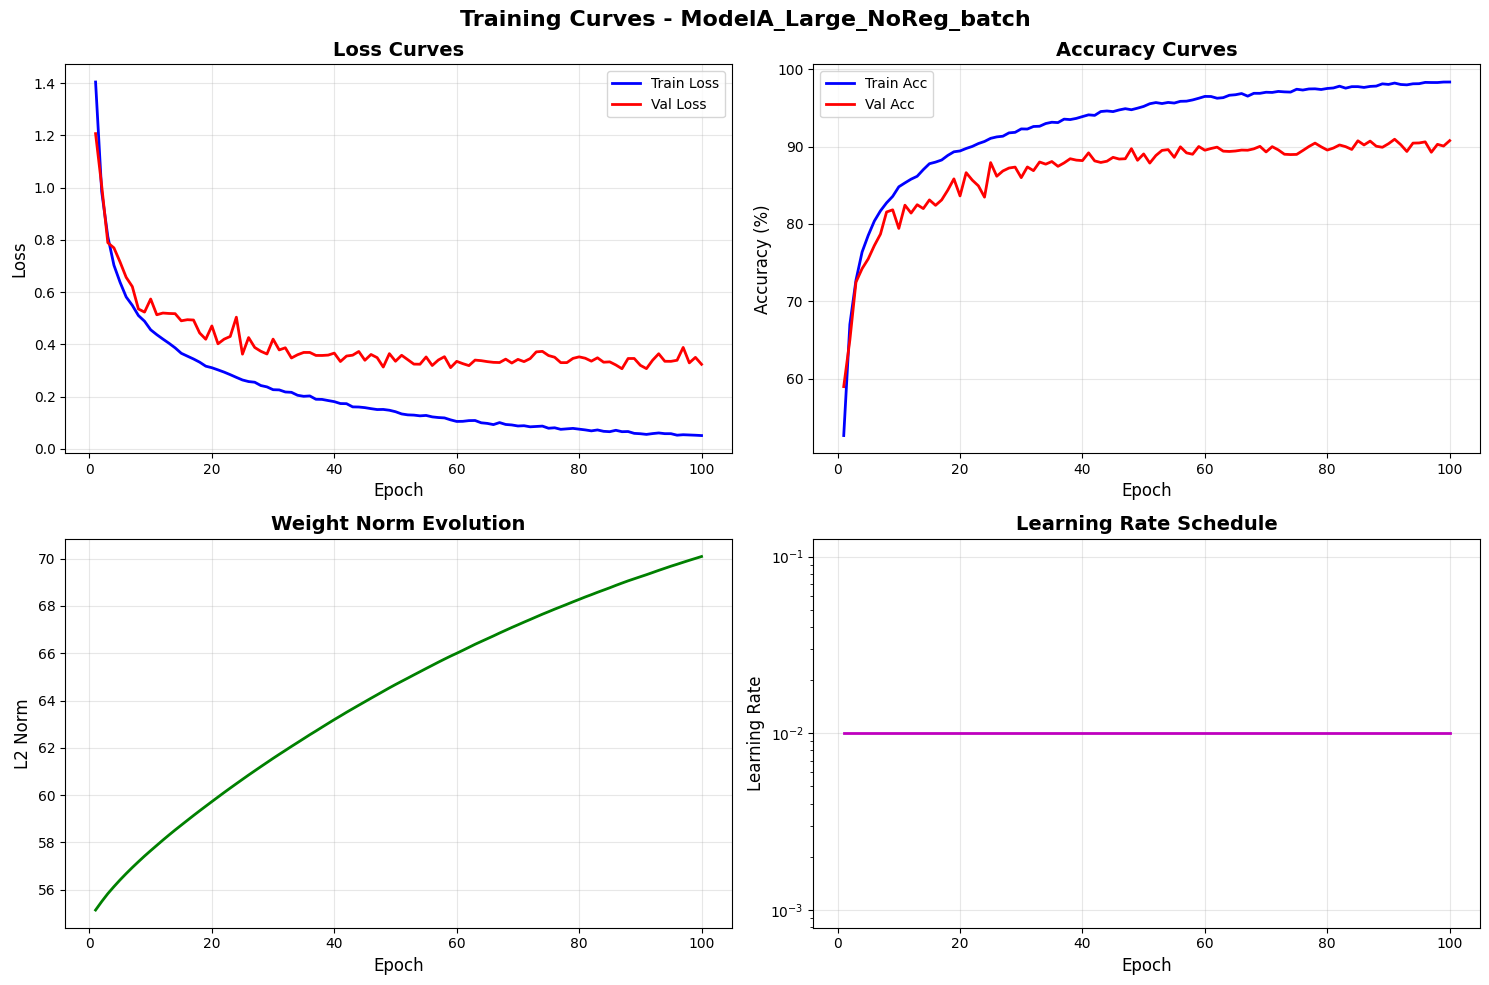

Bias-variance plot saved to: results/figures/ModelA_Large_NoReg_batch_bias_variance.png


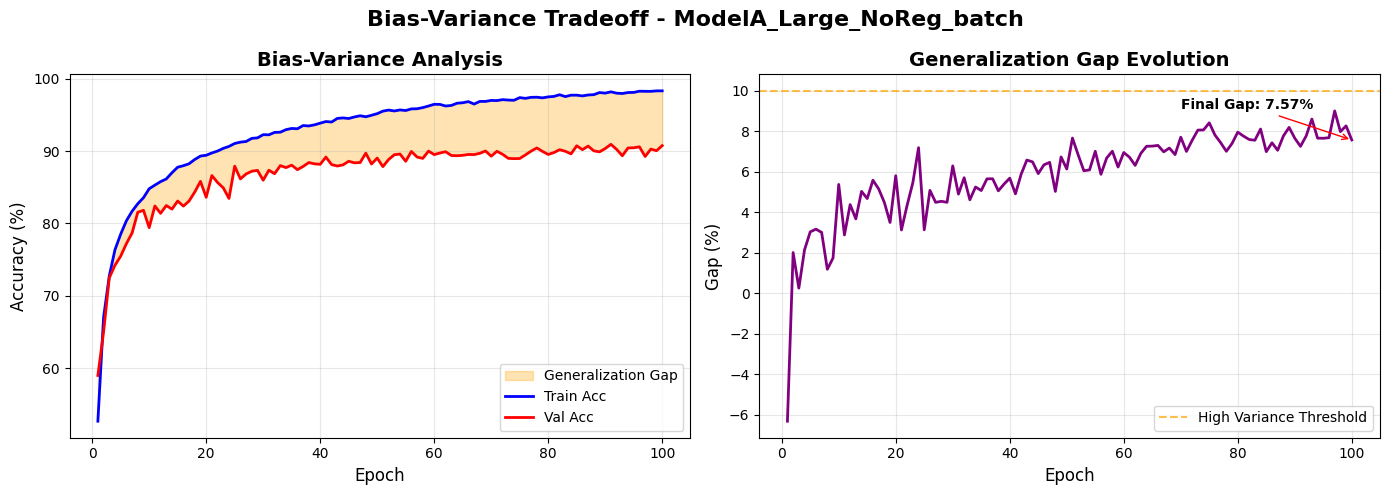

Confusion matrix saved to: results/figures/ModelA_Large_NoReg_batch_confusion.png


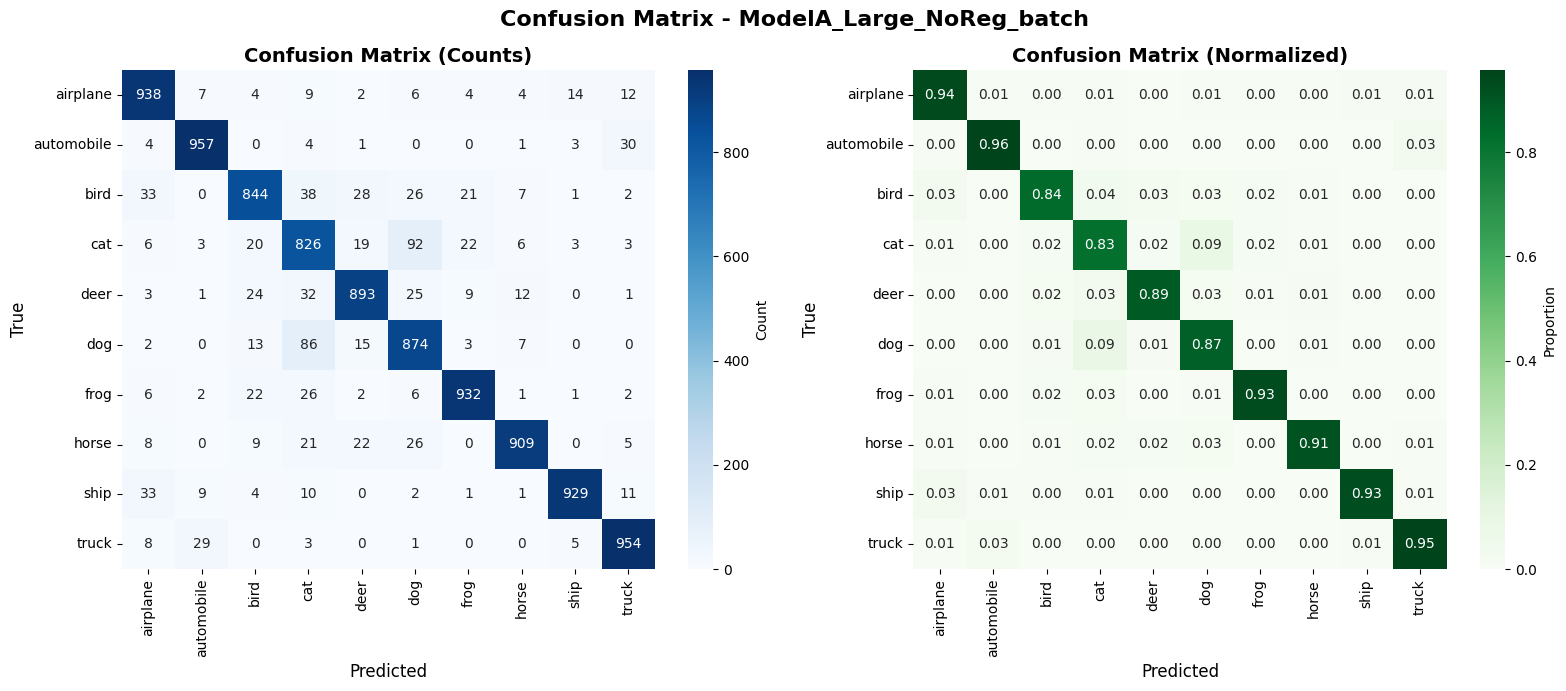


✓ Logged experiment: ModelA_batch_NoReg


In [16]:
# Model A - Large - No Regularization - BatchNorm
results_A_no_reg_bn = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='NoReg',
    norm_type='batch',
    weight_decay=0.0,
    dropout_rate=0.0,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelA_Large_NoReg_layer
Model: ModelA (Large)
Normalization: layer
Condition: NoReg
Weight Decay: 0.0
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.9993 Acc:  26.38% | Val Loss: 1.7933 Acc:  36.62% | Time: 16.78s
Epoch   2/100 | Train Loss: 1.6458 Acc:  40.90% | Val Loss: 1.4442 Acc:  48.56% | Time: 16.73s
Epoch   3/100 | Train Loss: 1.3971 Acc:  50.45% | Val Loss: 1.3106 Acc:  53.66% | Time: 16.74s
Epoch   4/100 | Train Loss: 1.1977 Acc:  57.92% | Val Loss: 1.0915 Acc:  62.88% | Time: 16.73s
Epoch   5/100 | Train Loss: 1.0703 Acc:  62.82% | Val Loss: 1.0377 Acc:  63.22% | Time: 16.73s
Epoch   6/100 | Train Loss: 1.0019 Acc:  65.03% | Val Loss: 0.9420 Acc:  67.06% | Time: 16.73s
Epoch   7/100 | Train Loss: 0.9306 Acc:  67.66% | Val Loss: 0.9883 Acc:  65.42% | Time: 16.73s
Epoch   8/100 | Train Loss: 0.8746 Acc:  69.53% | Val Loss: 0.8732 Acc:  69.62% | Time: 16.72s
Epoch   9/100 | Train Loss: 0.8147 Acc:  71.99% | Val Loss: 0.7934 Acc:  72.16% | Time: 16.75s
Epoch  10/100 | Train Loss: 0.7585 Acc:  73.90% | Val Loss: 0.7319 Acc:  74.

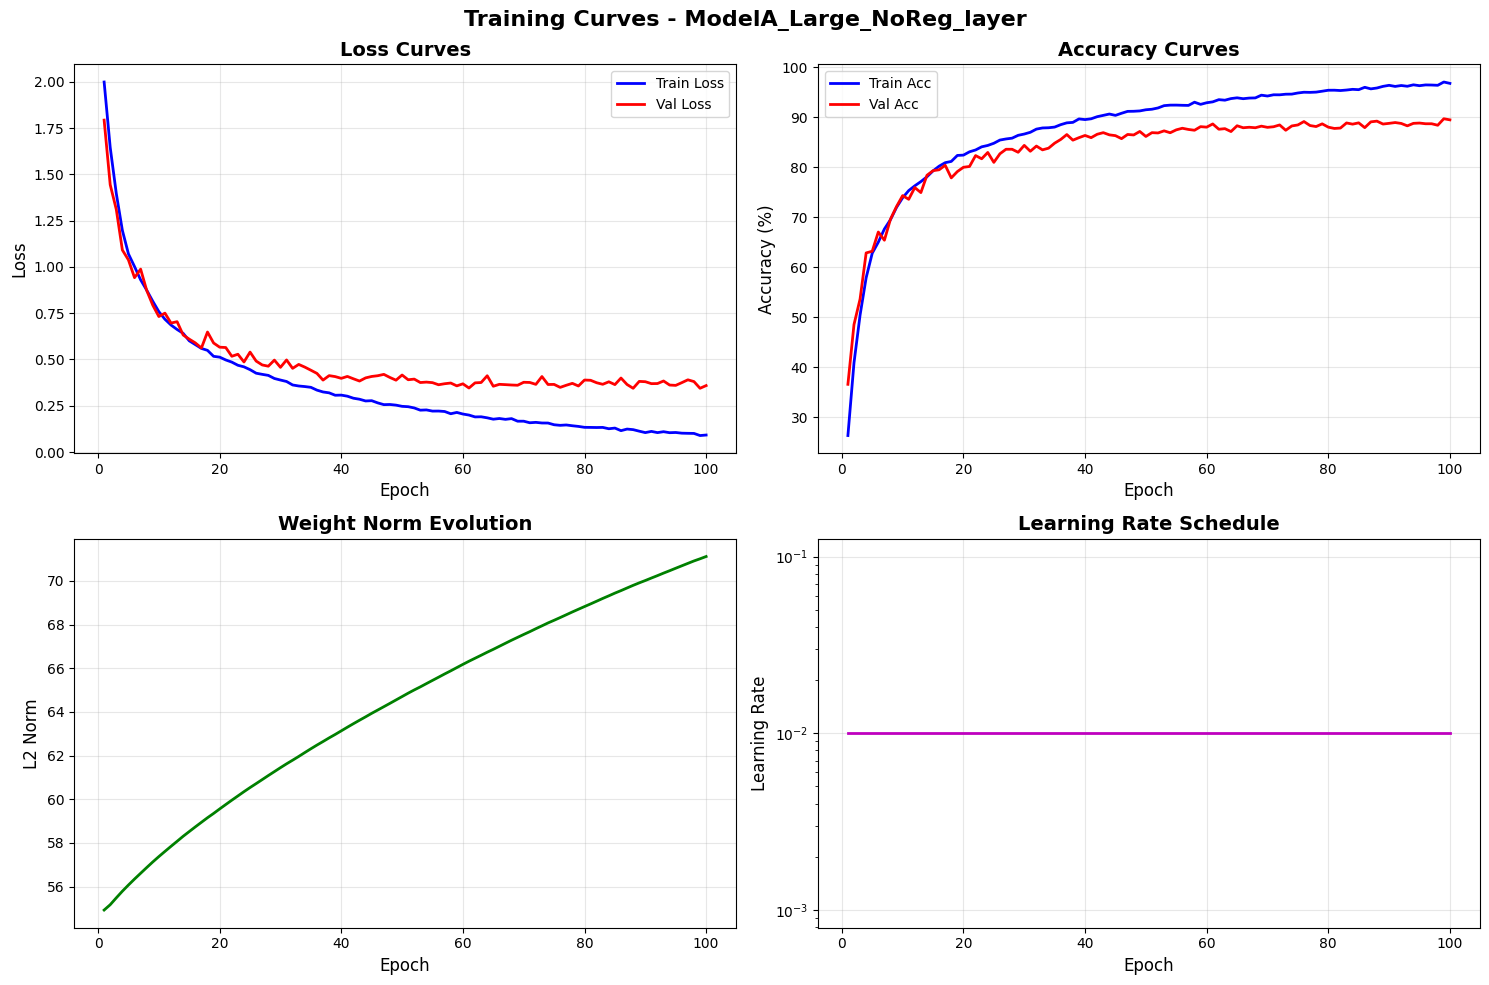

Bias-variance plot saved to: results/figures/ModelA_Large_NoReg_layer_bias_variance.png


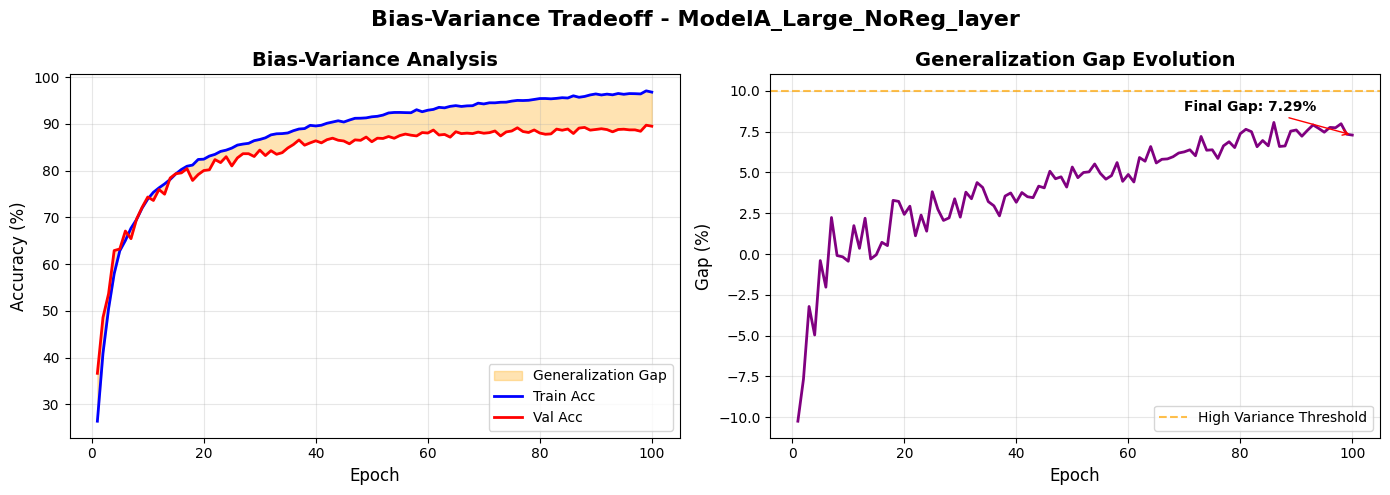

Confusion matrix saved to: results/figures/ModelA_Large_NoReg_layer_confusion.png


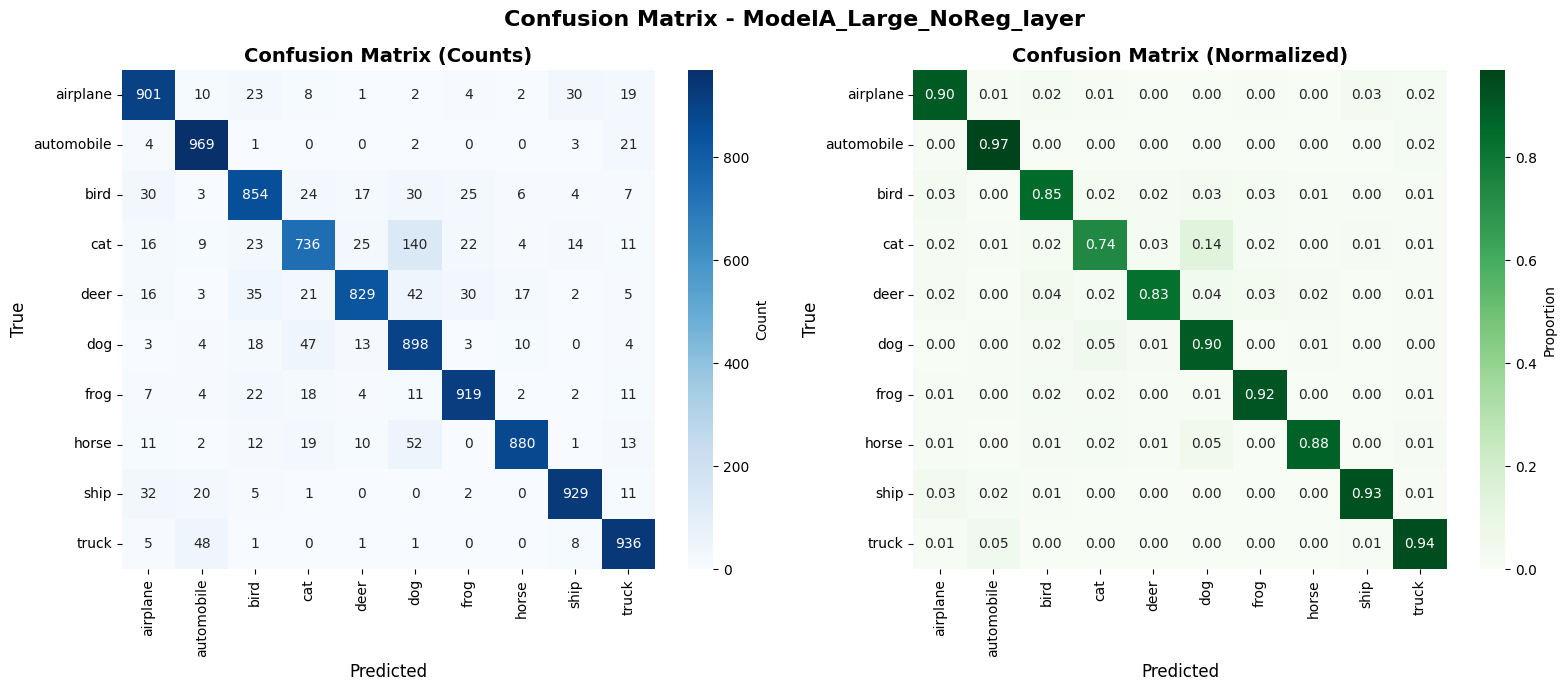


✓ Logged experiment: ModelA_layer_NoReg


In [17]:
# Model A - Large - No Regularization - LayerNorm
results_A_no_reg_ln = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='NoReg',
    norm_type='layer',
    weight_decay=0.0,
    dropout_rate=0.0,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)

#### Experiment 2: Weight Decay (L2 Regularization)


EXPERIMENT: ModelA_Large_WeightDecay_batch
Model: ModelA (Large)
Normalization: batch
Condition: WeightDecay
Weight Decay: 0.0005
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.4115 Acc:  52.23% | Val Loss: 1.2467 Acc:  56.92% | Time: 16.50s
Epoch   2/100 | Train Loss: 0.9989 Acc:  66.46% | Val Loss: 0.9823 Acc:  66.18% | Time: 16.40s
Epoch   3/100 | Train Loss: 0.8275 Acc:  72.14% | Val Loss: 0.8167 Acc:  72.52% | Time: 16.38s
Epoch   4/100 | Train Loss: 0.7273 Acc:  75.76% | Val Loss: 0.8045 Acc:  72.16% | Time: 16.36s
Epoch   5/100 | Train Loss: 0.6566 Acc:  78.12% | Val Loss: 0.7377 Acc:  75.06% | Time: 16.34s
Epoch   6/100 | Train Loss: 0.6027 Acc:  79.73% | Val Loss: 0.6273 Acc:  78.60% | Time: 16.34s
Epoch   7/100 | Train Loss: 0.5680 Acc:  81.01% | Val Loss: 0.6310 Acc:  78.46% | Time: 16.32s
Epoch   8/100 | Train Loss: 0.5377 Acc:  82.16% | Val Loss: 0.5881 Acc:  80.28% | Time: 16.32s
Epoch   9/100 | Train Loss: 0.5062 Acc:  82.94% | Val Loss: 0.5790 Acc:  79.70% | Time: 16.31s
Epoch  10/100 | Train Loss: 0.4863 Acc:  83.80% | Val Loss: 0.6218 Acc:  78.

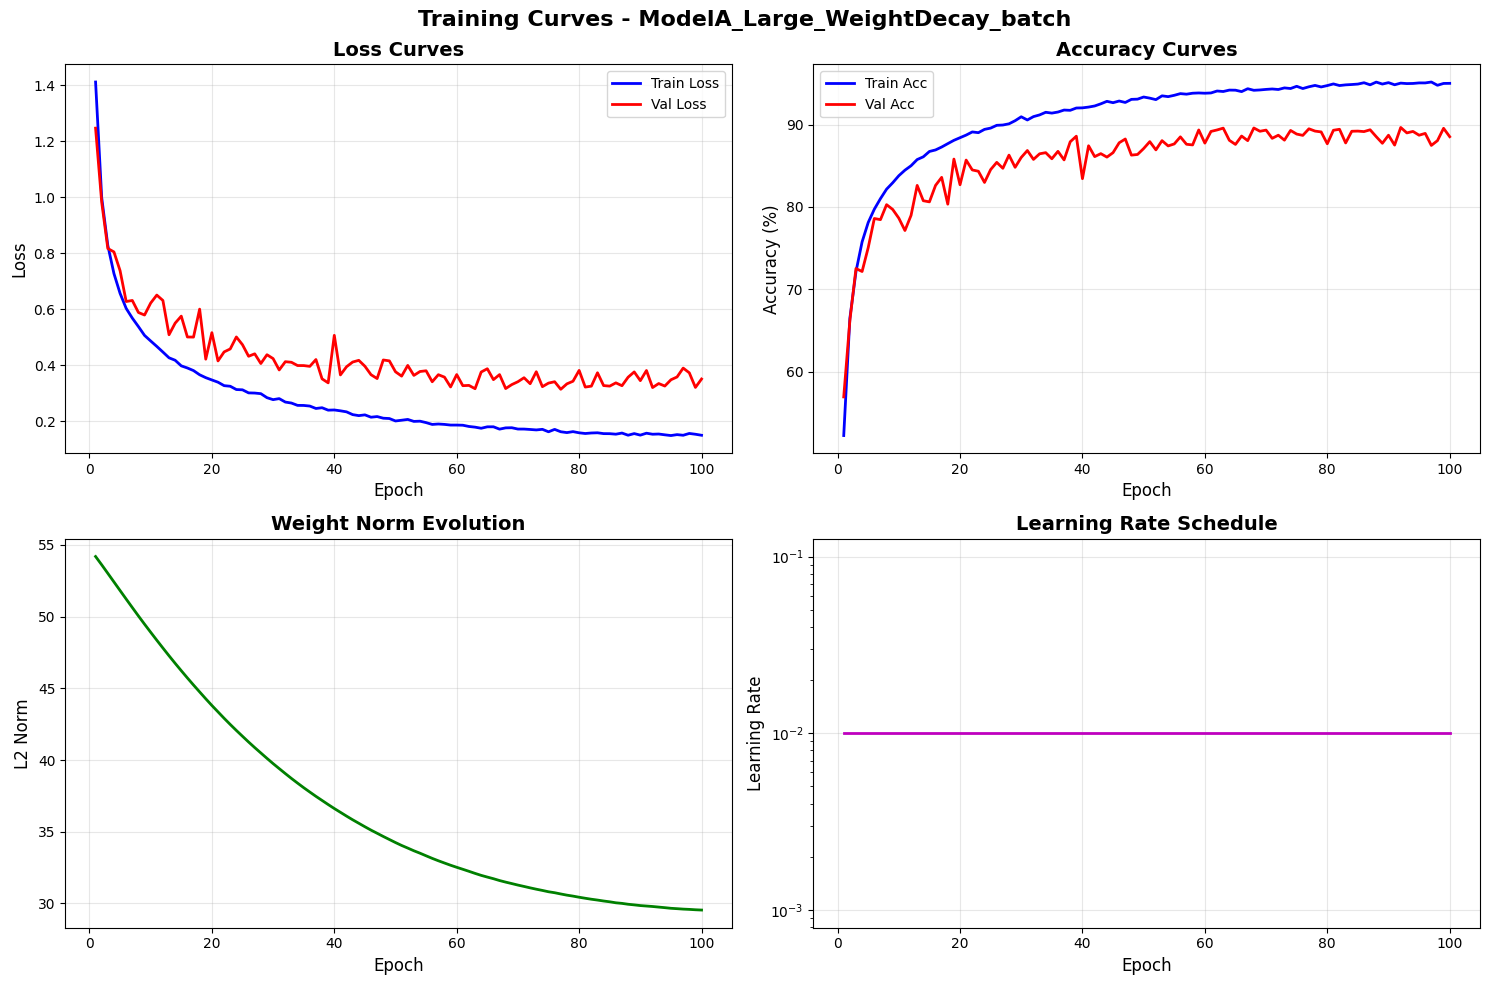

Bias-variance plot saved to: results/figures/ModelA_Large_WeightDecay_batch_bias_variance.png


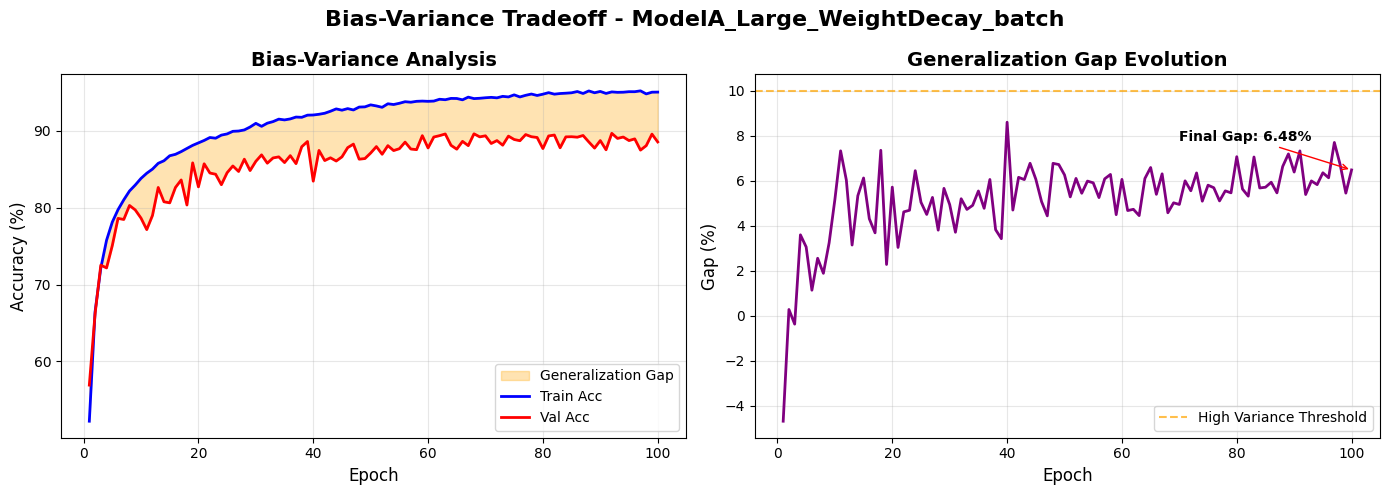

Confusion matrix saved to: results/figures/ModelA_Large_WeightDecay_batch_confusion.png


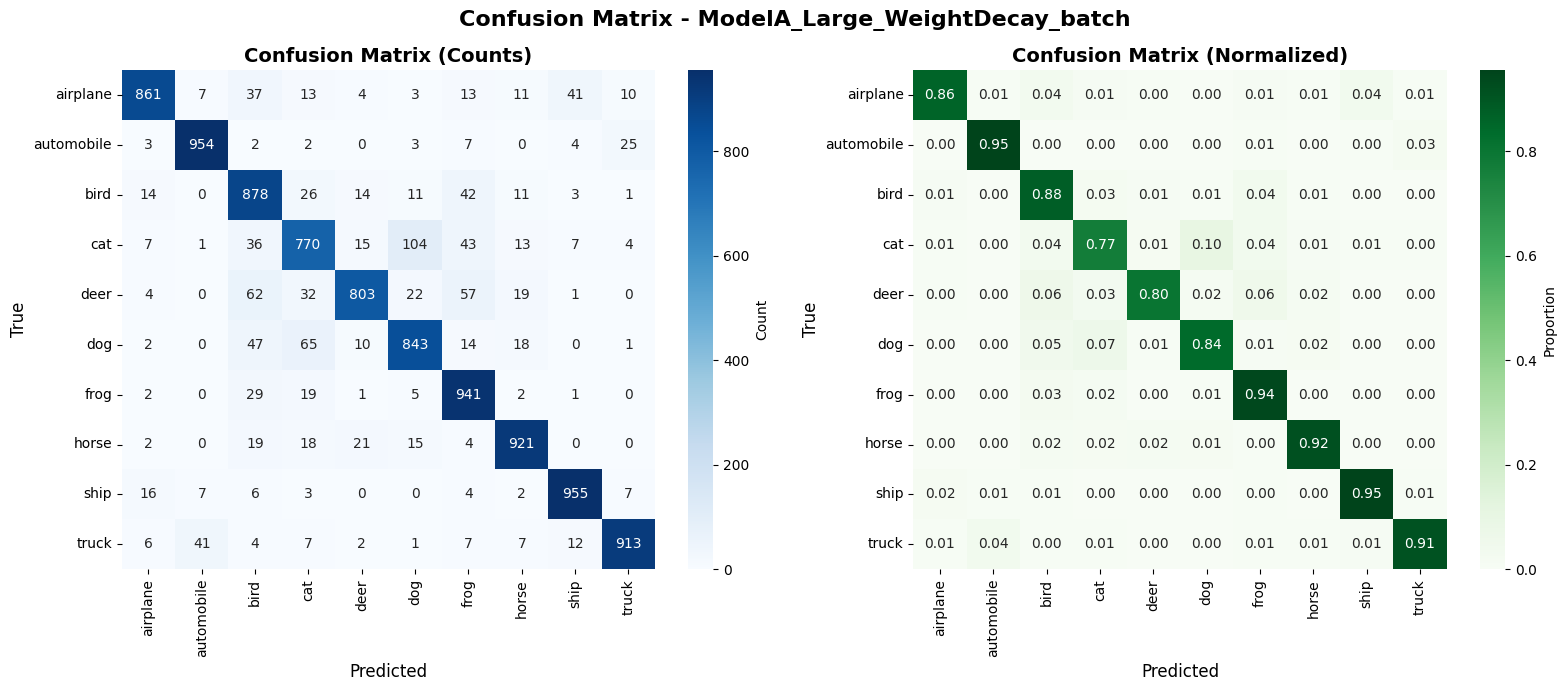


✓ Logged experiment: ModelA_batch_WeightDecay


In [18]:
# Model A - Large - Weight Decay - BatchNorm
results_A_wd_bn = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='WeightDecay',
    norm_type='batch',
    weight_decay=5e-4,  # L2 regularization coefficient
    dropout_rate=0.0,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelA_Large_WeightDecay_layer
Model: ModelA (Large)
Normalization: layer
Condition: WeightDecay
Weight Decay: 0.0005
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.9880 Acc:  27.10% | Val Loss: 1.8483 Acc:  30.24% | Time: 16.88s
Epoch   2/100 | Train Loss: 1.6214 Acc:  41.90% | Val Loss: 1.4530 Acc:  48.34% | Time: 16.80s
Epoch   3/100 | Train Loss: 1.3424 Acc:  52.79% | Val Loss: 1.3019 Acc:  54.28% | Time: 16.80s
Epoch   4/100 | Train Loss: 1.1688 Acc:  59.16% | Val Loss: 1.1510 Acc:  59.58% | Time: 16.80s
Epoch   5/100 | Train Loss: 1.0712 Acc:  62.58% | Val Loss: 1.0208 Acc:  64.48% | Time: 16.79s
Epoch   6/100 | Train Loss: 0.9837 Acc:  65.72% | Val Loss: 1.0418 Acc:  63.16% | Time: 16.79s
Epoch   7/100 | Train Loss: 0.9242 Acc:  68.28% | Val Loss: 0.8869 Acc:  68.76% | Time: 16.79s
Epoch   8/100 | Train Loss: 0.8508 Acc:  70.59% | Val Loss: 0.9342 Acc:  67.76% | Time: 16.80s
Epoch   9/100 | Train Loss: 0.8064 Acc:  72.39% | Val Loss: 0.7788 Acc:  73.42% | Time: 16.79s
Epoch  10/100 | Train Loss: 0.7692 Acc:  73.74% | Val Loss: 0.8696 Acc:  69.

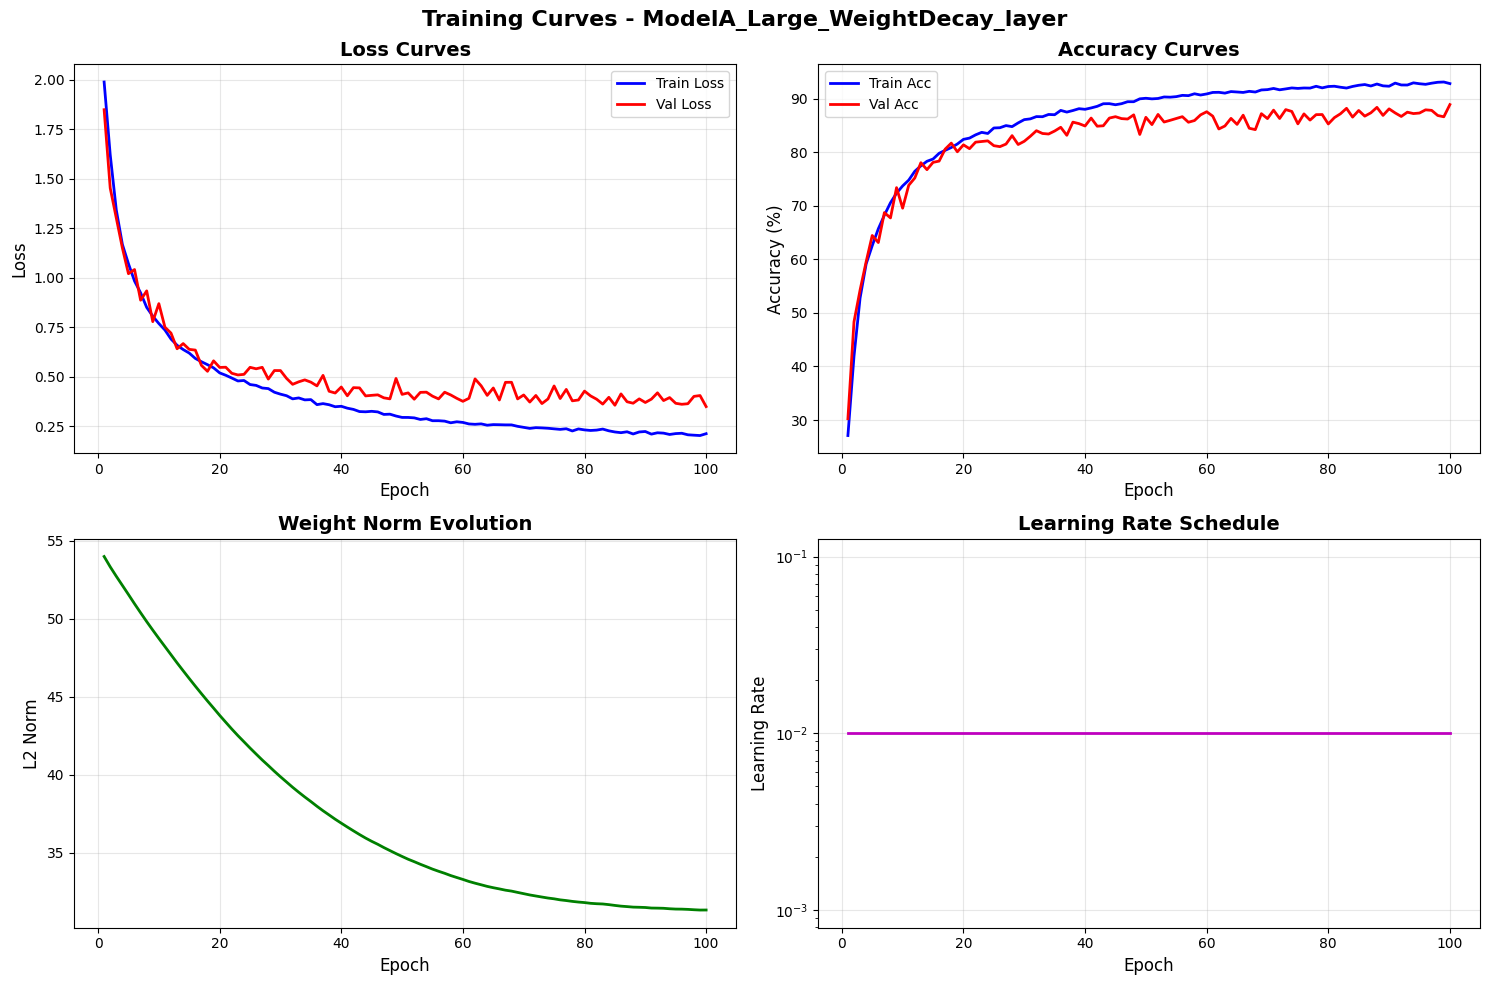

Bias-variance plot saved to: results/figures/ModelA_Large_WeightDecay_layer_bias_variance.png


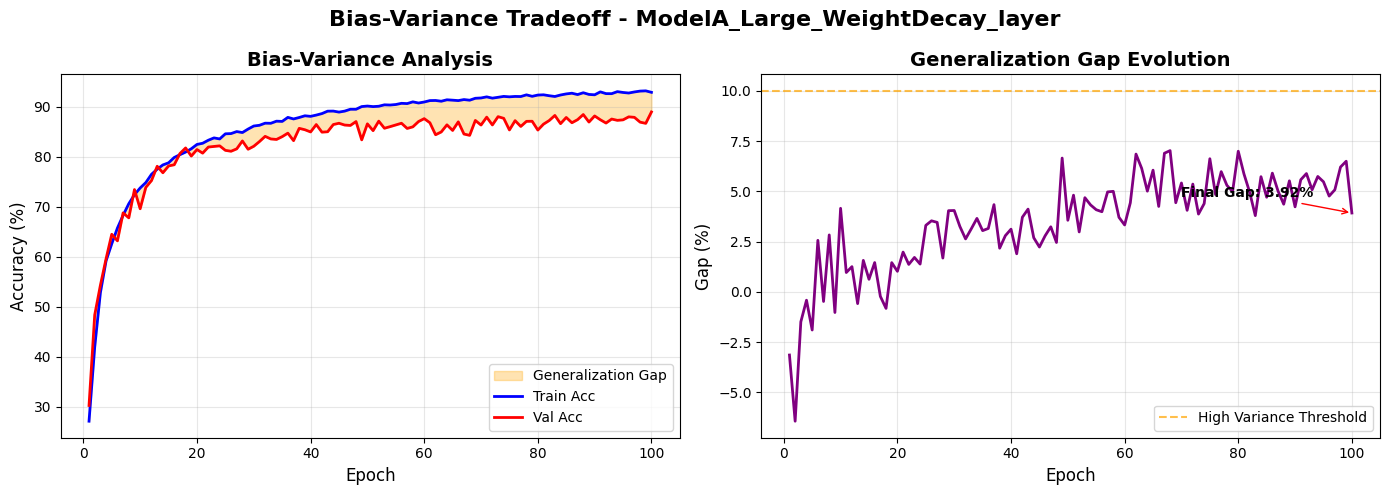

Confusion matrix saved to: results/figures/ModelA_Large_WeightDecay_layer_confusion.png


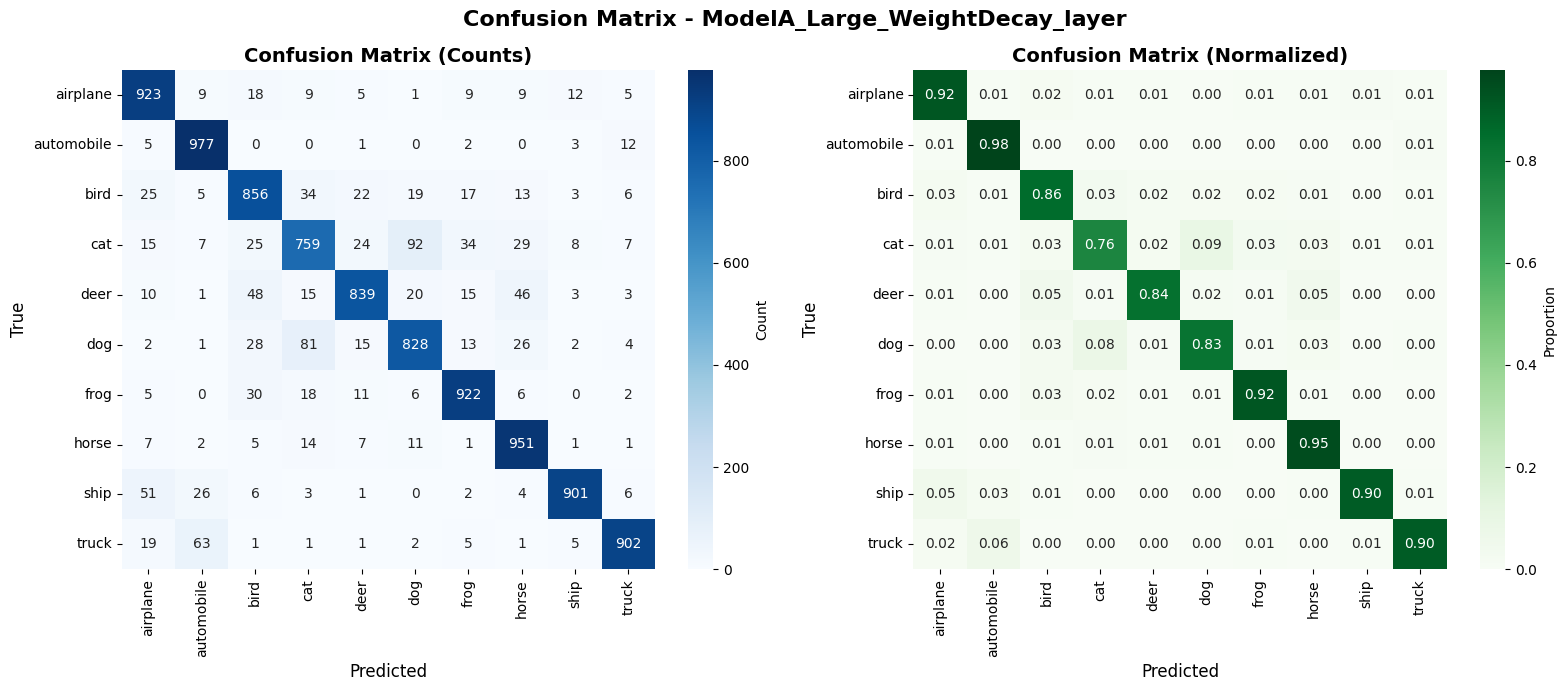


✓ Logged experiment: ModelA_layer_WeightDecay


In [19]:
# Model A - Large - Weight Decay - LayerNorm
results_A_wd_ln = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='WeightDecay',
    norm_type='layer',
    weight_decay=5e-4,
    dropout_rate=0.0,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)

#### Experiment 3: Dropout


EXPERIMENT: ModelA_Large_Dropout_batch
Model: ModelA (Large)
Normalization: batch
Condition: Dropout
Weight Decay: 0.0
Dropout: 0.5
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.9028 Acc:  30.10% | Val Loss: 1.6439 Acc:  40.22% | Time: 16.54s
Epoch   2/100 | Train Loss: 1.6455 Acc:  40.26% | Val Loss: 1.4626 Acc:  47.70% | Time: 16.55s
Epoch   3/100 | Train Loss: 1.5179 Acc:  45.18% | Val Loss: 1.3268 Acc:  52.96% | Time: 16.72s
Epoch   4/100 | Train Loss: 1.4110 Acc:  49.58% | Val Loss: 1.2409 Acc:  55.58% | Time: 16.81s
Epoch   5/100 | Train Loss: 1.3312 Acc:  52.59% | Val Loss: 1.2455 Acc:  54.96% | Time: 16.84s
Epoch   6/100 | Train Loss: 1.2587 Acc:  55.08% | Val Loss: 1.1109 Acc:  61.14% | Time: 16.61s
Epoch   7/100 | Train Loss: 1.2047 Acc:  57.13% | Val Loss: 1.0670 Acc:  62.44% | Time: 16.51s
Epoch   8/100 | Train Loss: 1.1578 Acc:  59.13% | Val Loss: 1.0157 Acc:  64.44% | Time: 16.57s
Epoch   9/100 | Train Loss: 1.1132 Acc:  60.86% | Val Loss: 0.9704 Acc:  64.64% | Time: 16.57s
Epoch  10/100 | Train Loss: 1.0801 Acc:  61.88% | Val Loss: 0.9360 Acc:  66.

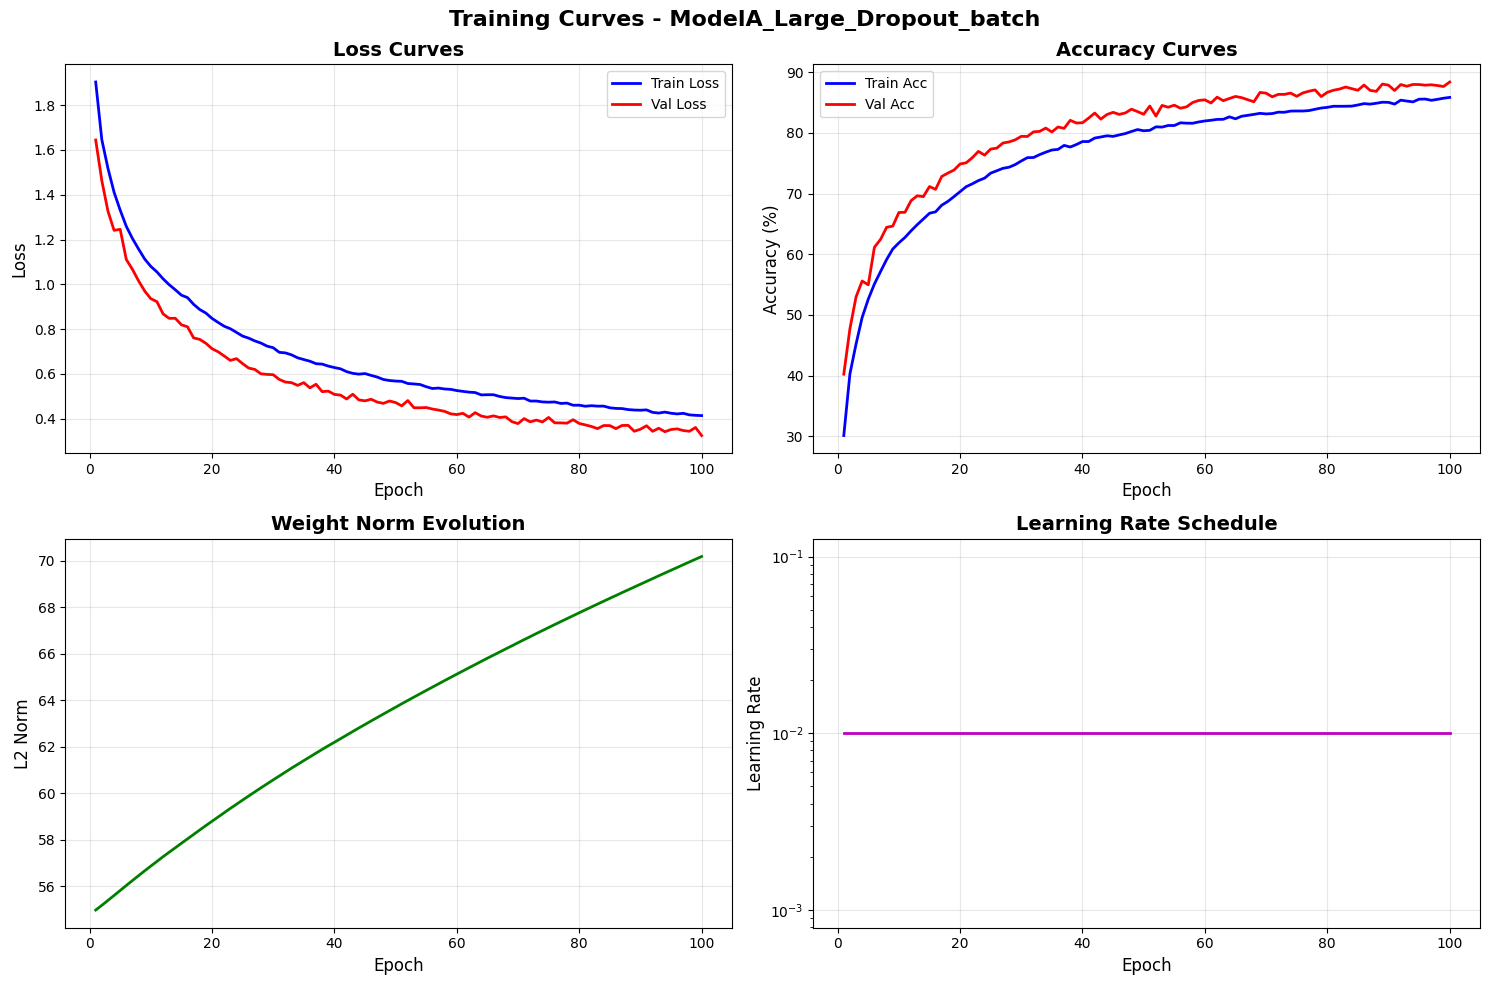

Bias-variance plot saved to: results/figures/ModelA_Large_Dropout_batch_bias_variance.png


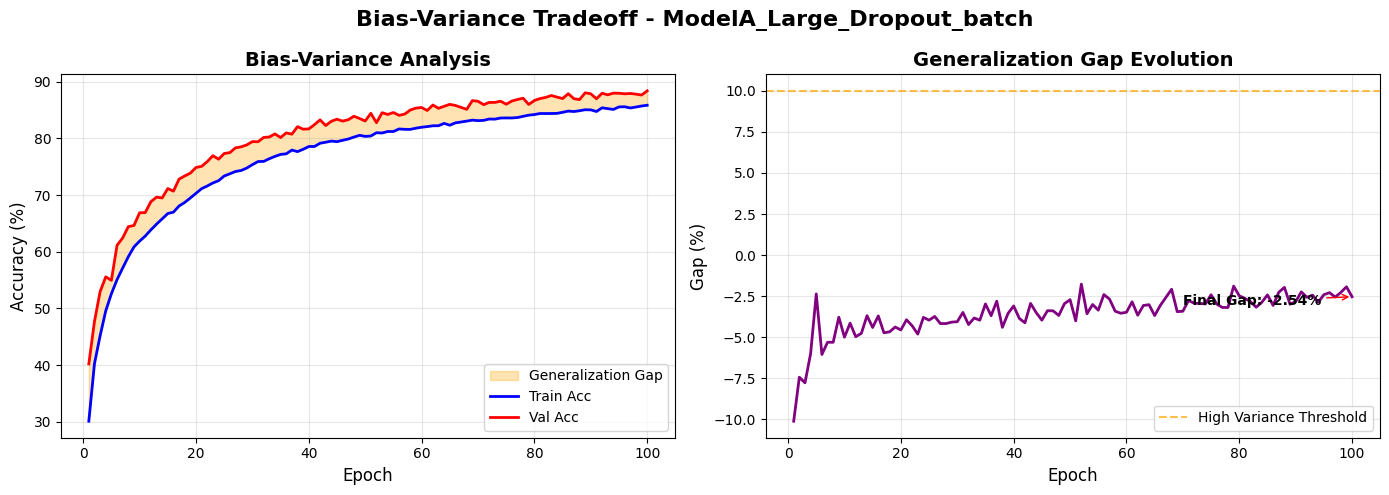

Confusion matrix saved to: results/figures/ModelA_Large_Dropout_batch_confusion.png


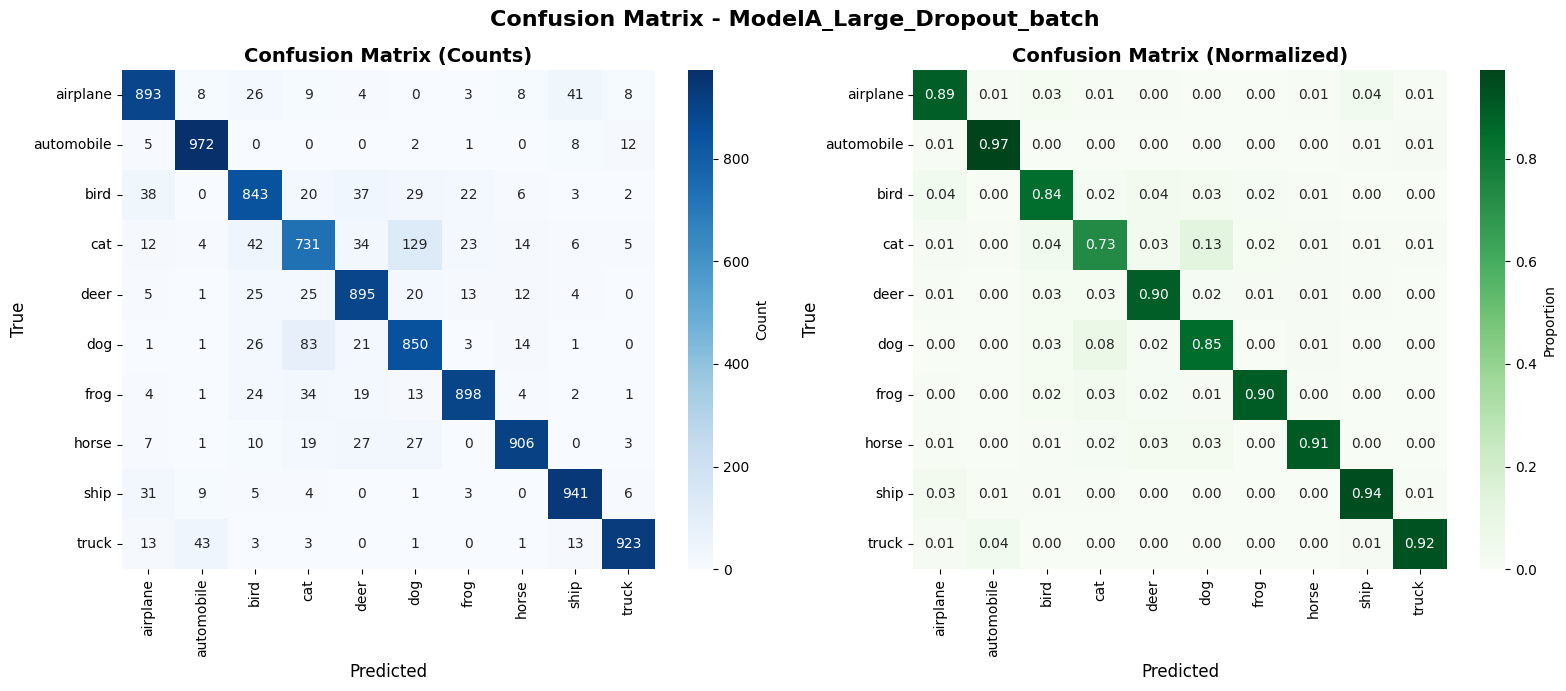


✓ Logged experiment: ModelA_batch_Dropout


In [20]:
# Model A - Large - Dropout - BatchNorm
results_A_dropout_bn = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='Dropout',
    norm_type='batch',
    weight_decay=0.0,
    dropout_rate=0.5,  # 50% dropout
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelA_Large_Dropout_layer
Model: ModelA (Large)
Normalization: layer
Condition: Dropout
Weight Decay: 0.0
Dropout: 0.5
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 2.2704 Acc:  13.66% | Val Loss: 2.1056 Acc:  20.54% | Time: 17.04s
Epoch   2/100 | Train Loss: 2.0197 Acc:  24.90% | Val Loss: 1.8764 Acc:  32.52% | Time: 16.92s
Epoch   3/100 | Train Loss: 1.8536 Acc:  32.06% | Val Loss: 1.7098 Acc:  37.24% | Time: 16.91s
Epoch   4/100 | Train Loss: 1.7199 Acc:  36.92% | Val Loss: 1.6075 Acc:  40.86% | Time: 16.92s
Epoch   5/100 | Train Loss: 1.6186 Acc:  40.98% | Val Loss: 1.5186 Acc:  44.80% | Time: 16.92s
Epoch   6/100 | Train Loss: 1.5543 Acc:  43.51% | Val Loss: 1.4339 Acc:  48.42% | Time: 16.92s
Epoch   7/100 | Train Loss: 1.4928 Acc:  45.71% | Val Loss: 1.4066 Acc:  49.22% | Time: 16.92s
Epoch   8/100 | Train Loss: 1.4308 Acc:  48.16% | Val Loss: 1.2925 Acc:  53.22% | Time: 17.12s
Epoch   9/100 | Train Loss: 1.3793 Acc:  50.32% | Val Loss: 1.2905 Acc:  53.28% | Time: 17.02s
Epoch  10/100 | Train Loss: 1.3212 Acc:  52.39% | Val Loss: 1.2566 Acc:  55.

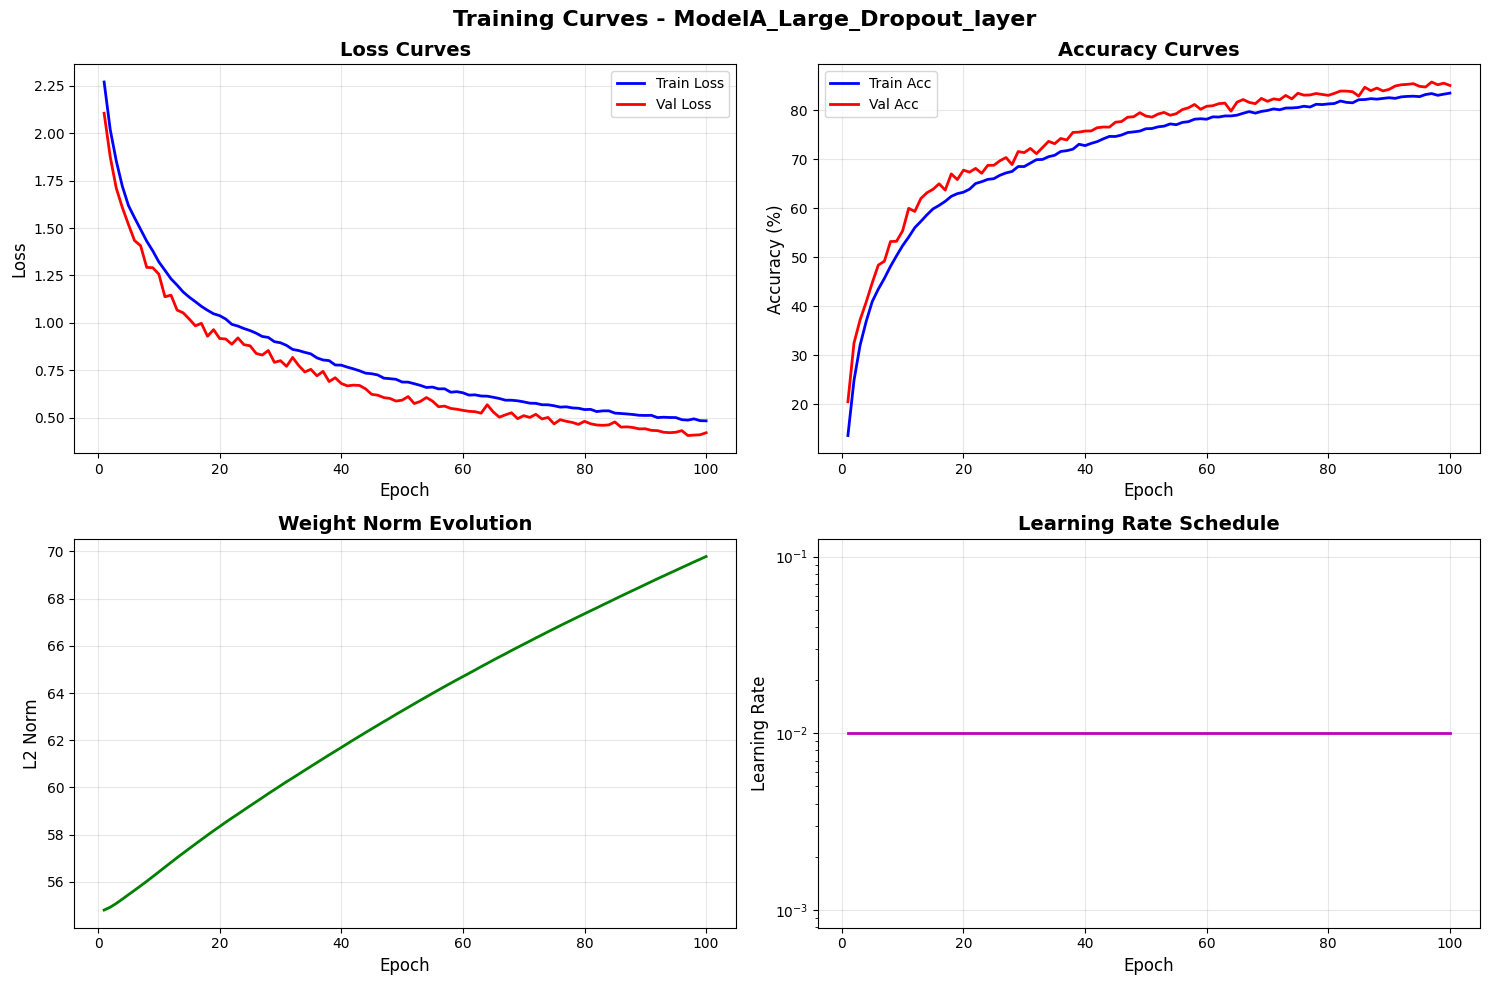

Bias-variance plot saved to: results/figures/ModelA_Large_Dropout_layer_bias_variance.png


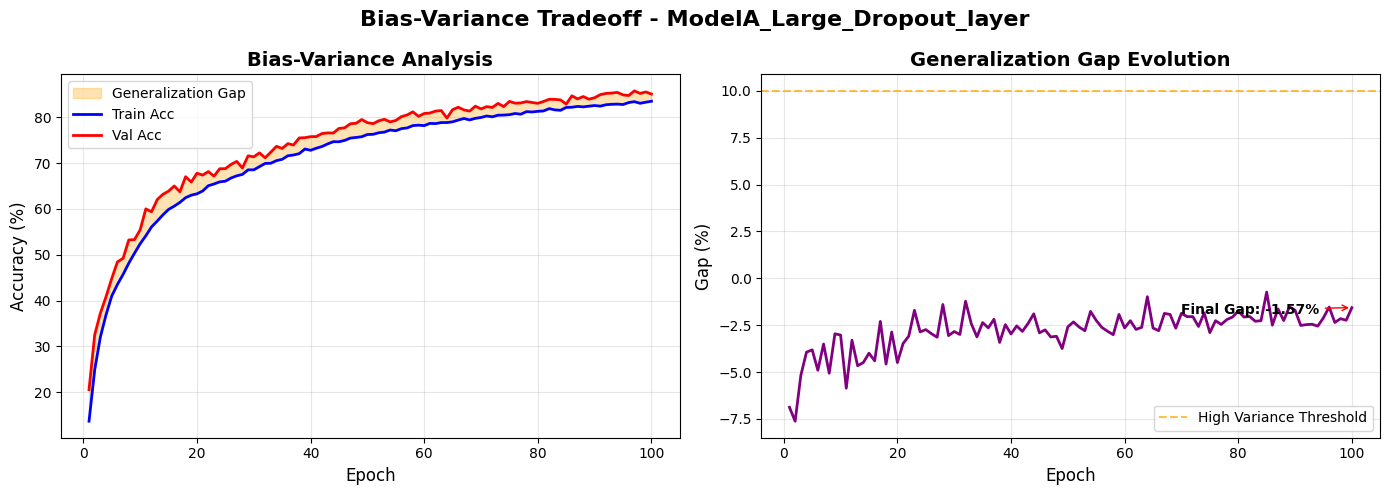

Confusion matrix saved to: results/figures/ModelA_Large_Dropout_layer_confusion.png


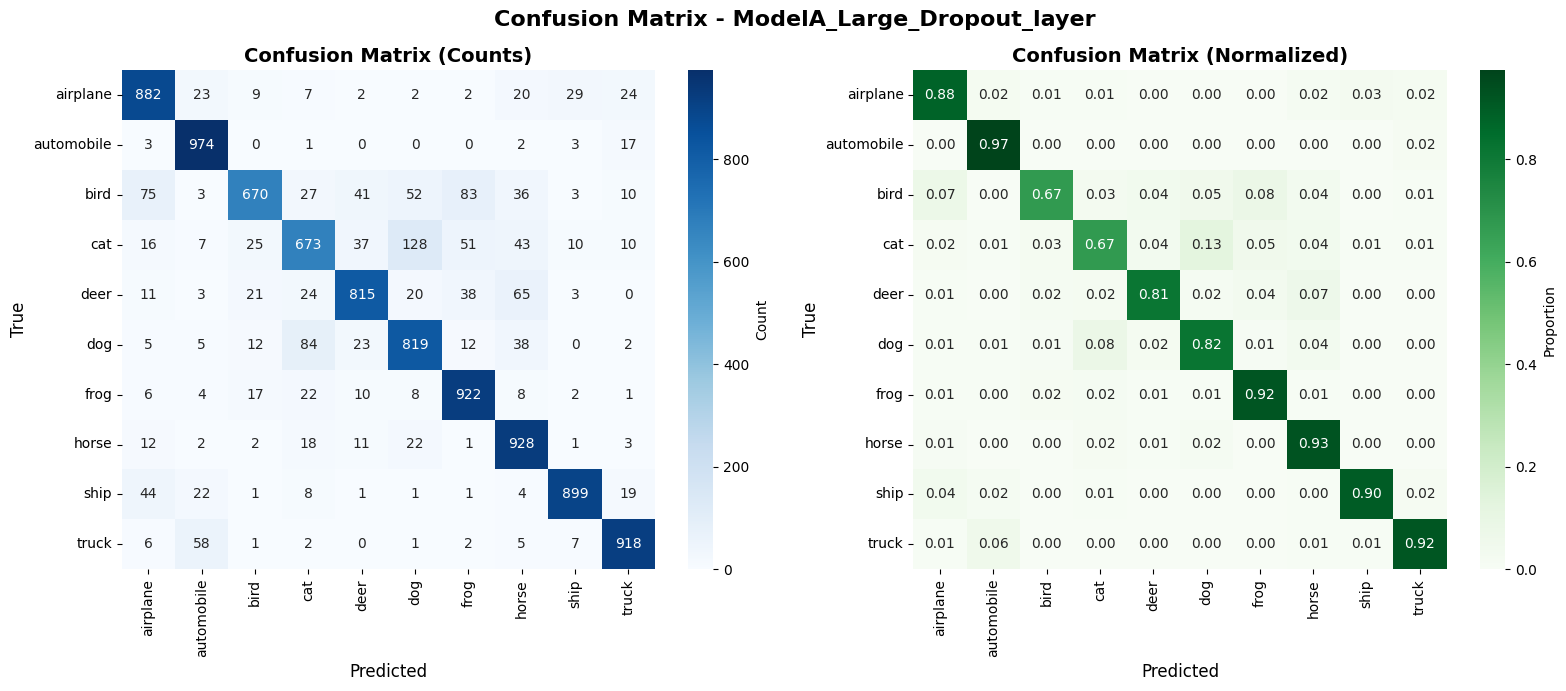


✓ Logged experiment: ModelA_layer_Dropout


In [21]:
# Model A - Large - Dropout - LayerNorm
results_A_dropout_ln = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='Dropout',
    norm_type='layer',
    weight_decay=0.0,
    dropout_rate=0.5,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)

#### Experiment 4: Combined Regularization + Early Stopping


EXPERIMENT: ModelA_Large_Combined_batch
Model: ModelA (Large)
Normalization: batch
Condition: Combined
Weight Decay: 0.0005
Dropout: 0.5
Early Stopping: True
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/150 | Train Loss: 1.9075 Acc:  29.87% | Val Loss: 1.6709 Acc:  39.38% | Time: 16.60s
Epoch   2/150 | Train Loss: 1.6690 Acc:  39.38% | Val Loss: 1.4718 Acc:  47.48% | Time: 16.61s
Epoch   3/150 | Train Loss: 1.5349 Acc:  44.91% | Val Loss: 1.3710 Acc:  51.68% | Time: 16.61s
Epoch   4/150 | Train Loss: 1.4251 Acc:  48.91% | Val Loss: 1.2644 Acc:  55.00% | Time: 16.61s
Epoch   5/150 | Train Loss: 1.3424 Acc:  52.14% | Val Loss: 1.2304 Acc:  56.60% | Time: 16.60s
Epoch   6/150 | Train Loss: 1.2733 Acc:  54.91% | Val Loss: 1.1167 Acc:  59.98% | Time: 16.59s
Epoch   7/150 | Train Loss: 1.2133 Acc:  57.15% | Val Loss: 1.0344 Acc:  63.32% | Time: 16.56s
Epoch   8/150 | Train Loss: 1.1658 Acc:  58.80% | Val Loss: 1.0358 Acc:  63.56% | Time: 16.54s
Epoch   9/150 | Train Loss: 1.1269 Acc:  60.23% | Val Loss: 0.9843 Acc:  65.24% | Time: 16.51s
Epoch  10/150 | Train Loss: 1.0944 Acc:  61.48% | Val Loss: 0.9556 Acc:  66.

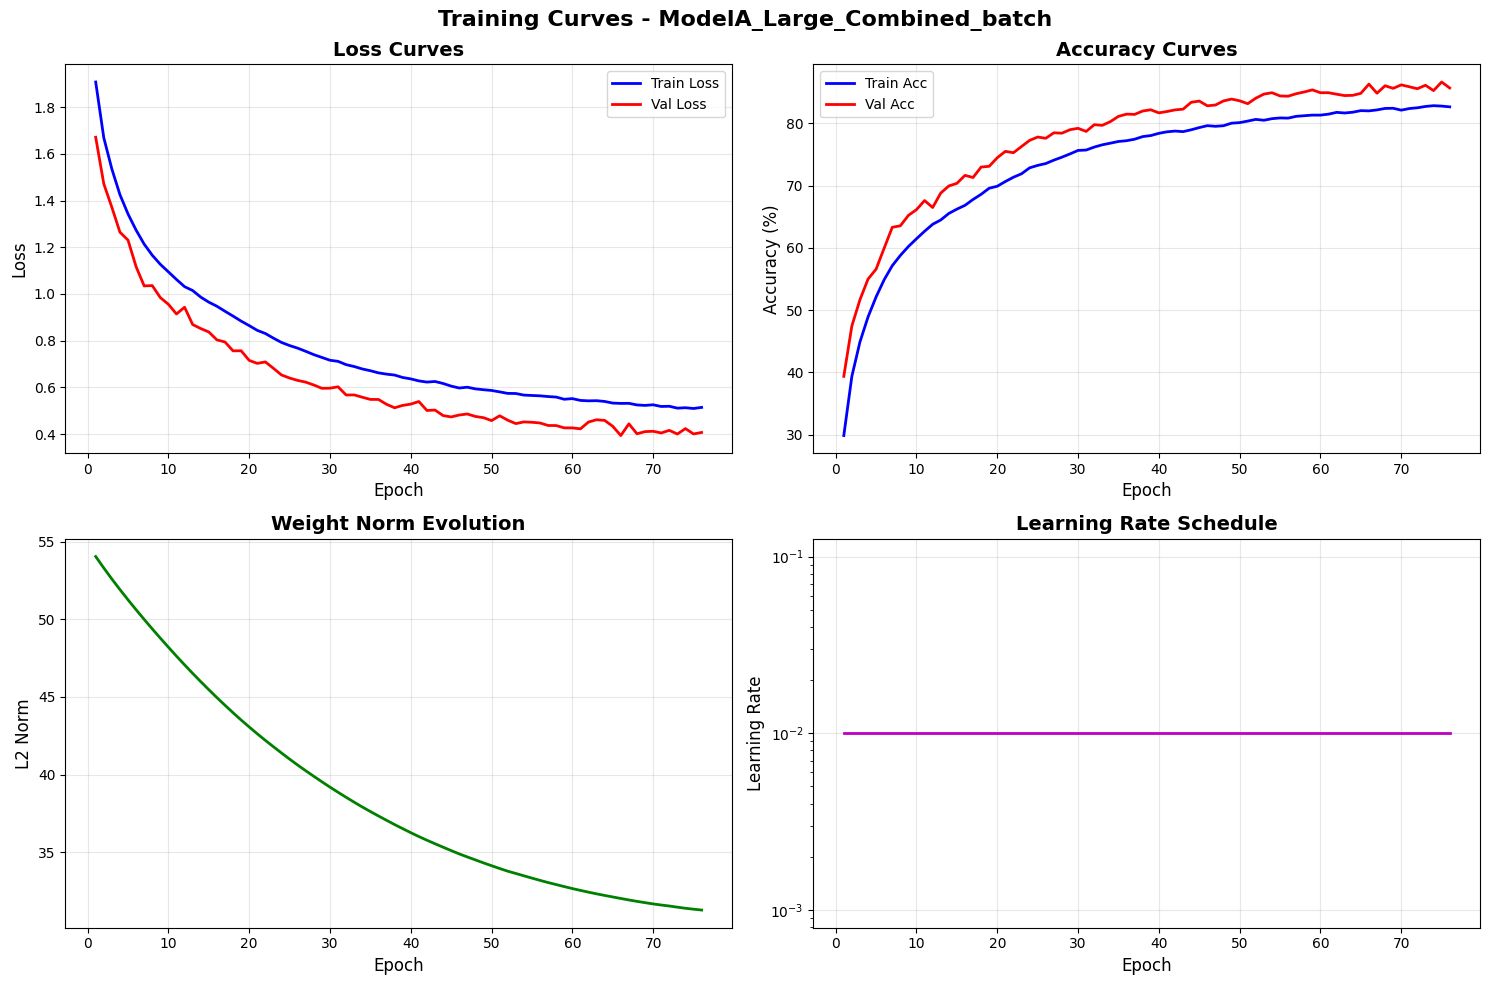

Bias-variance plot saved to: results/figures/ModelA_Large_Combined_batch_bias_variance.png


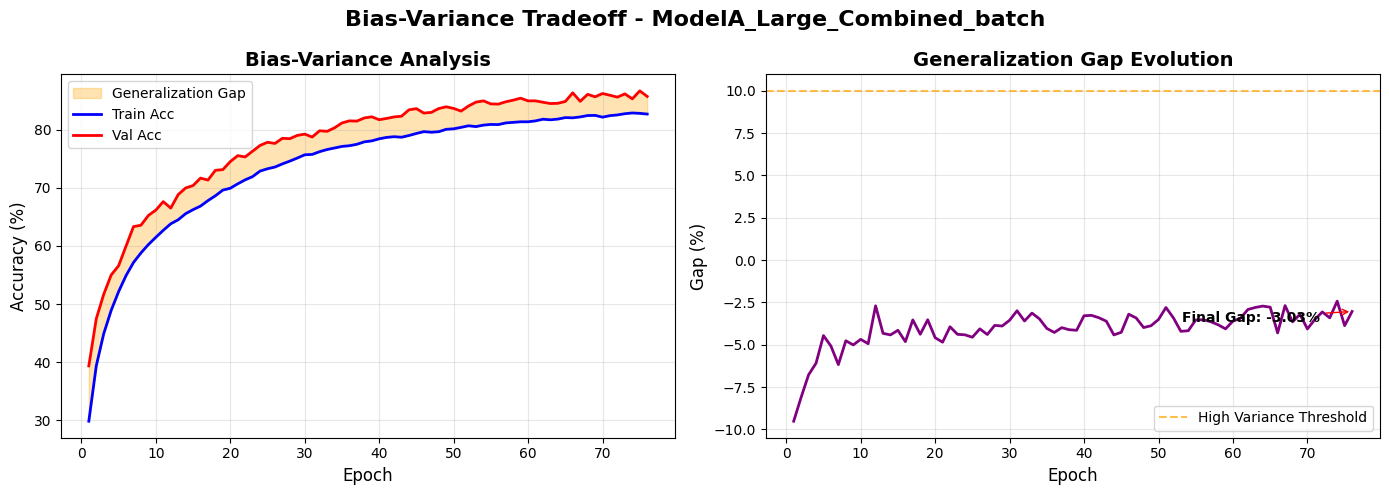

Confusion matrix saved to: results/figures/ModelA_Large_Combined_batch_confusion.png


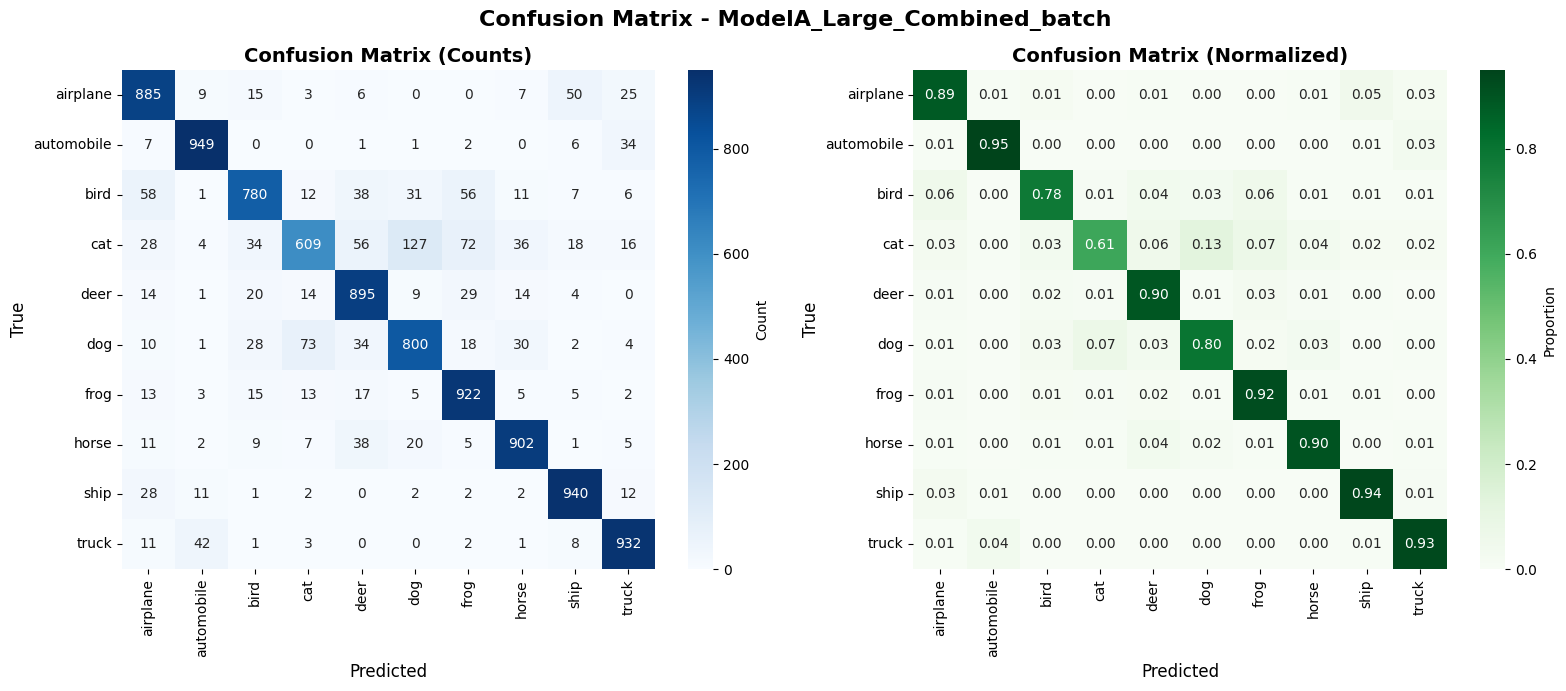


✓ Logged experiment: ModelA_batch_Combined


In [23]:
# Model A - Large - Combined - BatchNorm
results_A_combined_bn = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='Combined',
    norm_type='batch',
    weight_decay=5e-4,
    dropout_rate=0.5,
    use_early_stopping=True,  # Early stopping enabled
    num_epochs=150,  # Larger budget, will stop early if converged
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelA_Large_Combined_layer
Model: ModelA (Large)
Normalization: layer
Condition: Combined
Weight Decay: 0.0005
Dropout: 0.5
Early Stopping: True
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 1,364,372 (1.364M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/150 | Train Loss: 2.1321 Acc:  20.02% | Val Loss: 2.0204 Acc:  23.86% | Time: 17.02s
Epoch   2/150 | Train Loss: 1.9363 Acc:  28.60% | Val Loss: 1.8730 Acc:  30.38% | Time: 16.93s
Epoch   3/150 | Train Loss: 1.7877 Acc:  34.69% | Val Loss: 1.7051 Acc:  36.54% | Time: 16.92s
Epoch   4/150 | Train Loss: 1.6791 Acc:  38.62% | Val Loss: 1.5460 Acc:  44.48% | Time: 16.91s
Epoch   5/150 | Train Loss: 1.5968 Acc:  41.71% | Val Loss: 1.4860 Acc:  46.60% | Time: 16.88s
Epoch   6/150 | Train Loss: 1.5347 Acc:  44.28% | Val Loss: 1.3983 Acc:  49.18% | Time: 16.85s
Epoch   7/150 | Train Loss: 1.4768 Acc:  46.44% | Val Loss: 1.3661 Acc:  51.32% | Time: 16.84s
Epoch   8/150 | Train Loss: 1.4054 Acc:  49.35% | Val Loss: 1.2821 Acc:  53.52% | Time: 16.83s
Epoch   9/150 | Train Loss: 1.3450 Acc:  51.71% | Val Loss: 1.1911 Acc:  57.58% | Time: 16.83s
Epoch  10/150 | Train Loss: 1.3017 Acc:  53.41% | Val Loss: 1.1775 Acc:  57.

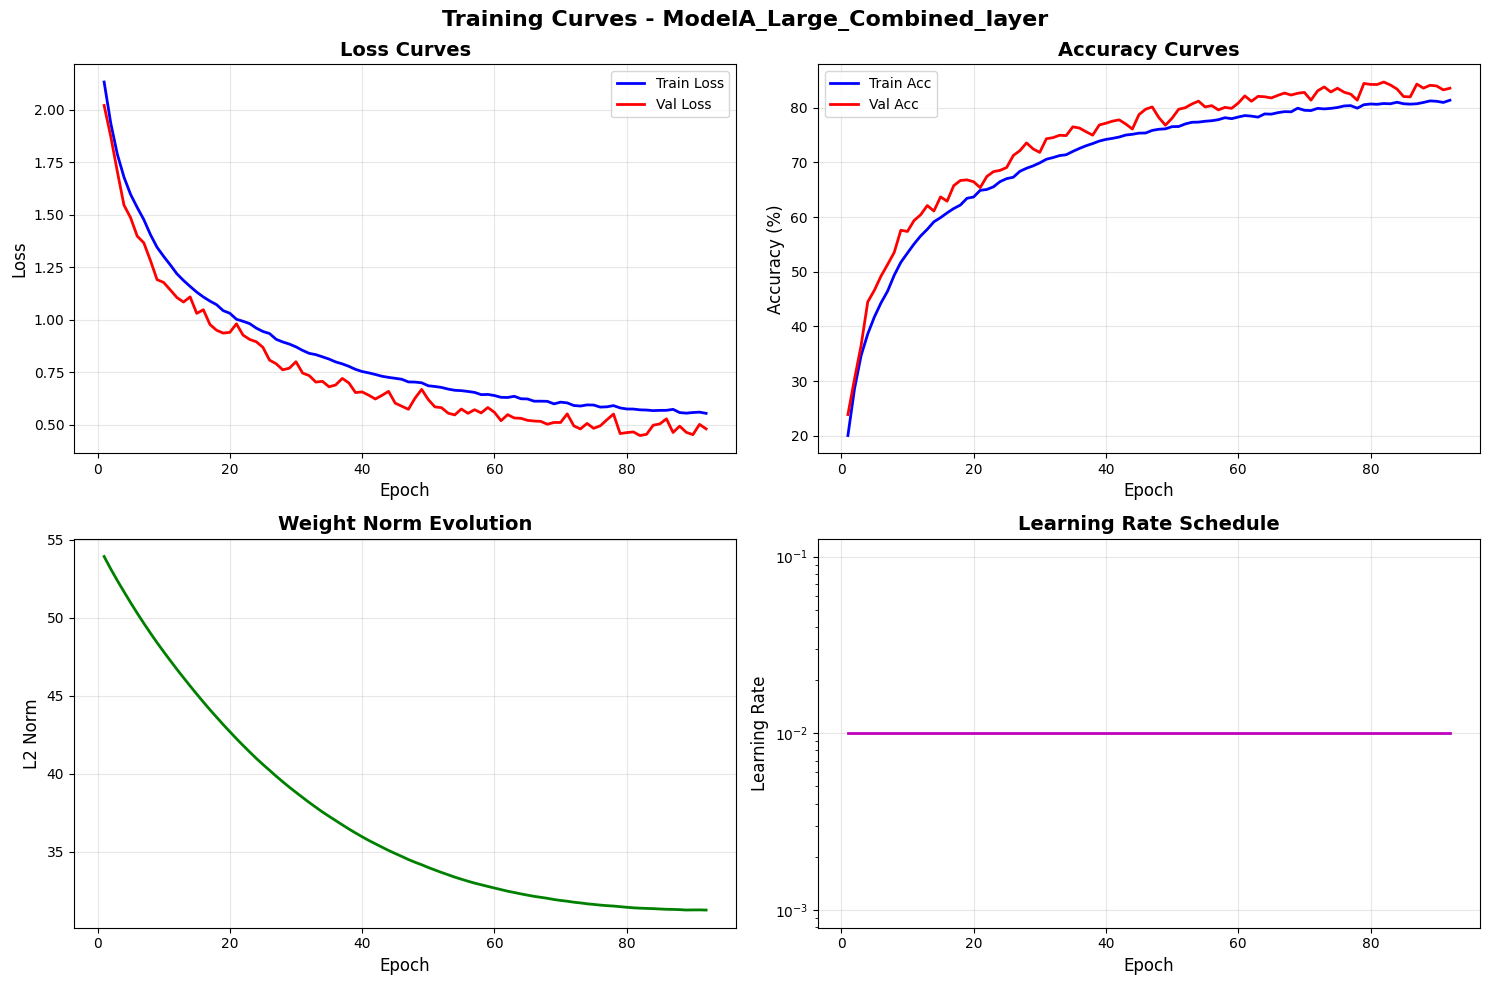

Bias-variance plot saved to: results/figures/ModelA_Large_Combined_layer_bias_variance.png


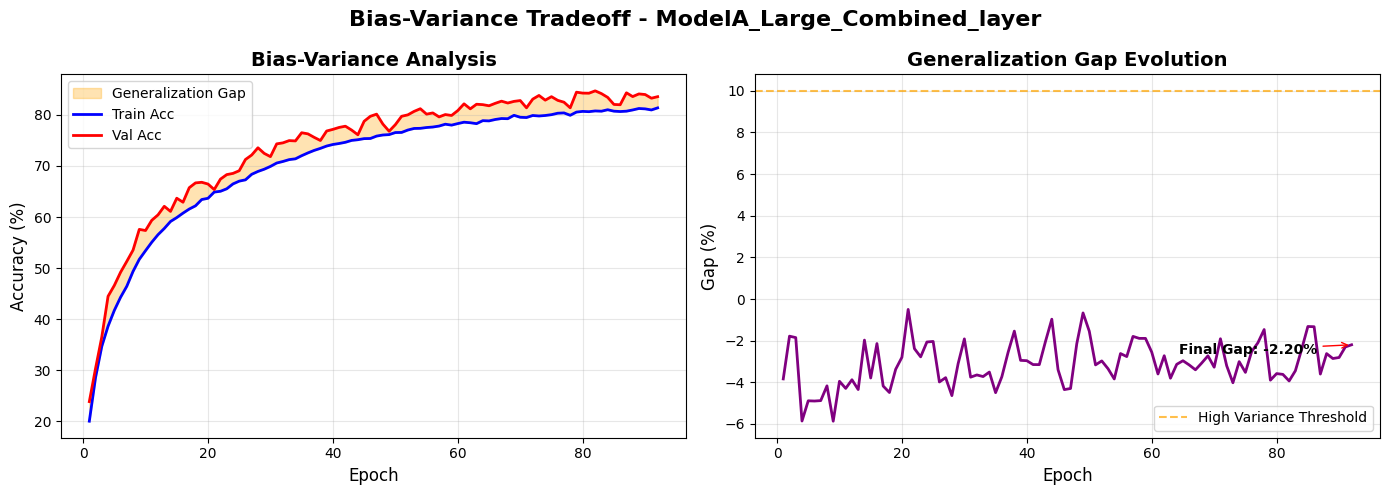

Confusion matrix saved to: results/figures/ModelA_Large_Combined_layer_confusion.png


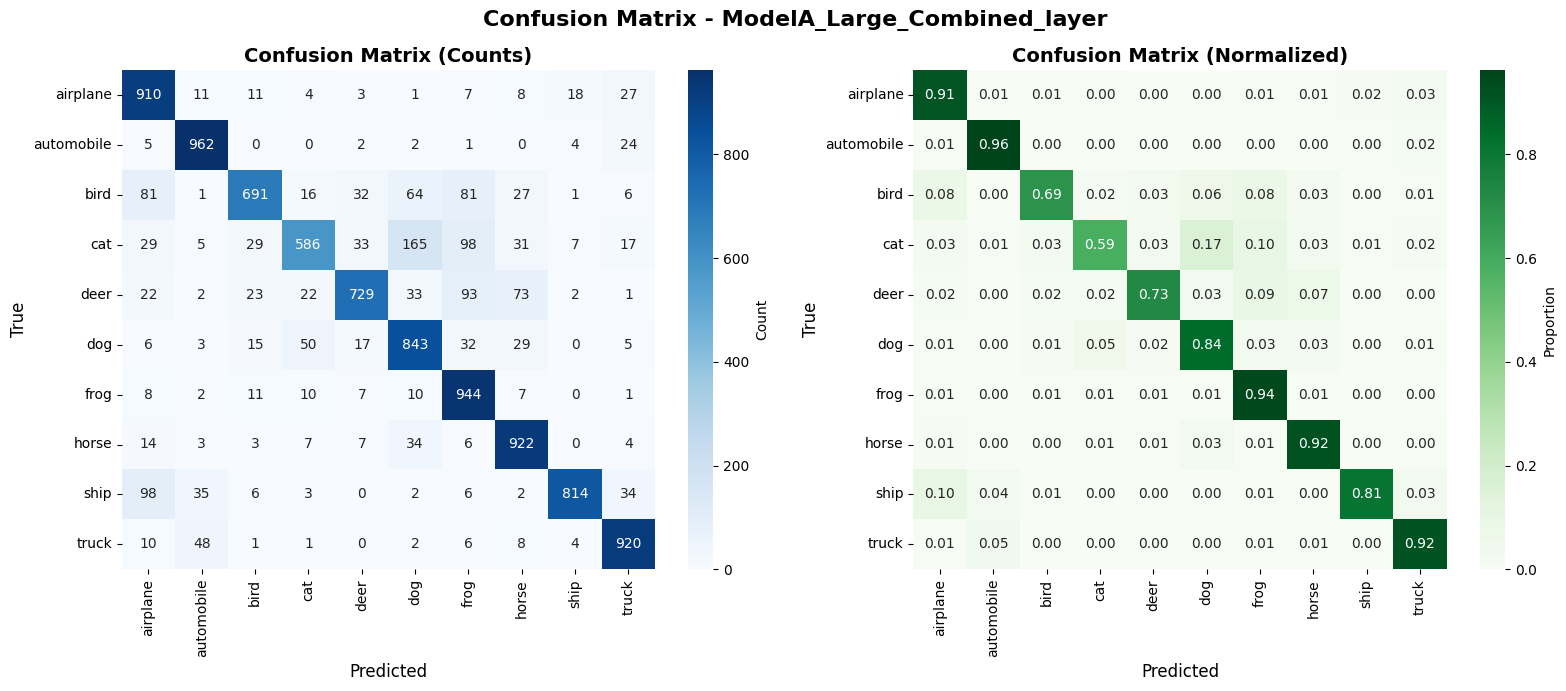


✓ Logged experiment: ModelA_layer_Combined


In [22]:
# Model A - Large - Combined - LayerNorm
results_A_combined_ln = run_experiment(
    model_class=CNN_ModelA_Large,
    model_name='ModelA',
    model_size='Large',
    condition='Combined',
    norm_type='layer',
    weight_decay=5e-4,
    dropout_rate=0.5,
    use_early_stopping=True,
    num_epochs=150,
    learning_rate=0.01,
    batch_size=128
)

## Model A

| Rank | Config                   | Test Acc | Gen Gap | Time(s) | Result        |
|------|---------------------------|----------|---------|---------|------------------|
| 1    | NoReg + BatchNorm         | 90.56%   | +7.57%  | 1639s   | OVERFITTING      |
| 2    | WeightDecay + LayerNorm   | 88.58%   | +3.92%  | 1680s   | BALANCED         |
| 3    | Dropout + BatchNorm       | 88.52%   | -2.54%  | 1664s   | UNDERFITTING     |
| 4    | WeightDecay + BatchNorm   | 88.39%   | +6.48%  | 1642s   | MODERATE OVERFIT |
| 5    | NoReg + LayerNorm         | 88.51%   | +7.29%  | 1676s   | OVERFITTING      |
| 6    | Combined + BatchNorm      | 86.14%   | -3.03%  | 1259s   | UNDERFITTING     |
| 7    | Dropout + LayerNorm       | 85.00%   | -1.57%  | 1692s   | UNDERFITTING     |
| 8    | Combined + LayerNorm      | 83.21%   | -2.20%  | 1559s   | UNDERFITTING     |


## Análisis de Configuraciones - Modelo A (Large)

### "Mejor Configuración": NoReg + BatchNorm (90.56% test acc)
Este modelo alcanza la máxima precisión en test pero con un problema. El gap de +7.57% indica overfitting grande, el modelo memoriza en lugar de aprender patrones generalizables. BatchNorm ayuda a estabilizar el entrenamiento pero no evita el sobreajuste. 

Funciona bien en este experimento porque CIFAR-10 test viene de la misma distribución que train (mismo dataset), pero fallaría con datos nuevos en producción.


Entonces, no es la mejor.

### Peor Configuración: Combined + LayerNorm (83.21% test acc)
Combinar weight decay, dropout y early stopping con LayerNorm destruye por completo la capacidad del modelo. El underfitting es evidente: el modelo no puede aprender ni los patrones básicos. LayerNorm interfiere con dropout, y early stopping corta el entrenamiento demasiado pronto. El resultado es 7.35% menos precisión que la mejor configuración.



### Configuración Balanceada: WeightDecay + LayerNorm (88.58% test acc)
Esta es la opción más sensata para uso real. El gap de solo +3.92% indica que el modelo generaliza bien sin memorizar demasiado. Sacrifica solo 2% de precisión comparado con la configuración número 1, pero es mucho más confiable. Para producción, esta es la mejor elección.


#### Nota: LayerNorm vs BatchNorm con Weight Decay

La combinación WeightDecay + LayerNorm funciona mejor que WeightDecay + BatchNorm porque LayerNorm es más estricta. 

Con BatchNorm, el modelo encuentra un "atajo", aunque weight decay encoge los pesos, BatchNorm puede ajustar sus propios parámetros de escala para compensar y mantener activaciones grandes, lo que permite cierto overfitting. 

LayerNorm no tiene esos parámetros adicionales, así que normaliza cada muestra por separado sin poder "esconder" el efecto de weight decay. El resultado es que LayerNorm fuerza una regularización más honesta: el gap de generalización baja de +6.48% a +3.92% con casi la misma precisión (88.39% vs 88.58%).


---

<a id='part3'></a>

##  Part 3: Analytical Discussion

**1. Is your model underfitting or overfitting? How do you know?**

Depende de la configuración. Los modelos con gap positivo grande como NoReg + BatchNorm (+7.57%) están overfitting: train accuracy es mucho mayor que test accuracy, lo que indica memorización. Los modelos con gap negativo como Dropout + BatchNorm (-2.54%) están underfitting: ni siquiera aprenden bien el training set. La configuración balanceada es WeightDecay + LayerNorm con gap +3.92%.

**2. How does weight decay affect the norm of the weights?**

Weight decay añade un término $$\frac{\lambda}{2}\|W\|^2$$ a la pérdida, lo que hace que los pesos tiendan a cero en cada actualización: $$w \leftarrow w - \eta(\frac{\partial L}{\partial w} + \lambda w) = (1-\eta\lambda)w - \eta\frac{\partial L}{\partial w}$$. Esto reduce la norma de los pesos, favoreciendo soluciones más simples.

**3. How does dropout affect gradient flow?**

Dropout apaga aleatoriamente neuronas con probabilidad $$p$$ durante entrenamiento. Esto hace que el gradiente solo fluya por las neuronas activas en cada forward pass, creando rutas diferentes cada vez. Es como entrenar muchas subredes diferentes cuyo promedio se usa en inferencia.

**4. Does BatchNorm improve optimization stability in your experiments? Why might that be?**


Sí, BatchNorm mejora la estabilidad para este caso, las configuraciones con BatchNorm convergen más rápido y con curvas más suaves que sus equivalentes con LayerNorm.

 BatchNorm normaliza usando estadísticas del mini-batch:
$$\hat{x} = \frac{x - \mu_B}{\sigma_B}$$

Esto reduce el **internal covariate shift** (cambio en la distribución de activaciones entre capas), lo que permite usar learning rates más altos sin divergencia y hace el gradiente más predecible.

Pero, con regularización weight decay, LayerNorm generaliza mejor aunque entrene más lento. Esto pasa porque BatchNorm tiene parámetros escalares (γ, β) que pueden "absorber" parte de la regularización, mientras LayerNorm normaliza por muestra sin parámetros adicionales, forzando un efecto más directo de weight decay sobre los pesos reales.

**5. Philosophically, is your architecture closer in spirit to AlexNet, VGG, or ResNet, or others? Explain.**

Es más cercana a VGG por el uso de bloques convolucionales apilados con filtros pequeños (3x3 y 1x1) y pooling entre bloques, pero también un poco de NiN (Network in Network) por los Conv1x1 que reducen dimensiones antes de clasificar. No tiene conexiones residuales como ResNet.

<a id='part4'></a>
## Part 4: Engineering Constraint - Small Model (<500k params)

Todos los experimentos anteriores para comparar.


 ModelB + LayerNorm + Sin Regularización

EXPERIMENT: ModelB_Small_NoReg_layer
Model: ModelB (Small)
Normalization: layer
Condition: NoReg
Weight Decay: 0.0
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)

Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.9975 Acc:  26.77% | Val Loss: 1.8203 Acc:  37.26% | Time: 7.90s
Epoch   2/100 | Train Loss: 1.6313 Acc:  42.27% | Val Loss: 1.4721 Acc:  49.48% | Time: 7.93s
Epoch   3/100 | Train Loss: 1.4175 Acc:  49.98% | Val Loss: 1.3029 Acc:  52.48% | Time: 7.99s
Epoch   4/100 | Train Loss: 1.2788 Acc:  54.80% | Val Loss: 1.2141 Acc:  56.34% | Time: 7.97s
Epoch   5/100 | Train Loss: 1.1970 Acc:  57.72% | Val Loss: 1.1329 Acc:  60.16% | Time: 8.05s
Epoch   6/100 | Train Loss: 1.1195 Acc:  60.51% | Val Loss: 1.1331 Acc:  59.50% | Time: 7.92s
Epoch   7/100 | Train Loss: 1.0663 Acc:  62.71% | Val Loss: 1.0354 Acc:  62.70% | Time: 7.91s
Epoch  

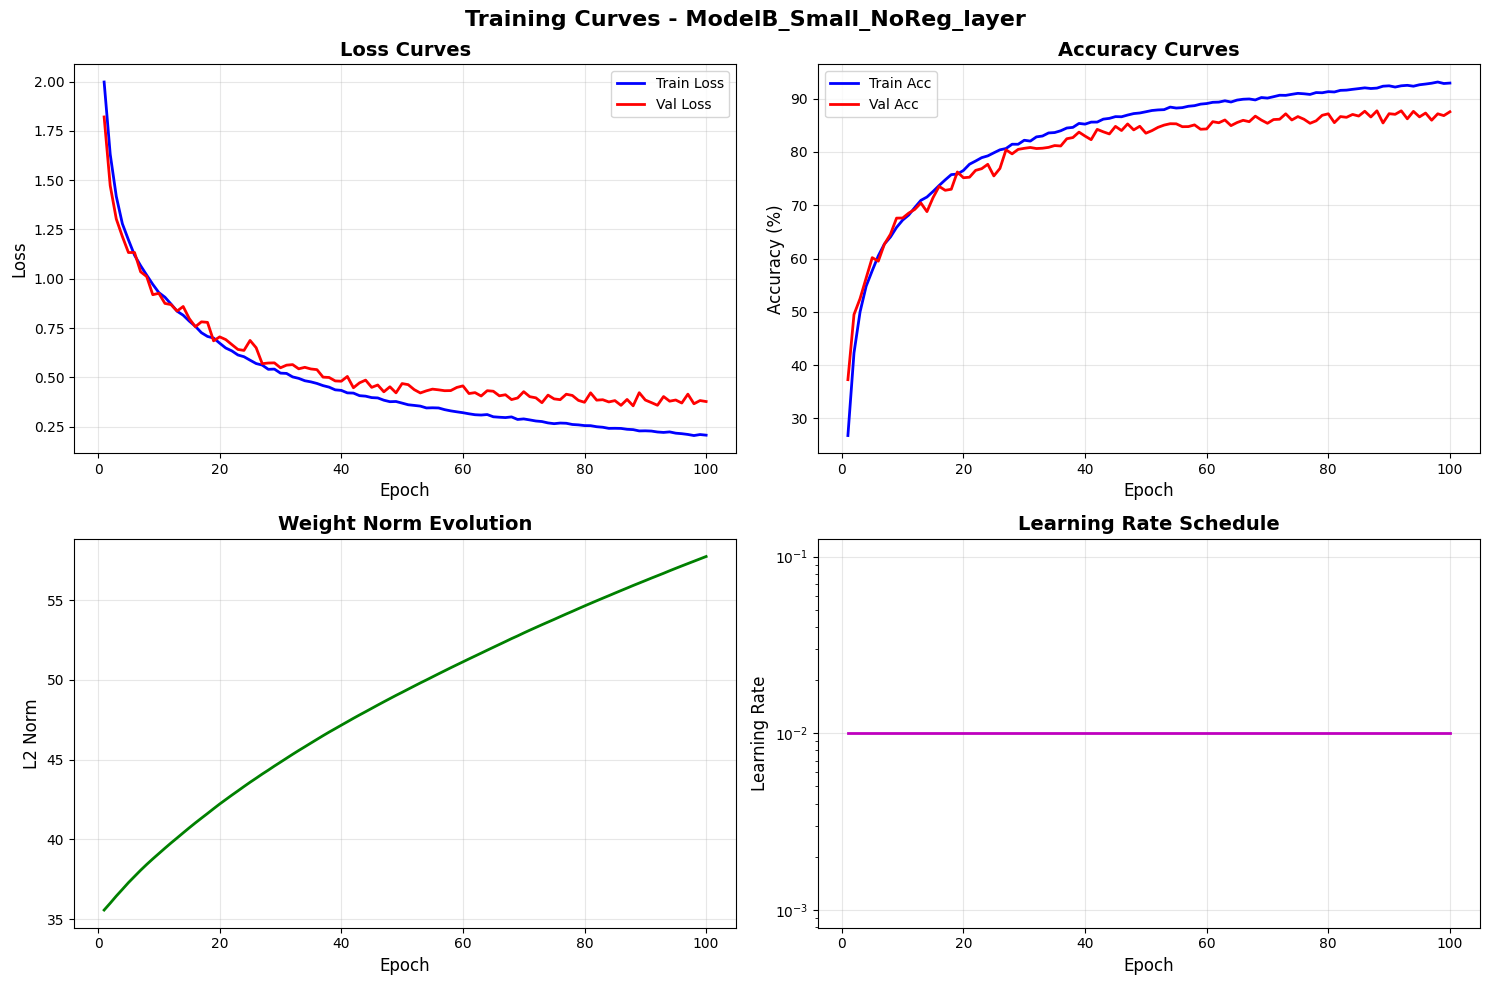

Bias-variance plot saved to: results/figures/ModelB_Small_NoReg_layer_bias_variance.png


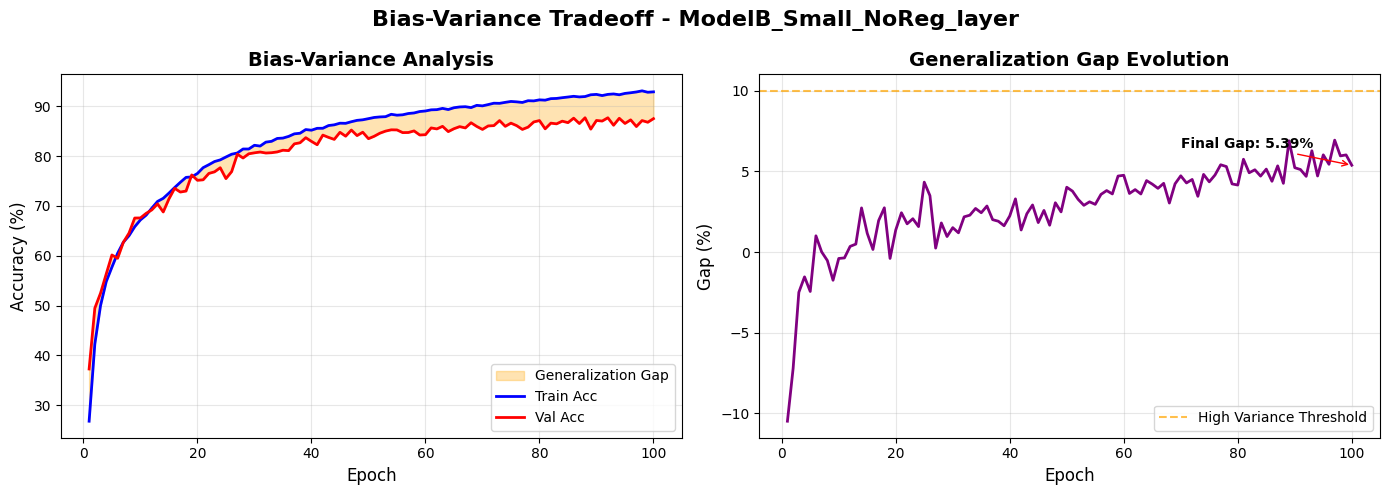

Confusion matrix saved to: results/figures/ModelB_Small_NoReg_layer_confusion.png


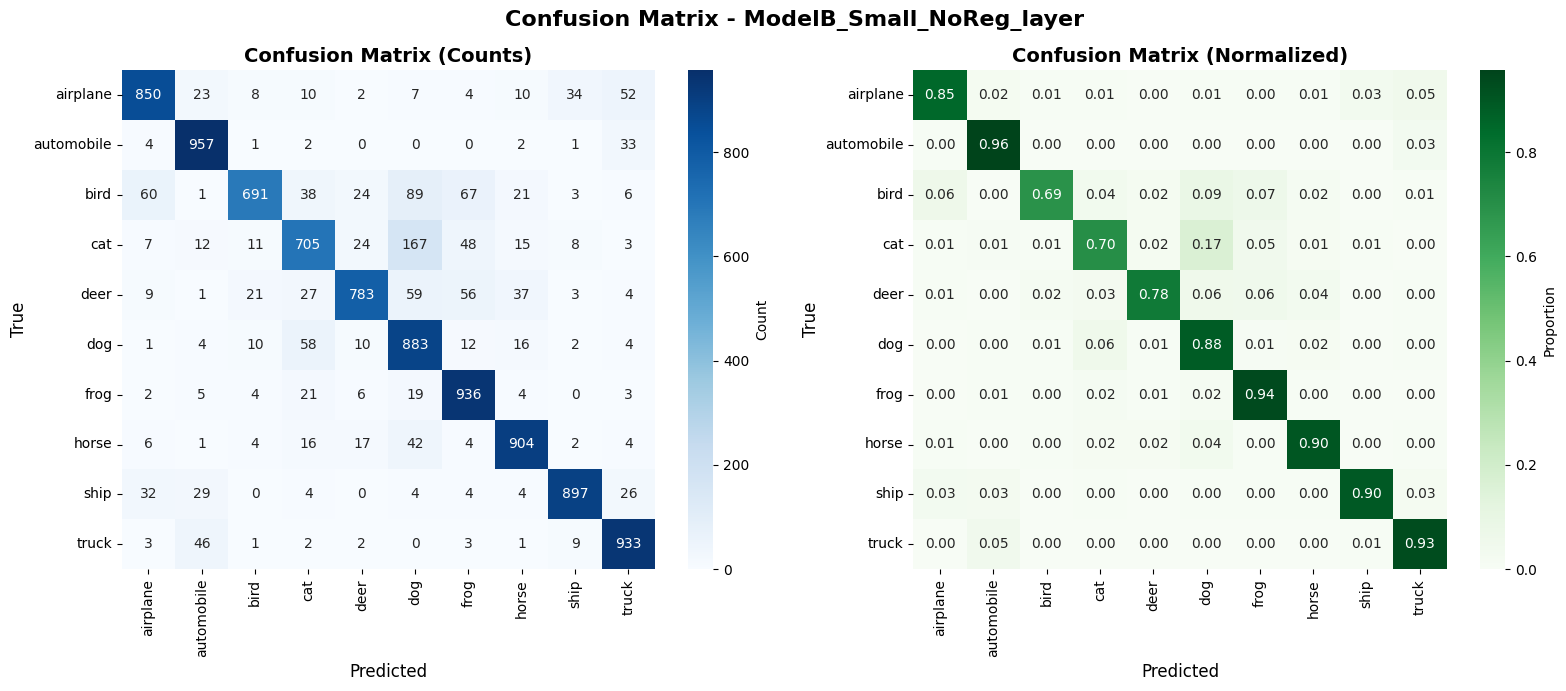


✓ Logged experiment: ModelB_layer_NoReg


In [21]:
# ============================================================================
# ModelB_layer_NoReg
# ============================================================================
print("\n" + "="*80)
print(" ModelB + LayerNorm + Sin Regularización")
print("="*80)

results_B_layer_noreg = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='NoReg',
    norm_type='layer',          # ← LayerNorm
    weight_decay=0.0,           # ← Sin weight decay
    dropout_rate=0.0,           # ← Sin dropout
    use_early_stopping=False,   # ← Sin early stopping
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


 ModelB + LayerNorm + Weight Decay

EXPERIMENT: ModelB_Small_WeightDecay_layer
Model: ModelB (Small)
Normalization: layer
Condition: WeightDecay
Weight Decay: 0.0005
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 2.0285 Acc:  24.66% | Val Loss: 1.8200 Acc:  34.26% | Time: 7.93s
Epoch   2/100 | Train Loss: 1.6932 Acc:  39.15% | Val Loss: 1.6450 Acc:  42.12% | Time: 8.02s
Epoch   3/100 | Train Loss: 1.4548 Acc:  48.60% | Val Loss: 1.3516 Acc:  51.30% | Time: 7.96s
Epoch   4/100 | Train Loss: 1.3226 Acc:  53.75% | Val Loss: 1.2964 Acc:  53.46% | Time: 8.03s
Epoch   5/100 | Train Loss: 1.2229 Acc:  56.97% | Val Loss: 1.1351 Acc:  60.24% | Time: 7.97s
Epoch   6/100 | Train Loss: 1.1468 Acc:  59.64% | Val Loss: 1.0741 Acc:  62.68% | Time: 7.90s
Epoch   7/100 | Train Loss: 1.0898 Acc:  61.72% | Val Loss: 1.0107 Acc:  65.30% | Time: 7.90s
Epoch   8/100 | Train Loss: 1.0414 Acc:  63.41% | Val Loss: 0.9972 Acc:  65.46% | Time: 7.90s
Epoch   9/100 | Train Loss: 1.0111 Acc:  64.38% | Val Loss: 0.9918 Acc:  65.02% | Time: 7.89s
Epoch  10/100 | Train Loss: 0.9655 Acc:  66.12% | Val Loss: 0.9955 Acc:  64.28% | Tim

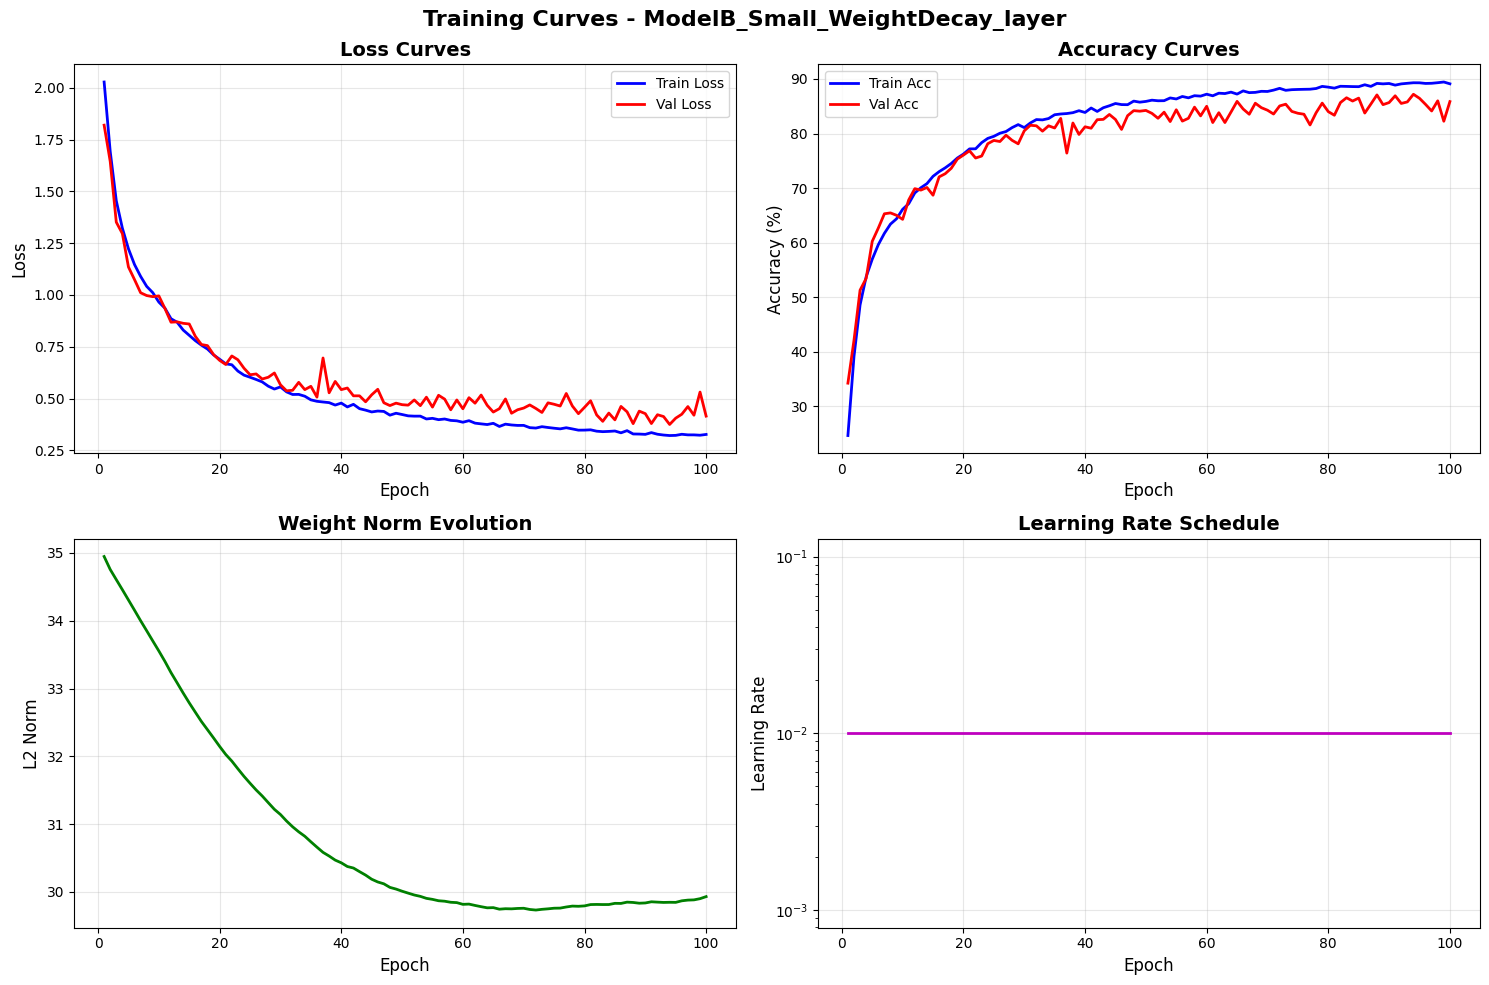

Bias-variance plot saved to: results/figures/ModelB_Small_WeightDecay_layer_bias_variance.png


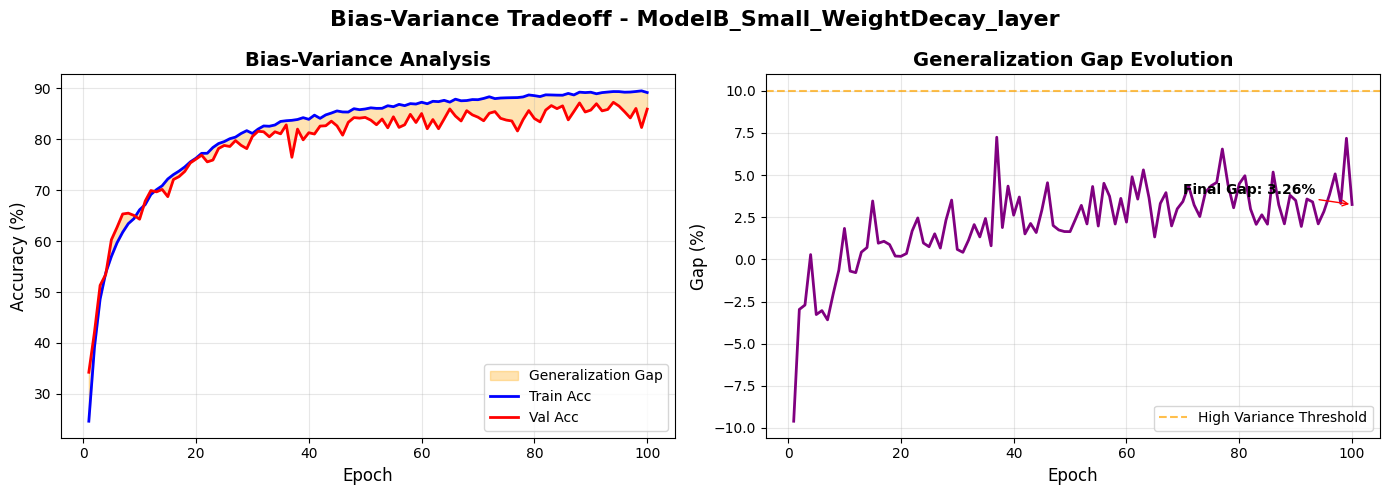

Confusion matrix saved to: results/figures/ModelB_Small_WeightDecay_layer_confusion.png


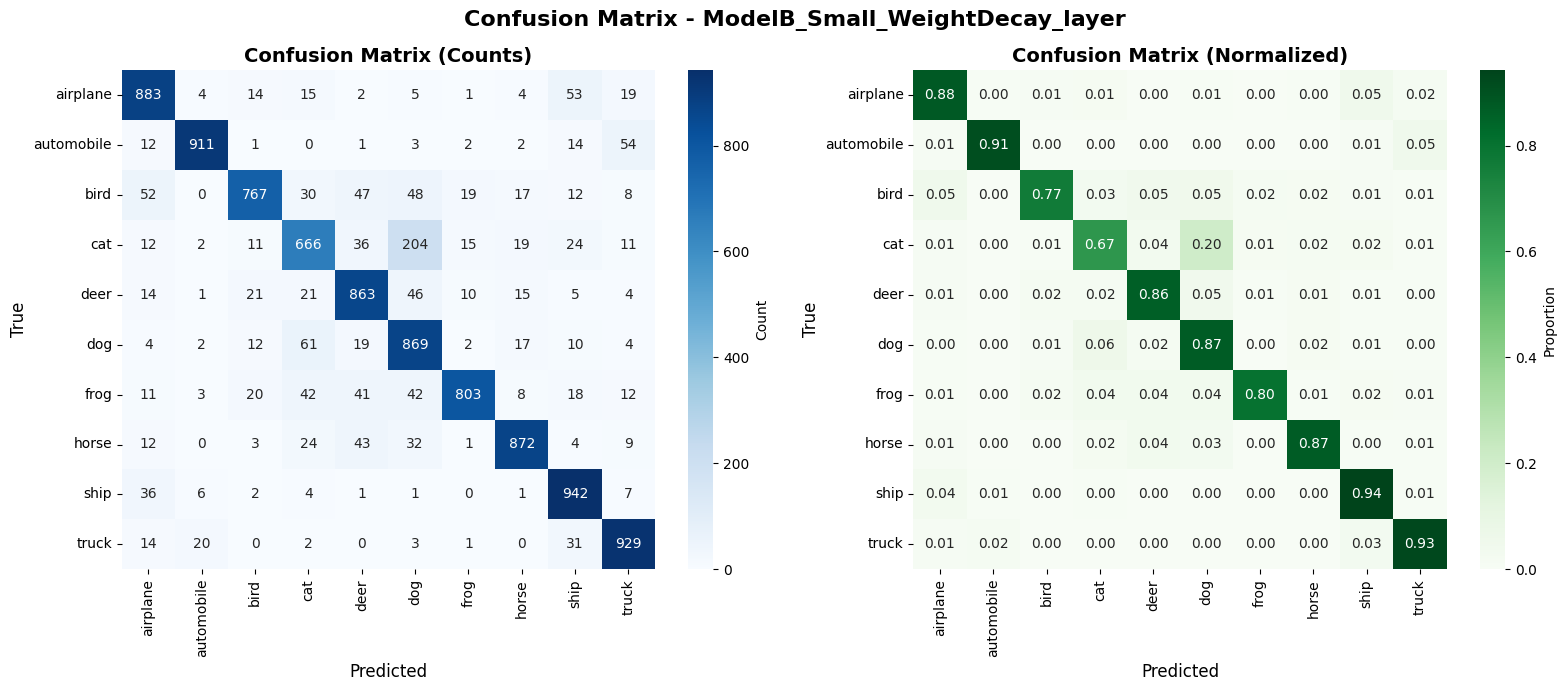


✓ Logged experiment: ModelB_layer_WeightDecay


In [22]:
# ============================================================================
# ModelB_layer_WeightDecay
# ============================================================================
print("\n" + "="*80)
print(" ModelB + LayerNorm + Weight Decay")
print("="*80)

results_B_layer_wd = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='WeightDecay',
    norm_type='layer',          # ← LayerNorm
    weight_decay=5e-4,          # ← L2 regularization
    dropout_rate=0.0,           # ← Sin dropout
    use_early_stopping=False,   # ← Sin early stopping
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


 ModelB + BatchNorm + Dropout

EXPERIMENT: ModelB_Small_Dropout_batch
Model: ModelB (Small)
Normalization: batch
Condition: Dropout
Weight Decay: 0.0
Dropout: 0.5
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.9783 Acc:  27.06% | Val Loss: 1.7679 Acc:  35.32% | Time: 7.91s
Epoch   2/100 | Train Loss: 1.7844 Acc:  35.21% | Val Loss: 1.6290 Acc:  41.78% | Time: 7.69s
Epoch   3/100 | Train Loss: 1.6619 Acc:  40.01% | Val Loss: 1.4897 Acc:  46.60% | Time: 7.92s
Epoch   4/100 | Train Loss: 1.5715 Acc:  43.66% | Val Loss: 1.4274 Acc:  49.24% | Time: 7.75s
Epoch   5/100 | Train Loss: 1.4951 Acc:  46.79% | Val Loss: 1.3809 Acc:  51.88% | Time: 7.64s
Epoch   6/100 | Train Loss: 1.4323 Acc:  48.77% | Val Loss: 1.2807 Acc:  55.02% | Time: 7.73s
Epoch   7/100 | Train Loss: 1.3787 Acc:  50.88% | Val Loss: 1.2190 Acc:  57.44% | Time: 7.87s
Epoch   8/100 | Train Loss: 1.3274 Acc:  52.99% | Val Loss: 1.2027 Acc:  57.32% | Time: 7.69s
Epoch   9/100 | Train Loss: 1.2882 Acc:  54.63% | Val Loss: 1.1517 Acc:  59.90% | Time: 7.64s
Epoch  10/100 | Train Loss: 1.2424 Acc:  56.29% | Val Loss: 1.0802 Acc:  61.94% | Tim

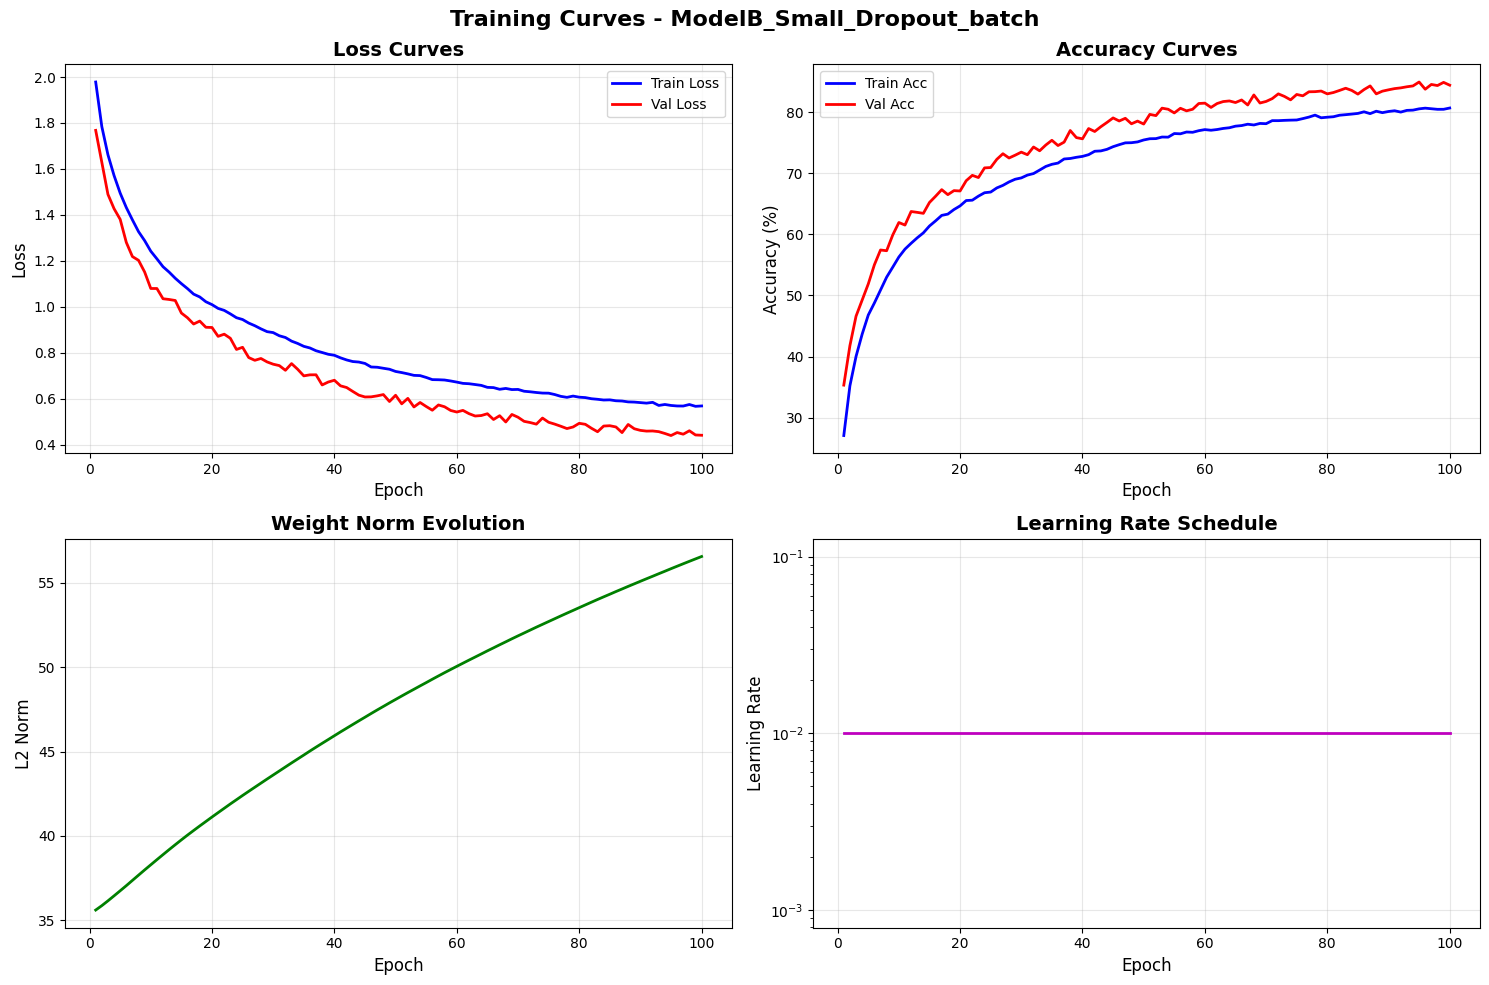

Bias-variance plot saved to: results/figures/ModelB_Small_Dropout_batch_bias_variance.png


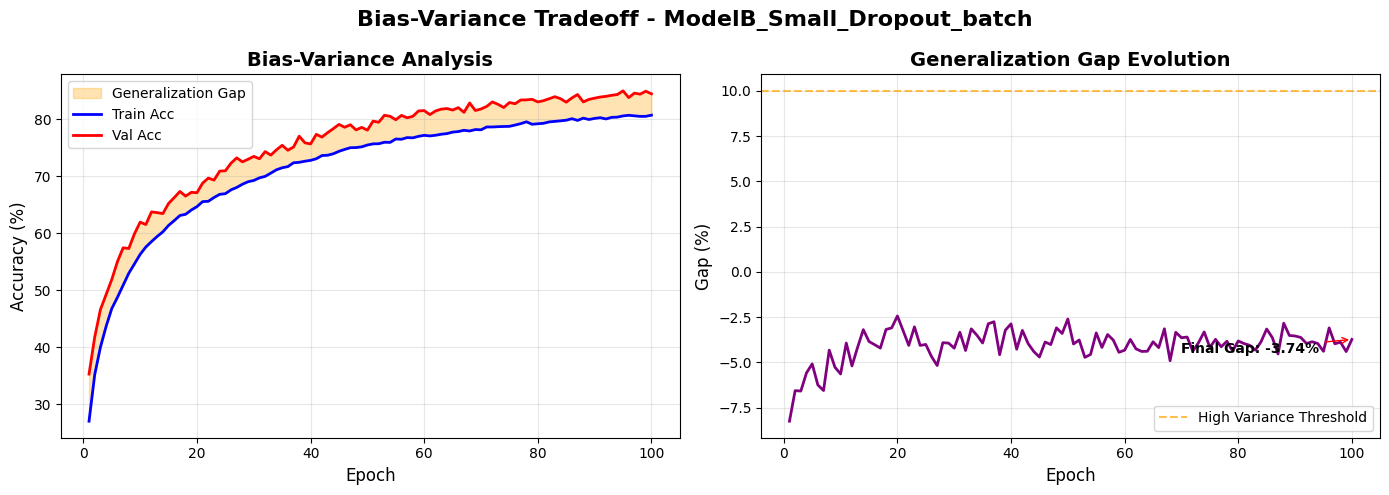

Confusion matrix saved to: results/figures/ModelB_Small_Dropout_batch_confusion.png


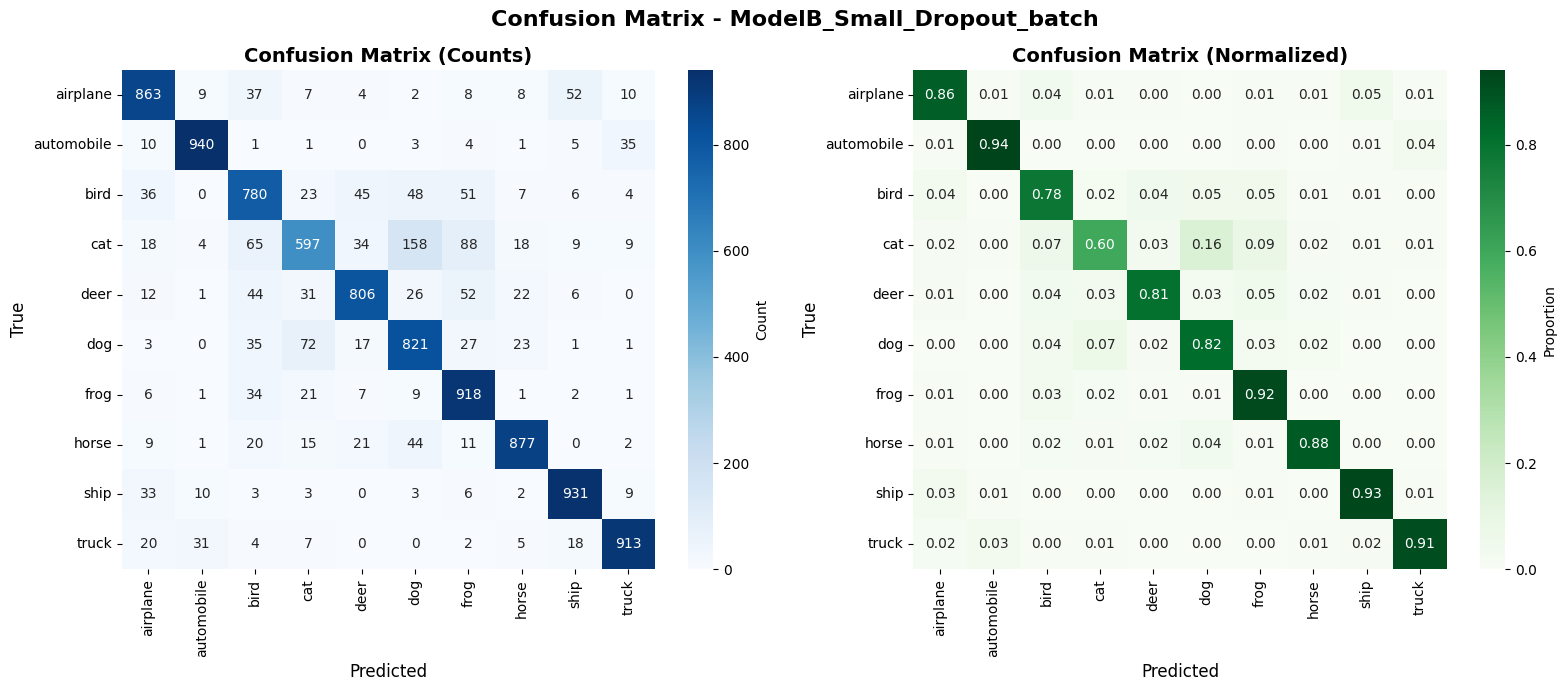


✓ Logged experiment: ModelB_batch_Dropout


In [23]:
# ============================================================================
# ModelB_batch_Dropout
# ============================================================================
print("\n" + "="*80)
print(" ModelB + BatchNorm + Dropout")
print("="*80)

results_B_batch_dropout = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='Dropout',
    norm_type='batch',          # ← BatchNorm
    weight_decay=0.0,           # ← Sin weight decay
    dropout_rate=0.5,           # ← 50% dropout
    use_early_stopping=False,   # ← Sin early stopping
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


 ModelB + LayerNorm + Dropout

EXPERIMENT: ModelB_Small_Dropout_layer
Model: ModelB (Small)
Normalization: layer
Condition: Dropout
Weight Decay: 0.0
Dropout: 0.5
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 2.1194 Acc:  20.33% | Val Loss: 1.9845 Acc:  24.70% | Time: 8.10s
Epoch   2/100 | Train Loss: 1.9409 Acc:  27.53% | Val Loss: 1.8409 Acc:  31.34% | Time: 8.17s
Epoch   3/100 | Train Loss: 1.8201 Acc:  32.22% | Val Loss: 1.6921 Acc:  37.10% | Time: 8.18s
Epoch   4/100 | Train Loss: 1.7282 Acc:  35.68% | Val Loss: 1.6223 Acc:  41.38% | Time: 8.17s
Epoch   5/100 | Train Loss: 1.6540 Acc:  39.28% | Val Loss: 1.5164 Acc:  45.08% | Time: 8.14s
Epoch   6/100 | Train Loss: 1.5845 Acc:  42.06% | Val Loss: 1.4560 Acc:  47.42% | Time: 8.15s
Epoch   7/100 | Train Loss: 1.5208 Acc:  44.48% | Val Loss: 1.4624 Acc:  46.76% | Time: 8.06s
Epoch   8/100 | Train Loss: 1.4765 Acc:  46.25% | Val Loss: 1.4217 Acc:  48.96% | Time: 8.04s
Epoch   9/100 | Train Loss: 1.4136 Acc:  49.00% | Val Loss: 1.3331 Acc:  52.24% | Time: 8.14s
Epoch  10/100 | Train Loss: 1.3806 Acc:  50.10% | Val Loss: 1.2262 Acc:  56.30% | Tim

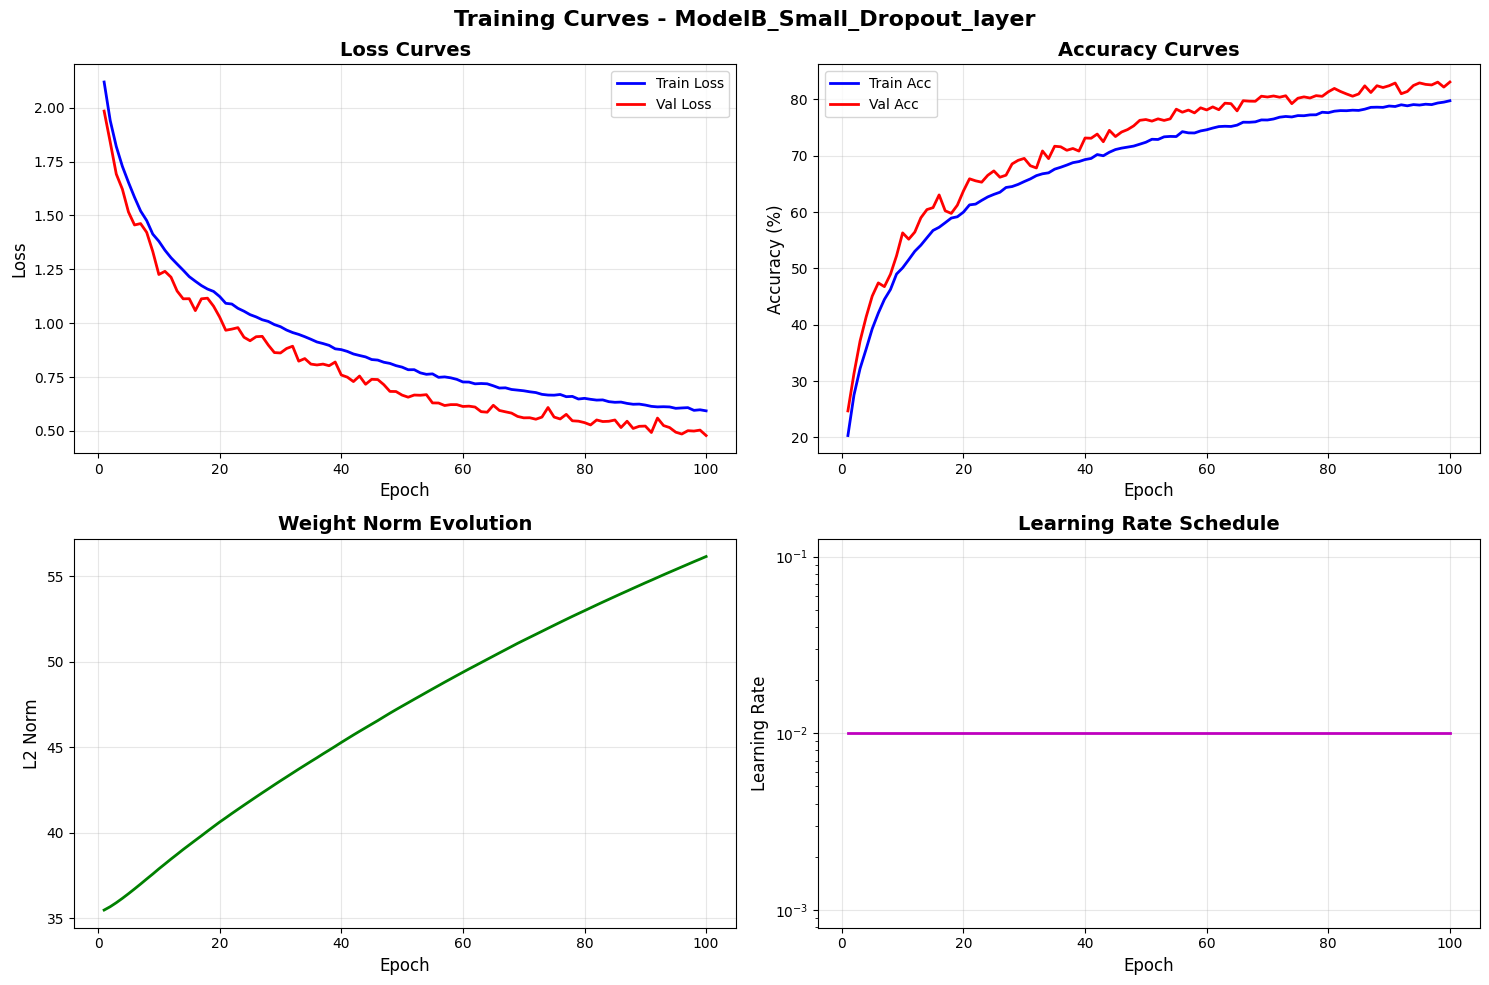

Bias-variance plot saved to: results/figures/ModelB_Small_Dropout_layer_bias_variance.png


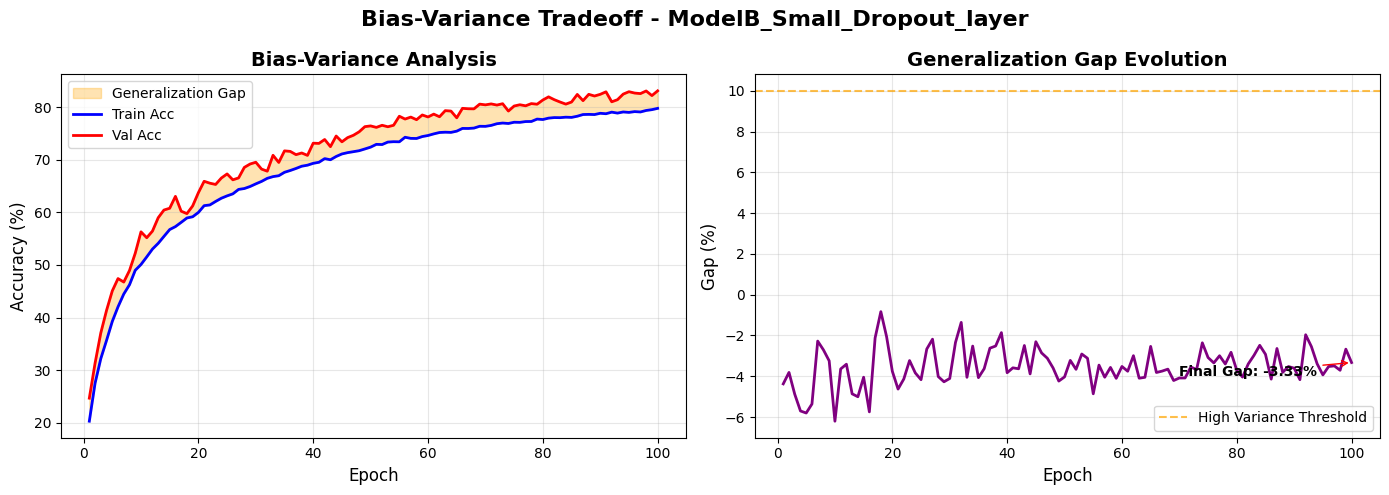

Confusion matrix saved to: results/figures/ModelB_Small_Dropout_layer_confusion.png


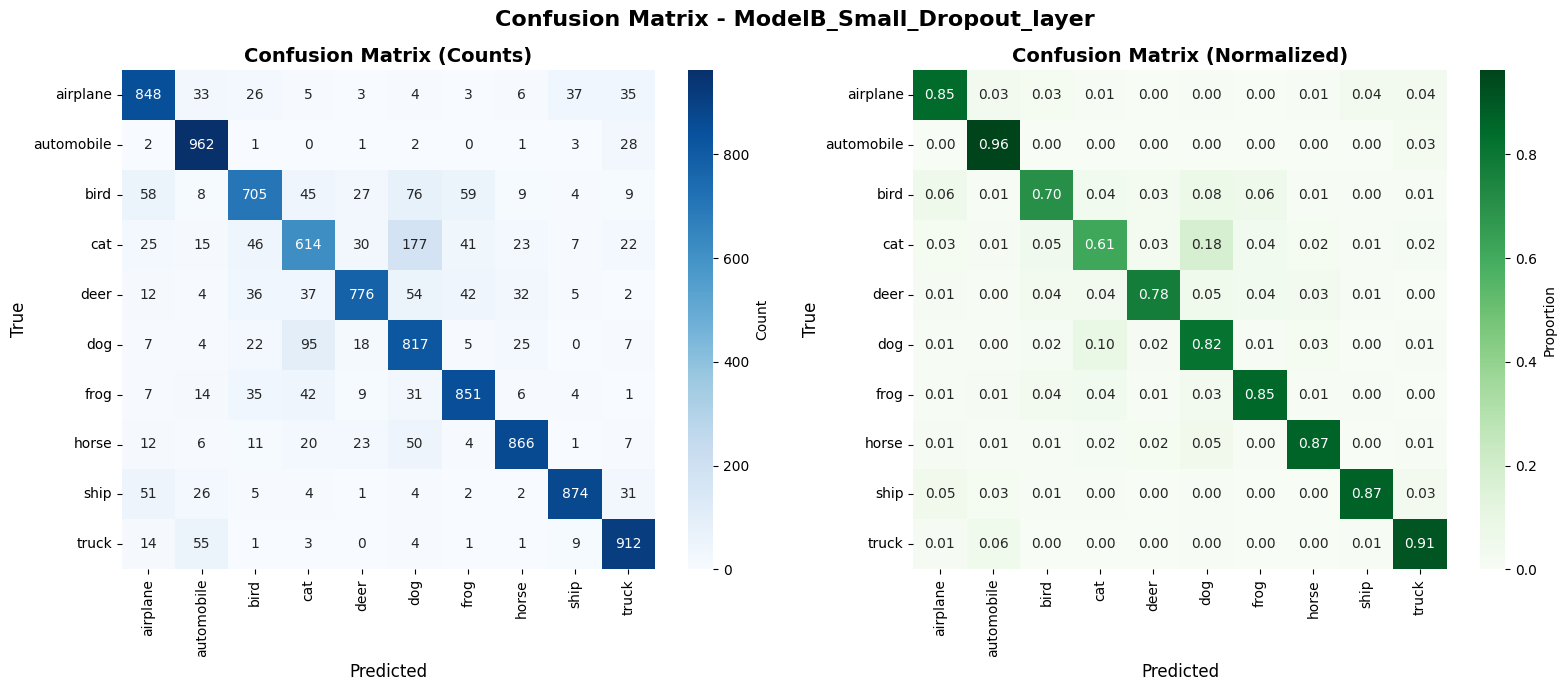


✓ Logged experiment: ModelB_layer_Dropout


In [24]:
# ============================================================================
# ModelB_layer_Dropout
# ============================================================================
print("\n" + "="*80)
print(" ModelB + LayerNorm + Dropout")
print("="*80)

results_B_layer_dropout = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='Dropout',
    norm_type='layer',          # ← LayerNorm
    weight_decay=0.0,           # ← Sin weight decay
    dropout_rate=0.5,           # ← 50% dropout
    use_early_stopping=False,   # ← Sin early stopping
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


 ModelB + LayerNorm + Combinado + Early Stop

EXPERIMENT: ModelB_Small_Combined_layer
Model: ModelB (Small)
Normalization: layer
Condition: Combined
Weight Decay: 0.0005
Dropout: 0.5
Early Stopping: True
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/150 | Train Loss: 2.1274 Acc:  19.90% | Val Loss: 1.9824 Acc:  27.74% | Time: 8.07s
Epoch   2/150 | Train Loss: 1.9460 Acc:  27.54% | Val Loss: 1.8440 Acc:  32.78% | Time: 8.05s
Epoch   3/150 | Train Loss: 1.8302 Acc:  32.26% | Val Loss: 1.7063 Acc:  39.22% | Time: 8.03s
Epoch   4/150 | Train Loss: 1.7333 Acc:  36.08% | Val Loss: 1.6294 Acc:  39.84% | Time: 7.97s
Epoch   5/150 | Train Loss: 1.6521 Acc:  39.51% | Val Loss: 1.5281 Acc:  44.54% | Time: 8.03s
Epoch   6/150 | Train Loss: 1.6065 Acc:  41.15% | Val Loss: 1.4732 Acc:  47.34% | Time: 8.05s
Epoch   7/150 | Train Loss: 1.5486 Acc:  43.77% | Val Loss: 1.4208 Acc:  49.44% | Time: 8.03s
Epoch   8/150 | Train Loss: 1.5001 Acc:  45.81% | Val Loss: 1.3606 Acc:  52.12% | Time: 7.97s
Epoch   9/150 | Train Loss: 1.4499 Acc:  47.38% | Val Loss: 1.3523 Acc:  50.82% | Time: 7.97s
Epoch  10/150 | Train Loss: 1.4177 Acc:  48.60% | Val Loss: 1.3245 Acc:  52.18% | Tim

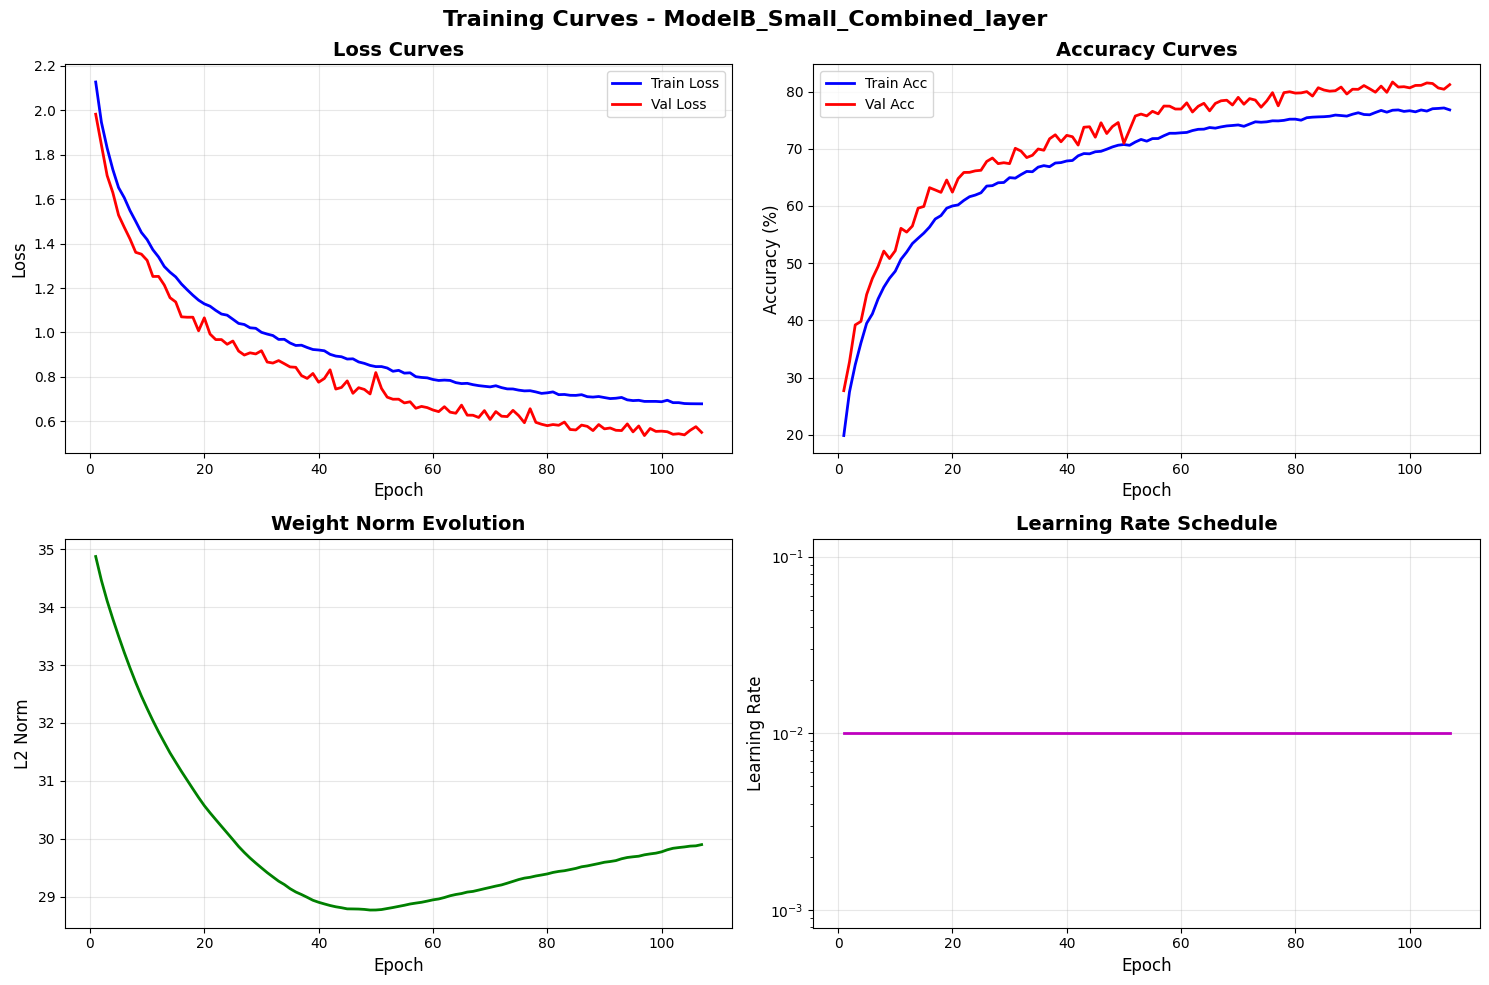

Bias-variance plot saved to: results/figures/ModelB_Small_Combined_layer_bias_variance.png


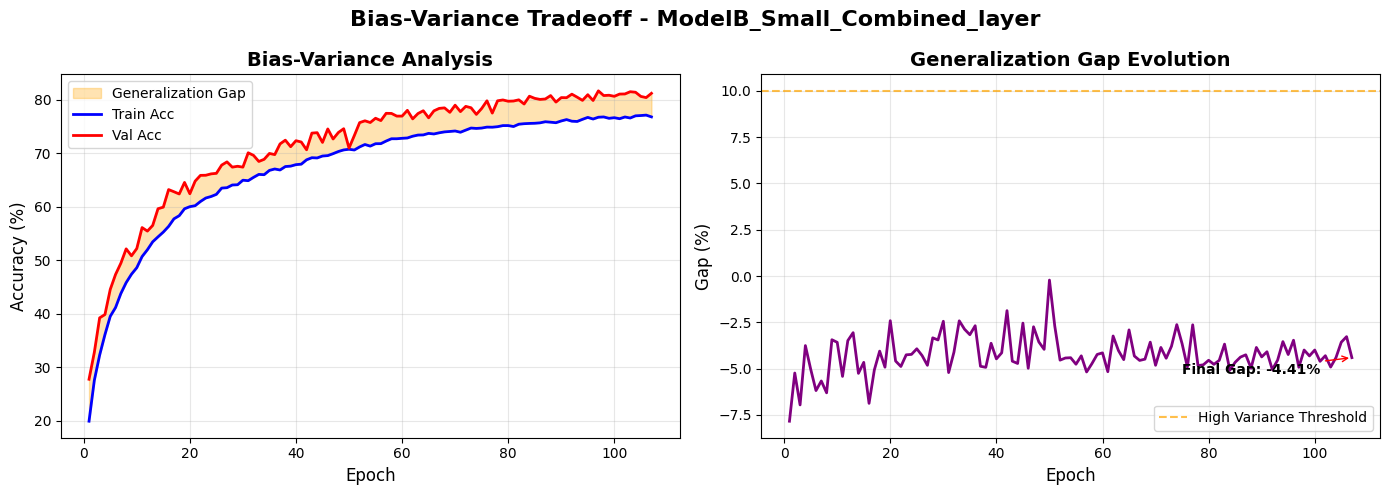

Confusion matrix saved to: results/figures/ModelB_Small_Combined_layer_confusion.png


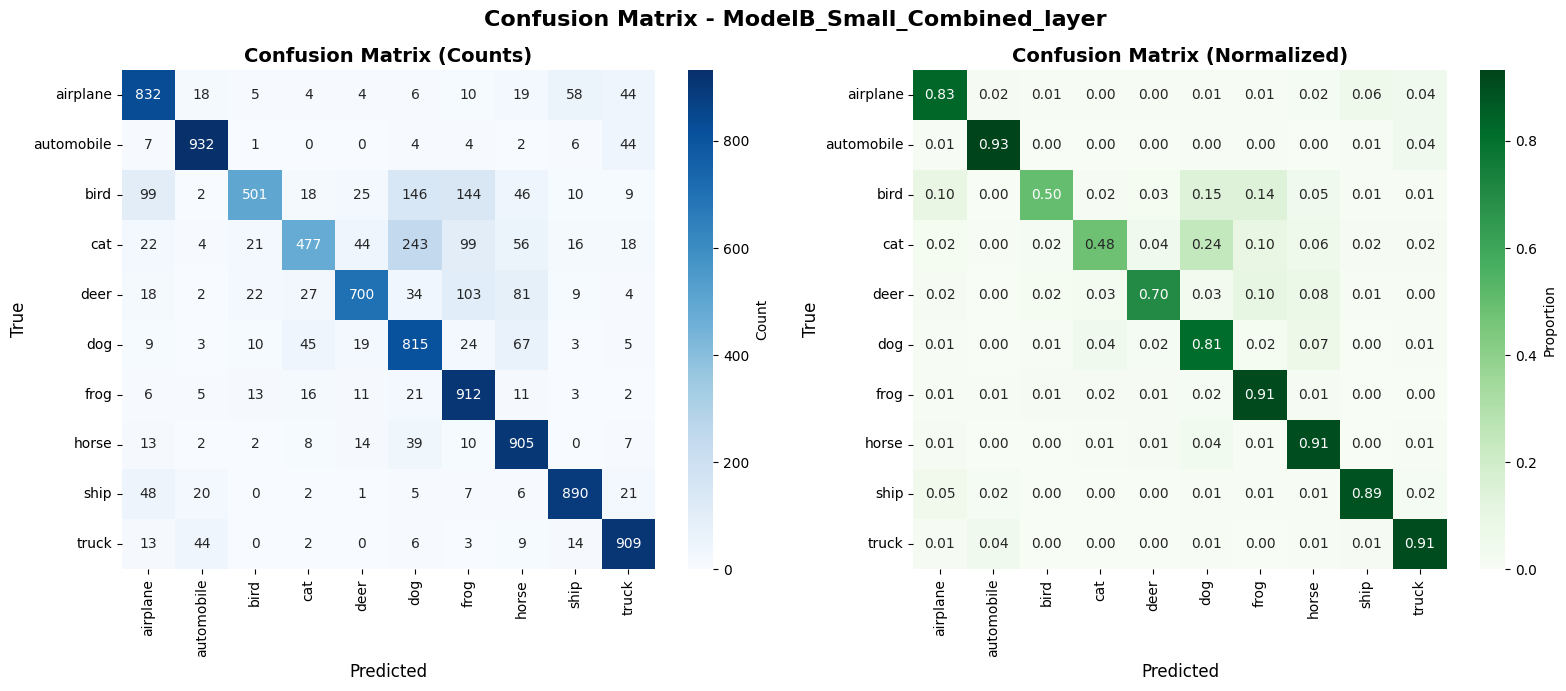


✓ Logged experiment: ModelB_layer_Combined


In [25]:
# ============================================================================
# ModelB_layer_Combined
# ============================================================================
print("\n" + "="*80)
print(" ModelB + LayerNorm + Combinado + Early Stop")
print("="*80)

results_B_layer_combined = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='Combined',
    norm_type='layer',          # ← LayerNorm
    weight_decay=5e-4,          # ← L2 regularization
    dropout_rate=0.5,           # ← 50% dropout
    use_early_stopping=True,    # ← Early stopping activado
    num_epochs=150,             # ← Mayor budget (se detendrá antes)
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelB_Small_NoReg_batch
Model: ModelB (Small)
Normalization: batch
Condition: NoReg
Weight Decay: 0.0
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)

Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.5940 Acc:  46.97% | Val Loss: 1.4025 Acc:  52.90% | Time: 8.57s
Epoch   2/100 | Train Loss: 1.2047 Acc:  60.26% | Val Loss: 1.2616 Acc:  56.36% | Time: 7.81s
Epoch   3/100 | Train Loss: 1.0340 Acc:  65.59% | Val Loss: 1.1223 Acc:  61.02% | Time: 7.83s
Epoch   4/100 | Train Loss: 0.9314 Acc:  69.01% | Val Loss: 0.9200 Acc:  68.58% | Time: 7.84s
Epoch   5/100 | Train Loss: 0.8480 Acc:  71.69% | Val Loss: 0.9515 Acc:  67.26% | Time: 7.83s
Epoch   6/100 | Train Loss: 0.7919 Acc:  73.71% | Val Loss: 0.8855 Acc:  69.94% | Time: 7.81s
Epoch   7/100 | Train Loss: 0.7392 Acc:  75.52% | Val Loss: 0.8405 Acc:  70.68% | Time: 7.87s
Epoch   8/100 | Train Loss: 0.6925 Acc:  77.11% |

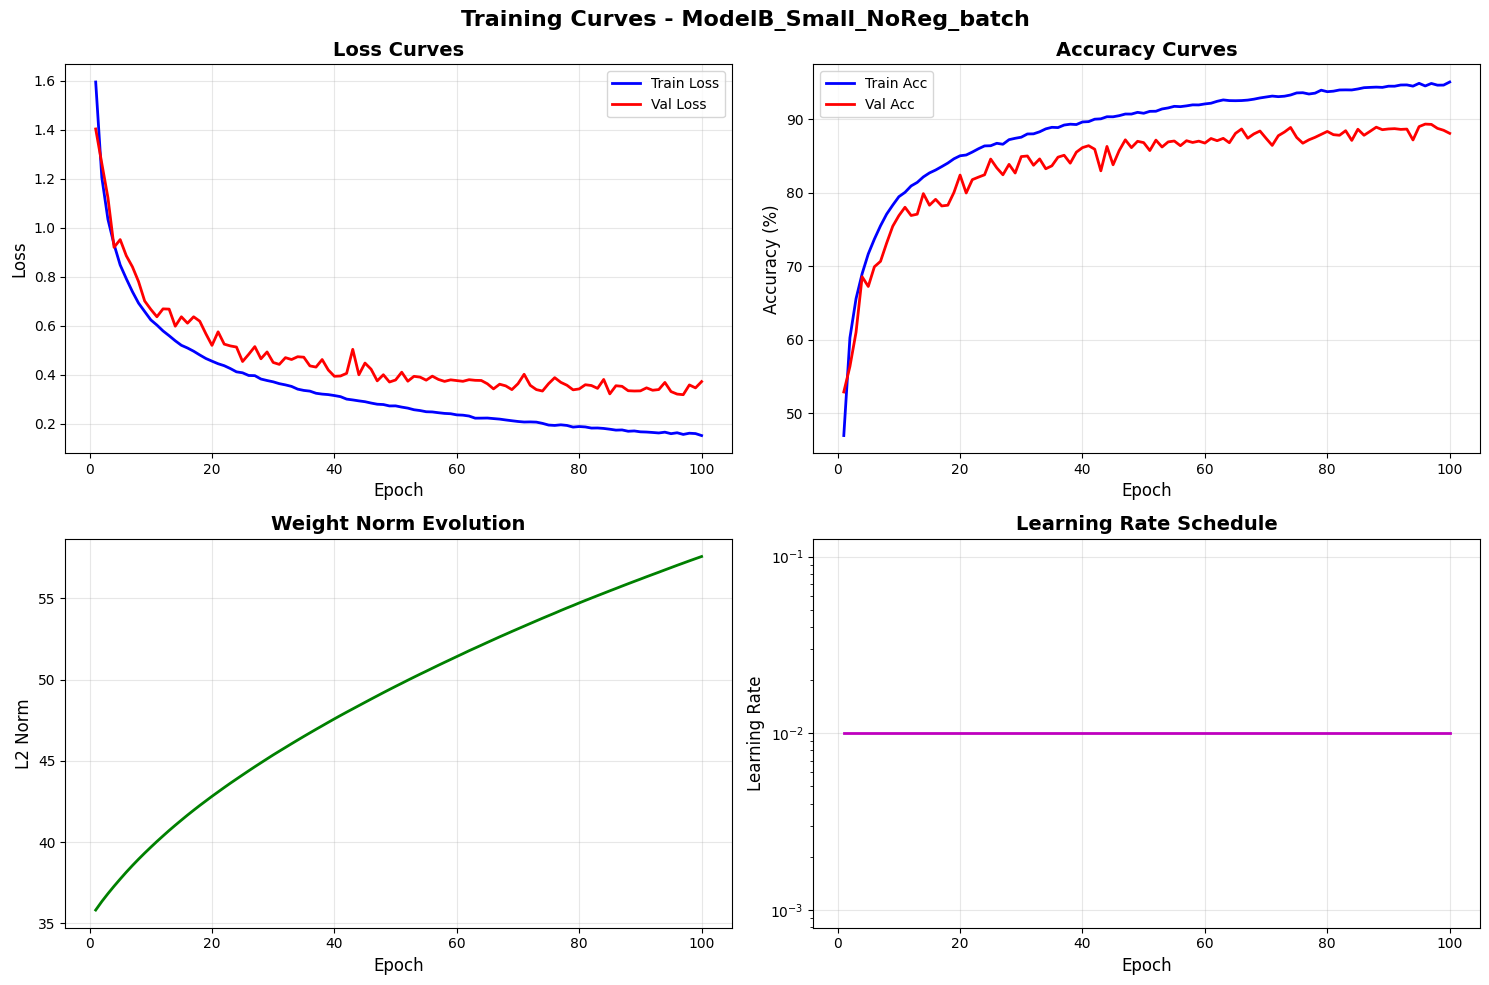

Bias-variance plot saved to: results/figures/ModelB_Small_NoReg_batch_bias_variance.png


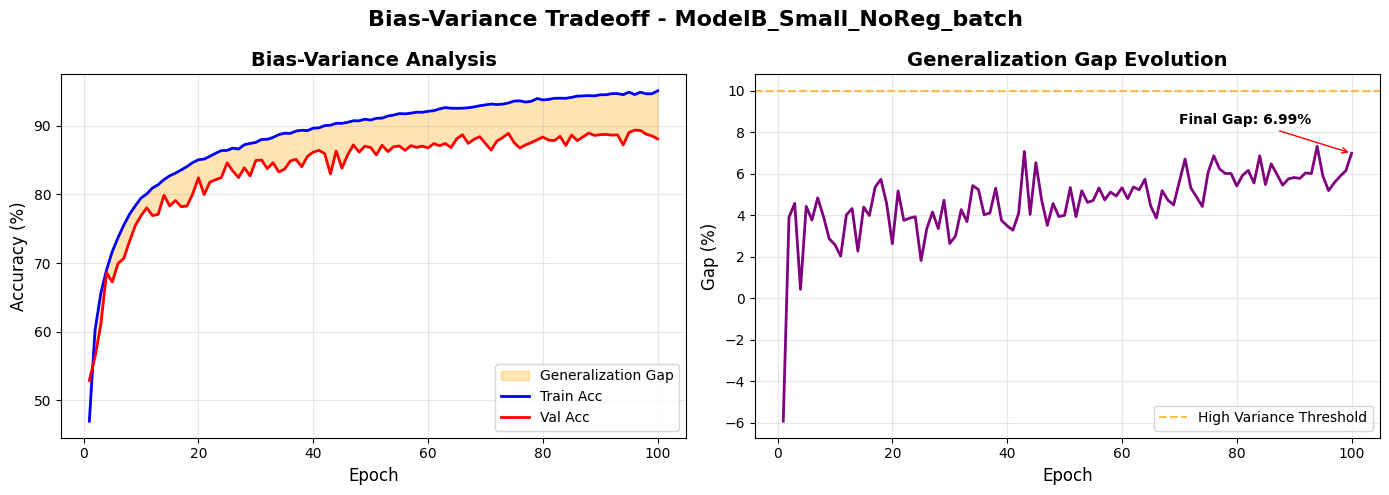

Confusion matrix saved to: results/figures/ModelB_Small_NoReg_batch_confusion.png


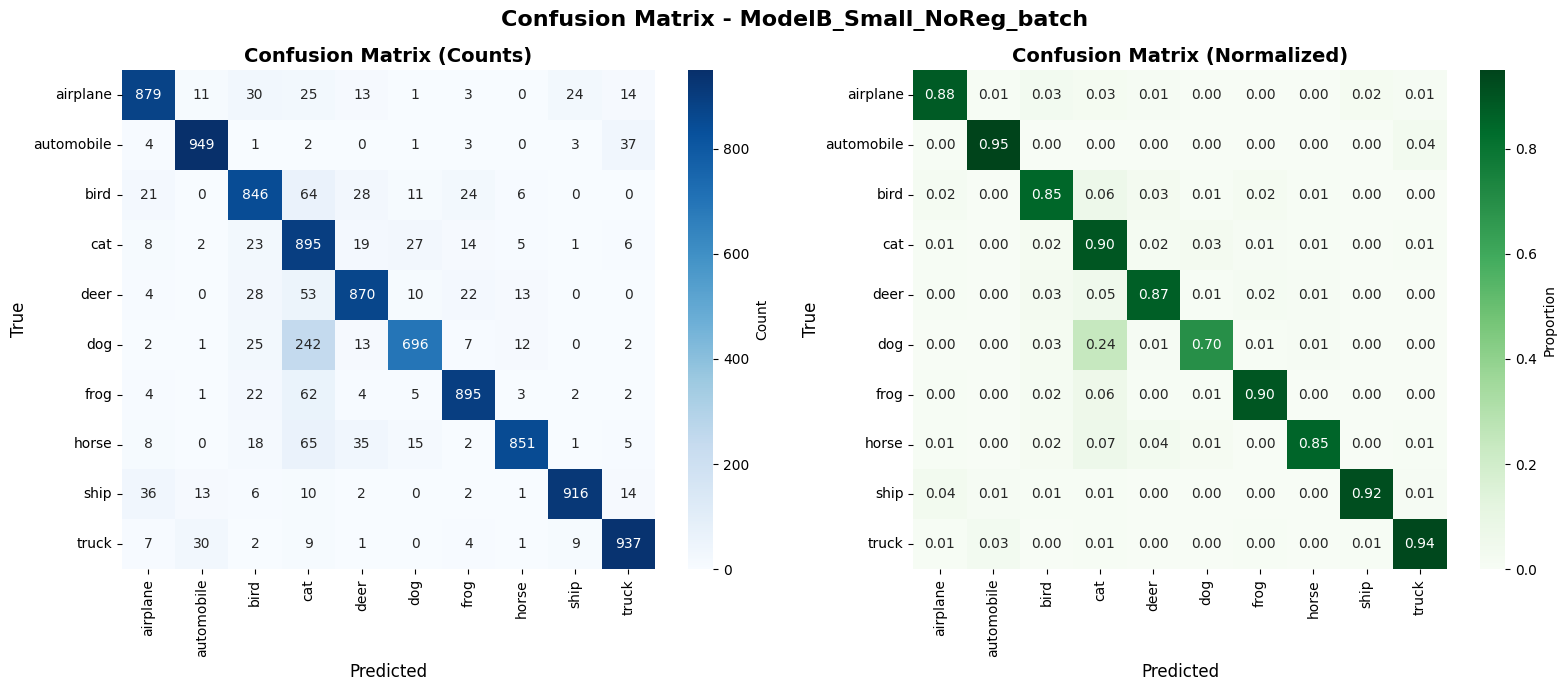


✓ Logged experiment: ModelB_batch_NoReg


In [13]:
# Model B - Small - No Regularization - BatchNorm
results_B_no_reg_bn = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='NoReg',
    norm_type='batch',
    weight_decay=0.0,
    dropout_rate=0.0,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelB_Small_WeightDecay_batch
Model: ModelB (Small)
Normalization: batch
Condition: WeightDecay
Weight Decay: 0.0005
Dropout: 0.0
Early Stopping: False
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/100 | Train Loss: 1.5848 Acc:  47.92% | Val Loss: 1.4299 Acc:  51.16% | Time: 7.93s
Epoch   2/100 | Train Loss: 1.1991 Acc:  60.61% | Val Loss: 1.2131 Acc:  58.20% | Time: 7.91s
Epoch   3/100 | Train Loss: 1.0337 Acc:  65.83% | Val Loss: 1.2141 Acc:  57.52% | Time: 7.91s
Epoch   4/100 | Train Loss: 0.9265 Acc:  69.36% | Val Loss: 0.9687 Acc:  67.16% | Time: 7.91s
Epoch   5/100 | Train Loss: 0.8438 Acc:  72.16% | Val Loss: 0.9687 Acc:  66.24% | Time: 7.88s
Epoch   6/100 | Train Loss: 0.7858 Acc:  74.21% | Val Loss: 0.8399 Acc:  70.56% | Time: 7.88s
Epoch   7/100 | Train Loss: 0.7371 Acc:  75.78% | Val Loss: 0.8289 Acc:  71.60% | Time: 7.86s
Epoch   8/100 | Train Loss: 0.6996 Acc:  76.93% | Val Loss: 0.7203 Acc:  75.98% | Time: 7.87s
Epoch   9/100 | Train Loss: 0.6611 Acc:  78.17% | Val Loss: 0.7667 Acc:  74.22% | Time: 7.85s
Epoch  10/100 | Train Loss: 0.6387 Acc:  78.88% | Val Loss: 0.7306 Acc:  75.04% | Tim

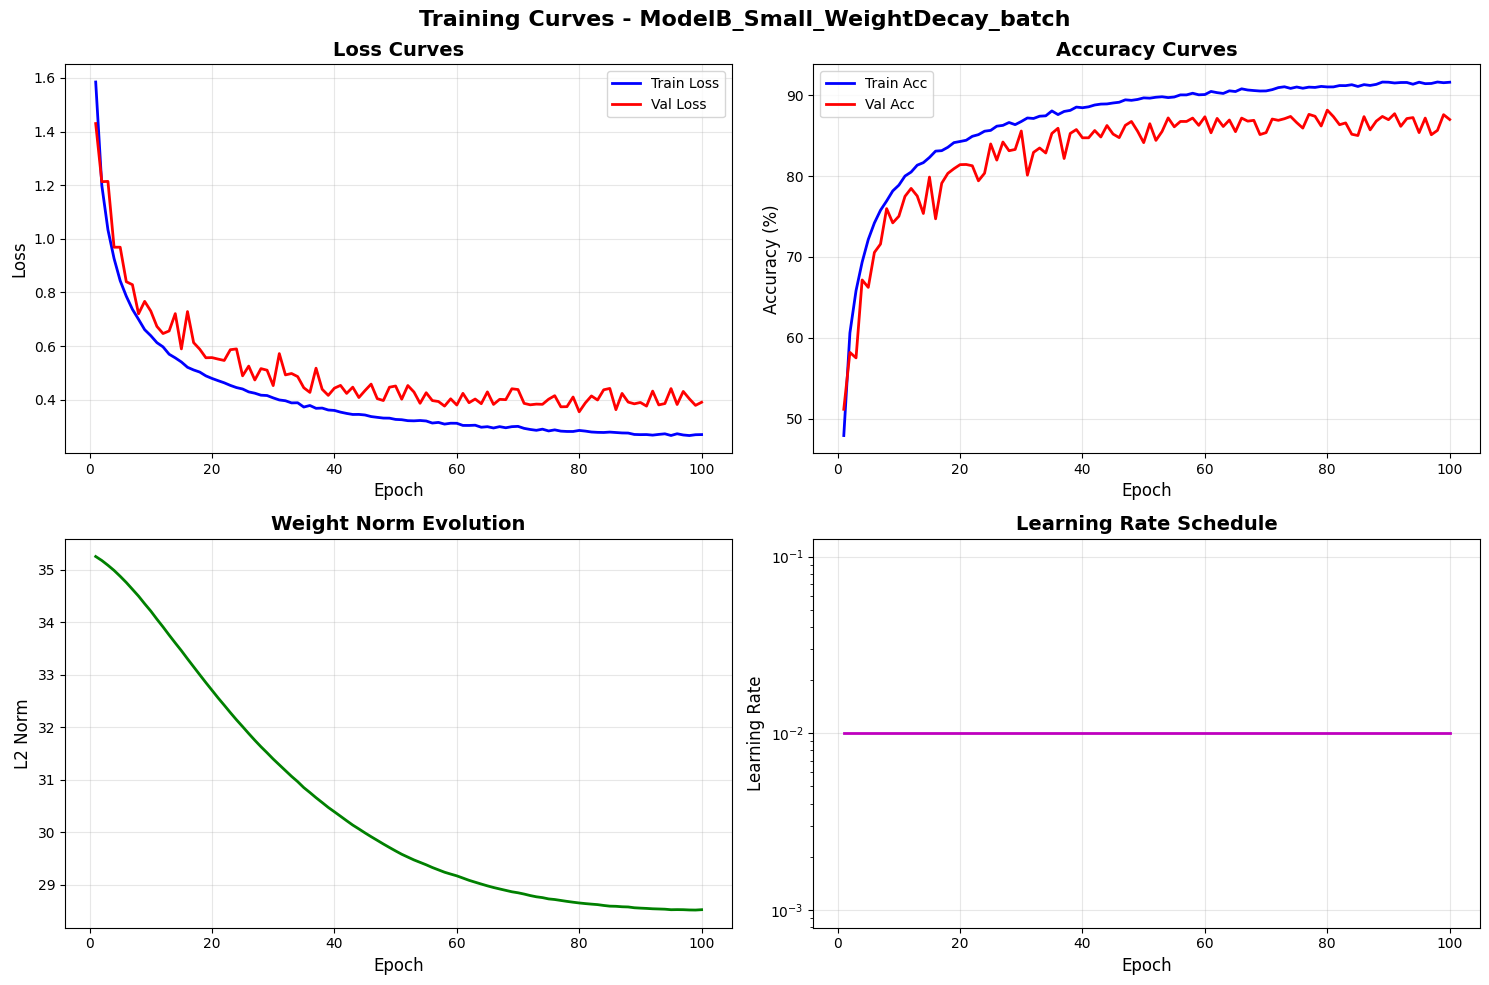

Bias-variance plot saved to: results/figures/ModelB_Small_WeightDecay_batch_bias_variance.png


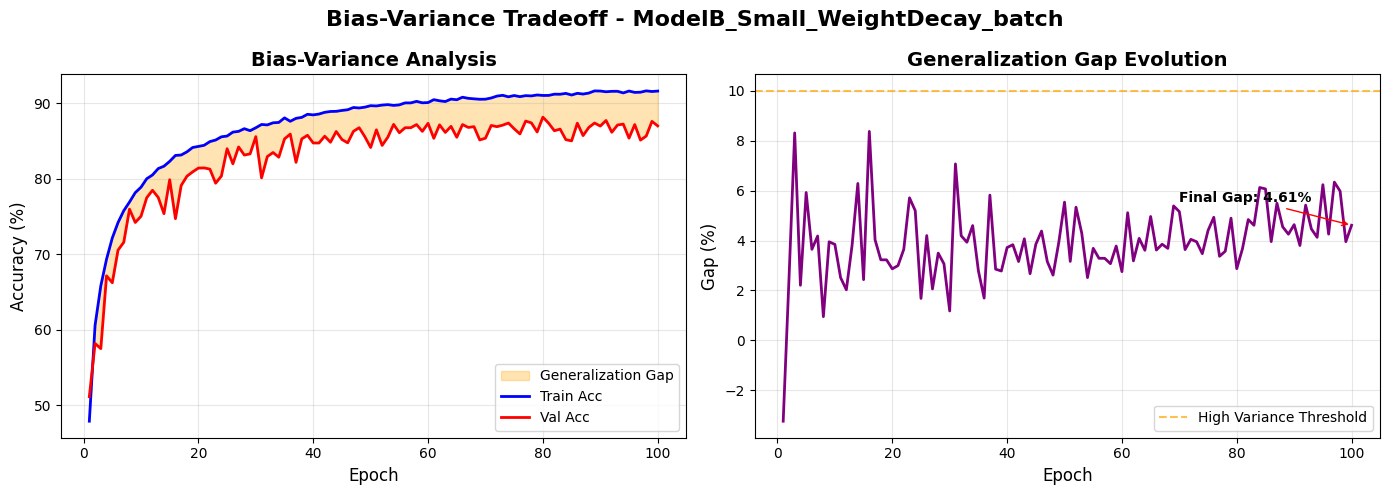

Confusion matrix saved to: results/figures/ModelB_Small_WeightDecay_batch_confusion.png


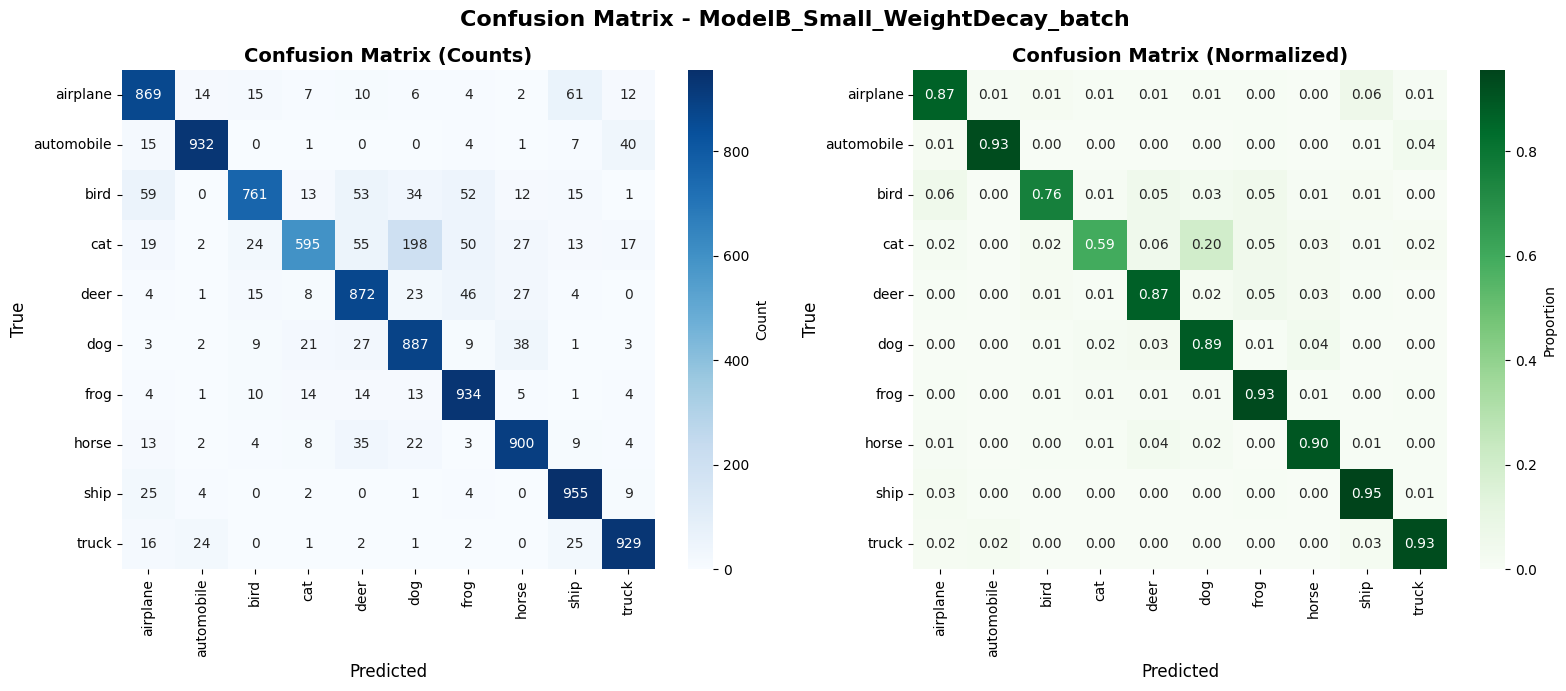


✓ Logged experiment: ModelB_batch_WeightDecay


In [14]:
# Model B - Small - Weight Decay - BatchNorm
results_B_wd_bn = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='WeightDecay',
    norm_type='batch',
    weight_decay=5e-4,
    dropout_rate=0.0,
    use_early_stopping=False,
    num_epochs=100,
    learning_rate=0.01,
    batch_size=128
)


EXPERIMENT: ModelB_Small_Combined_batch
Model: ModelB (Small)
Normalization: batch
Condition: Combined
Weight Decay: 0.0005
Dropout: 0.5
Early Stopping: True
Learning Rate: 0.01
Batch Size: 128

Model Parameters: 295,380 (0.295M)



/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Epoch   1/150 | Train Loss: 1.9866 Acc:  26.31% | Val Loss: 1.7901 Acc:  37.14% | Time: 7.94s
Epoch   2/150 | Train Loss: 1.7857 Acc:  35.01% | Val Loss: 1.6112 Acc:  42.04% | Time: 7.94s
Epoch   3/150 | Train Loss: 1.6506 Acc:  40.71% | Val Loss: 1.4951 Acc:  47.10% | Time: 7.94s
Epoch   4/150 | Train Loss: 1.5544 Acc:  44.30% | Val Loss: 1.4062 Acc:  49.38% | Time: 7.94s
Epoch   5/150 | Train Loss: 1.4747 Acc:  47.39% | Val Loss: 1.3173 Acc:  53.58% | Time: 7.95s
Epoch   6/150 | Train Loss: 1.4028 Acc:  50.15% | Val Loss: 1.2513 Acc:  56.14% | Time: 7.92s
Epoch   7/150 | Train Loss: 1.3483 Acc:  52.12% | Val Loss: 1.1931 Acc:  57.96% | Time: 7.92s
Epoch   8/150 | Train Loss: 1.2950 Acc:  54.27% | Val Loss: 1.1439 Acc:  59.78% | Time: 7.92s
Epoch   9/150 | Train Loss: 1.2541 Acc:  56.00% | Val Loss: 1.0947 Acc:  61.42% | Time: 7.93s
Epoch  10/150 | Train Loss: 1.2132 Acc:  57.40% | Val Loss: 1.0746 Acc:  62.24% | Tim

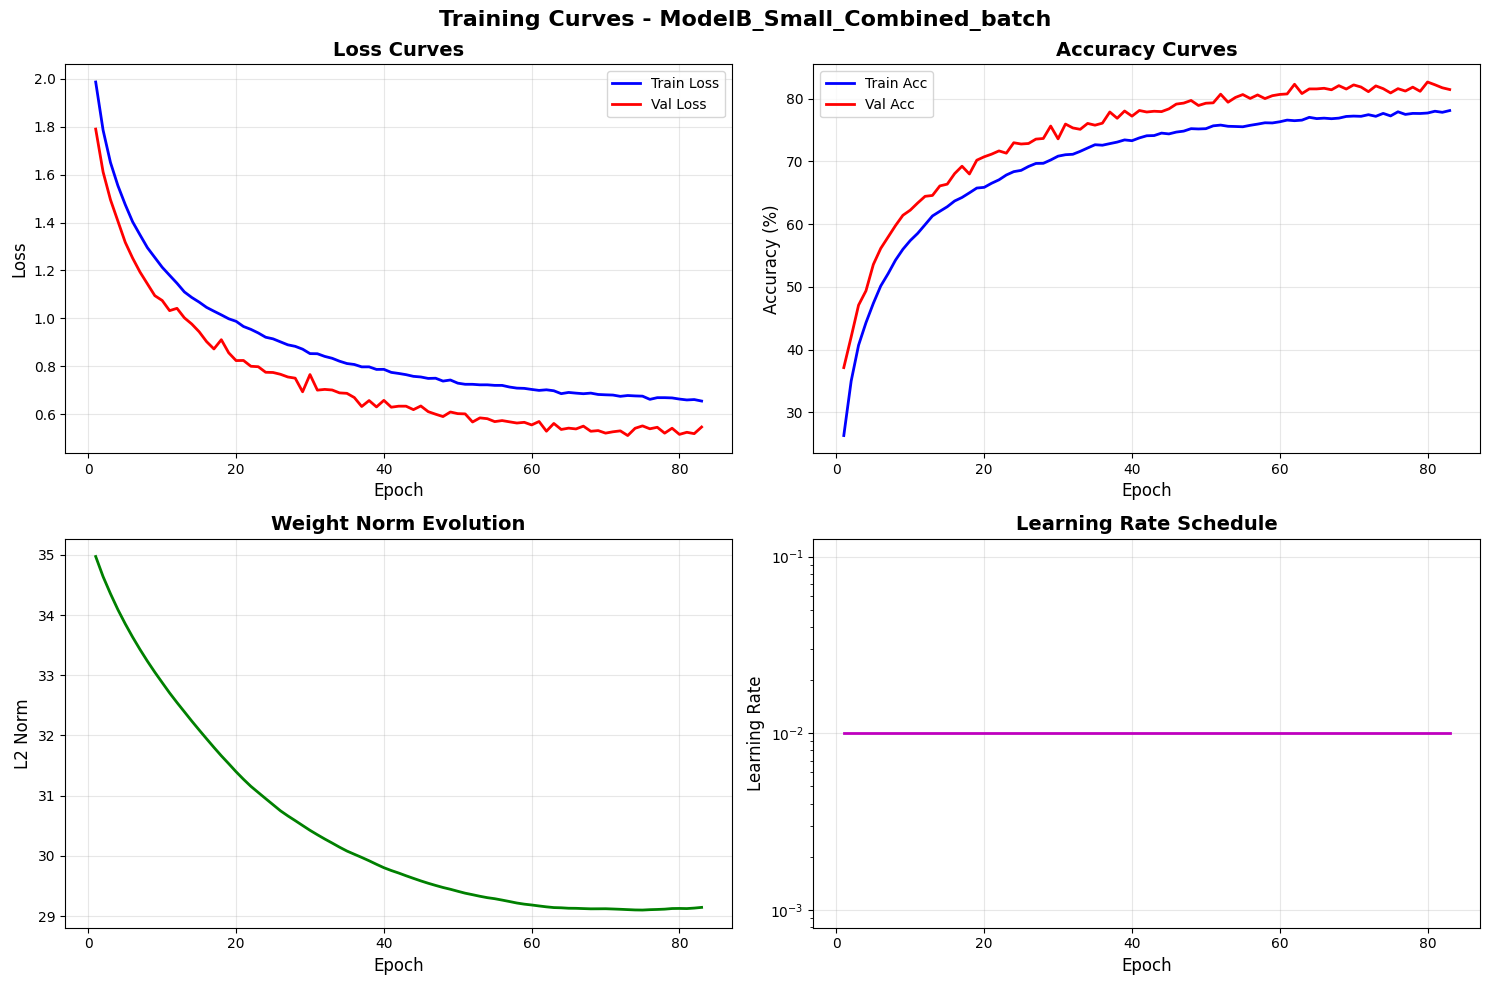

Bias-variance plot saved to: results/figures/ModelB_Small_Combined_batch_bias_variance.png


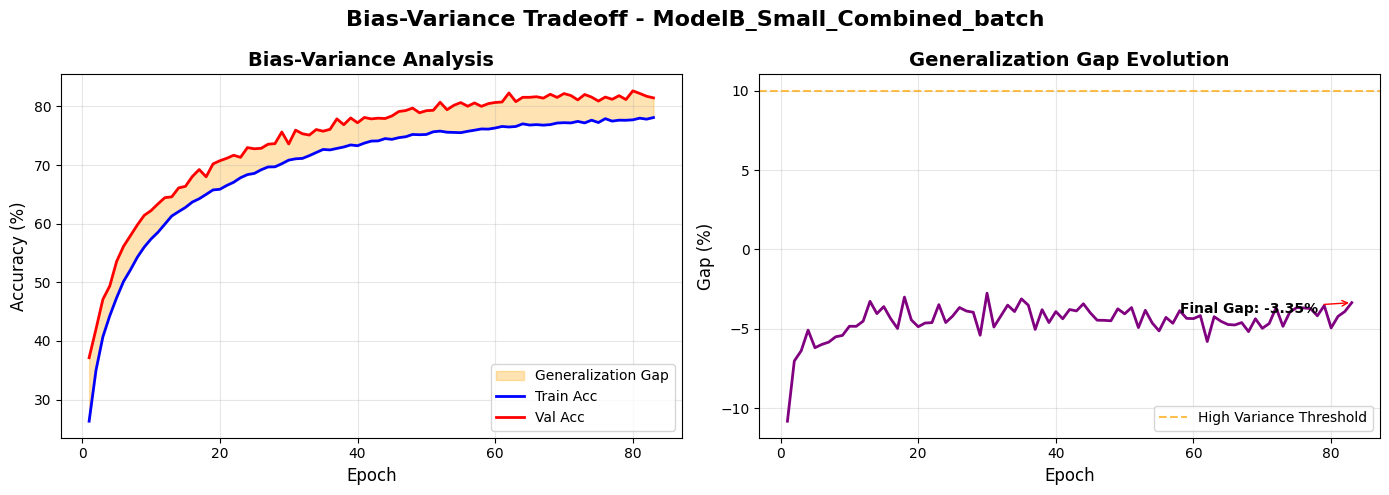

Confusion matrix saved to: results/figures/ModelB_Small_Combined_batch_confusion.png


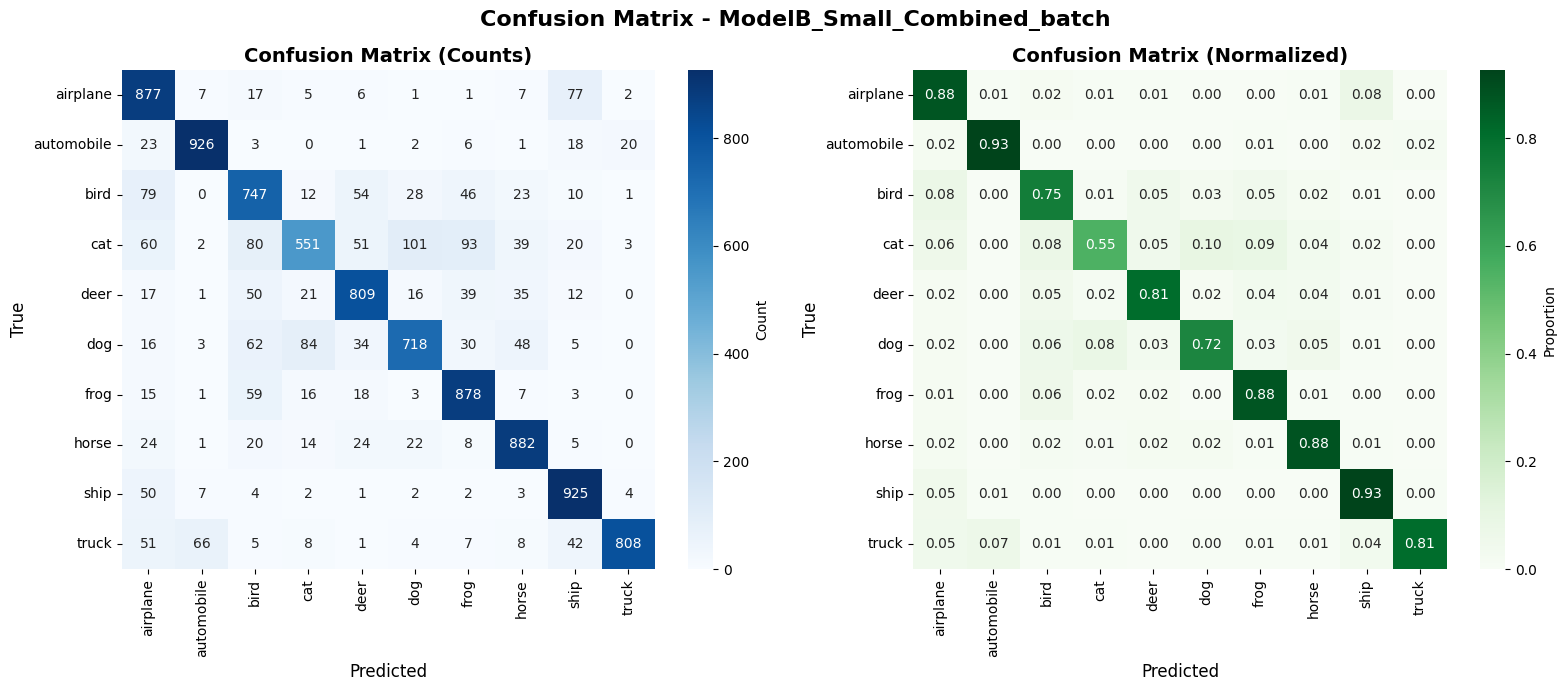


✓ Logged experiment: ModelB_batch_Combined


In [15]:
# Model B - Small - Combined - BatchNorm
results_B_combined_bn = run_experiment(
    model_class=CNN_ModelB_Small,
    model_name='ModelB',
    model_size='Small',
    condition='Combined',
    norm_type='batch',
    weight_decay=5e-4,
    dropout_rate=0.5,
    use_early_stopping=True,
    num_epochs=150,
    learning_rate=0.01,
    batch_size=128
)

<a id='summary'></a>
## Results Summary and Comparison

In [26]:
summary_df = exp_manager.get_summary()
print("\n" + "="*100)
print("ALL EXPERIMENTS SUMMARY")
print("="*100)
display(summary_df)

# Export to formatted CSV
summary_df.to_csv(results_dir / 'csvs' / 'experiments_summary_formatted.csv', index=False)
print(f"\n Summary exported to: {results_dir / 'csvs' / 'experiments_summary_formatted.csv'}")


ALL EXPERIMENTS SUMMARY


,experiment_id,timestamp,model_name,model_size,total_params,trainable_params,norm_type,dropout_rate,weight_decay,learning_rate,...,final_train_loss,final_train_acc,final_val_loss,final_val_acc,test_loss,test_acc,generalization_gap,final_weight_norm,total_time_sec,converged
0,ModelB_batch_NoReg,2026-03-04 12:19:21,ModelB,Small,295380,295380,batch,0.0,0.0000,0.01,...,0.152514,95.088889,0.372502,88.10,0.398493,87.34,6.988889,57.573091,779.047307,False
1,ModelB_batch_WeightDecay,2026-03-04 12:32:34,ModelB,Small,295380,295380,batch,0.0,0.0005,0.01,...,0.269853,91.611111,0.390409,87.00,0.431748,86.34,4.611111,28.529315,787.999051,False
2,ModelB_batch_Combined,2026-03-04 12:43:40,ModelB,Small,295380,295380,batch,0.5,0.0005,0.01,...,0.654828,78.108889,0.546401,81.46,0.560607,81.21,-3.351111,29.144220,660.996183,False
3,ModelA_batch_NoReg,2026-03-04 13:15:15,ModelA,Large,1364372,1364372,batch,0.0,0.0000,0.01,...,0.051289,98.333333,0.323992,90.76,0.350699,90.56,7.573333,70.089073,1639.771191,False
4,ModelA_layer_NoReg,2026-03-04 13:43:16,ModelA,Large,1364372,1364372,layer,0.0,0.0000,0.01,...,0.091721,96.771111,0.358898,89.48,0.395538,88.51,7.291111,71.115407,1676.334189,False
5,ModelA_batch_WeightDecay,2026-03-04 14:10:45,ModelA,Large,1364372,1364372,batch,0.0,0.0005,0.01,...,0.149479,95.022222,0.350425,88.54,0.374806,88.39,6.482222,29.536006,1642.964643,False
6,ModelA_layer_WeightDecay,2026-03-04 14:38:51,ModelA,Large,1364372,1364372,layer,0.0,0.0005,0.01,...,0.213448,92.862222,0.350225,88.94,0.357860,88.58,3.922222,31.328955,1680.666835,False
7,ModelA_batch_Dropout,2026-03-04 15:06:41,ModelA,Large,1364372,1364372,batch,0.5,0.0000,0.01,...,0.414321,85.860000,0.325280,88.40,0.344237,88.52,-2.540000,70.174258,1664.527719,False
8,ModelA_layer_Dropout,2026-03-04 15:34:59,ModelA,Large,1364372,1364372,layer,0.5,0.0000,0.01,...,0.482691,83.493333,0.419653,85.06,0.447003,85.00,-1.566667,69.787432,1692.108113,False
9,ModelA_layer_Combined,2026-03-04 16:01:04,ModelA,Large,1364372,1364372,layer,0.5,0.0005,0.01,...,0.554312,81.364444,0.480405,83.56,0.504096,83.21,-2.195556,31.264111,1559.104122,False



 Summary exported to: results/csvs/experiments_summary_formatted.csv


In [27]:
# Compare by test accuracy
comparison = exp_manager.compare_experiments(metric='test_acc')


Experiment Comparison - Sorted by test_acc
           experiment_id model_name norm_type  test_acc  generalization_gap  total_params
      ModelA_batch_NoReg     ModelA     batch     90.56            7.573333       1364372
ModelA_layer_WeightDecay     ModelA     layer     88.58            3.922222       1364372
    ModelA_batch_Dropout     ModelA     batch     88.52           -2.540000       1364372
      ModelA_layer_NoReg     ModelA     layer     88.51            7.291111       1364372
ModelA_batch_WeightDecay     ModelA     batch     88.39            6.482222       1364372
      ModelB_batch_NoReg     ModelB     batch     87.34            6.988889        295380
ModelB_batch_WeightDecay     ModelB     batch     86.34            4.611111        295380
   ModelA_batch_Combined     ModelA     batch     86.14           -3.031111       1364372
      ModelB_layer_NoReg     ModelB     layer     85.39            5.386667        295380
ModelB_layer_WeightDecay     ModelB     layer     85.05 

### Visualization: Model Comparison


Comparison plot saved to: results/figures/model_comparison_summary.png


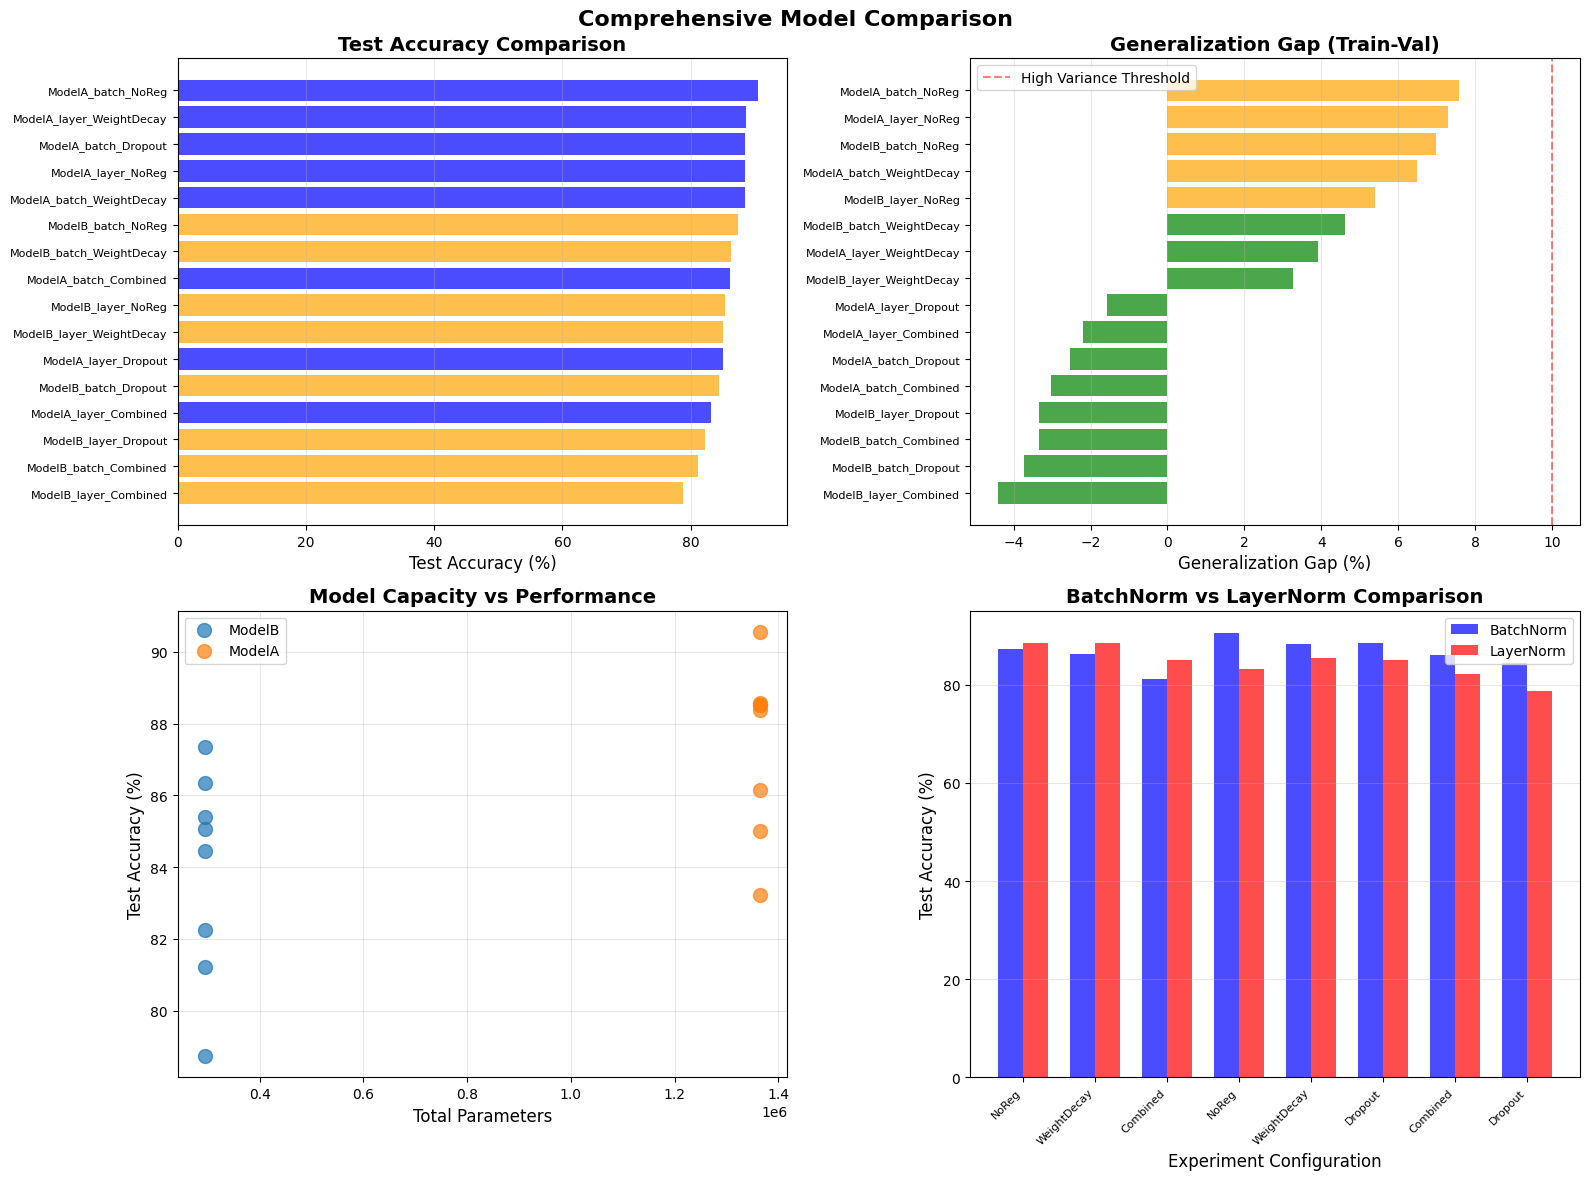

In [28]:
def plot_model_comparison(summary_df: pd.DataFrame):
    """
    Create comprehensive comparison plots across all experiments.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Test accuracy comparison
    ax = axes[0, 0]
    summary_df_sorted = summary_df.sort_values('test_acc', ascending=True)
    colors = ['blue' if 'ModelA' in exp else 'orange' for exp in summary_df_sorted['experiment_id']]
    ax.barh(range(len(summary_df_sorted)), summary_df_sorted['test_acc'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(summary_df_sorted)))
    ax.set_yticklabels(summary_df_sorted['experiment_id'], fontsize=8)
    ax.set_xlabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Generalization gap
    ax = axes[0, 1]
    summary_df_sorted = summary_df.sort_values('generalization_gap')
    colors = ['green' if gap < 5 else 'orange' if gap < 10 else 'red' 
              for gap in summary_df_sorted['generalization_gap']]
    ax.barh(range(len(summary_df_sorted)), summary_df_sorted['generalization_gap'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(summary_df_sorted)))
    ax.set_yticklabels(summary_df_sorted['experiment_id'], fontsize=8)
    ax.set_xlabel('Generalization Gap (%)', fontsize=12)
    ax.set_title('Generalization Gap (Train-Val)', fontsize=14, fontweight='bold')
    ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='High Variance Threshold')
    ax.grid(axis='x', alpha=0.3)
    ax.legend()
    
    # Parameters vs Accuracy
    ax = axes[1, 0]
    for model_name in summary_df['model_name'].unique():
        subset = summary_df[summary_df['model_name'] == model_name]
        ax.scatter(subset['total_params'], subset['test_acc'], 
                  label=model_name, s=100, alpha=0.7)
    ax.set_xlabel('Total Parameters', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Model Capacity vs Performance', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # BatchNorm vs LayerNorm
    ax = axes[1, 1]
    bn_experiments = summary_df[summary_df['norm_type'] == 'batch']
    ln_experiments = summary_df[summary_df['norm_type'] == 'layer']
    
    x = np.arange(len(bn_experiments))
    width = 0.35
    
    ax.bar(x - width/2, bn_experiments['test_acc'].values, width, 
           label='BatchNorm', alpha=0.7, color='blue')
    ax.bar(x + width/2, ln_experiments['test_acc'].values, width,
           label='LayerNorm', alpha=0.7, color='red')
    
    ax.set_xlabel('Experiment Configuration', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('BatchNorm vs LayerNorm Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([exp.split('_')[2] for exp in bn_experiments['experiment_id']], 
                       rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    save_path = results_dir / 'figures' / 'model_comparison_summary.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nComparison plot saved to: {save_path}")
    
    plt.show()

summary_df = exp_manager.get_summary()
# Generate comparison plots
if len(summary_df) > 0:
    plot_model_comparison(summary_df)


## Análisis de Resultados con modelos A y B

**LayerNorm + weight decay** funciona igual en ambos modelos porque controla la complejidad sin destruir capacidad.

LayerNorm normaliza por muestra, lo que evita que el modelo "esconda" la regularización en parámetros de escala como hace BatchNorm. Weight decay encoge los pesos directamente: $$w \leftarrow (1-\eta\lambda)w - \eta\nabla L$$.

Aunque Model B es 4.6 veces más pequeño (296k vs 1.36M parámetros), la misma configuración produce gaps casi idénticos: +3.26% en B vs +3.92% en A. 

Hay equilibrio entre capacidad y regularización escala, el modelo pequeño con esta configuración generaliza incluso un poco mejor (gap más bajo) porque tiene menos capacidad para memorizar, pero suficiente para aprender los patrones relevantes.

Los modelos con más test accuracy (ModelA_batch_NoReg: 90.56%) tienen gaps grandes (+7.57%), implica que su rendimiento en test es engañosamente optimista porque en datos realmente nuevos (con distribución ligeramente distinta) caerían mucho más que los modelos balanceados.

El gap alto posiblemente implica que el modelo memorizó patrones específicos del training set que no existen en test. Por eso ModelA_layer_WeightDecay con 88.58% pero gap +3.92% es más confiable, su accuracy es más "honesta" porque el modelo generaliza un poco más, no solo memoriza.

En producción, esa diferencia de 2% en accuracy no justifica arriesgarse a que el modelo falle estrepitosamente con datos nuevos.


### Conclusión sobre rangos

Se usaron estos rangos para CIFAR-10 con arquitecturas CNN de ~1M parámetros:

- **Gap < 2%**: Sospechoso de underfitting o fuga de datos (train demasiado fácil)
- **Gap 2-5%**: Rango óptimo (modelo generaliza bien)
- **Gap 5-10%**: Overfitting moderado
- **Gap > 10%**: Overfitting severo (modelo memoriza, no generaliza)

In [33]:
# Quantitative overfitting analysis
print("="*80)
print("OVERFITTING ANALYSIS")
print("="*80)

for idx, row in summary_df.iterrows():
    gap = row['generalization_gap']
    
    # Classification based on literature-informed thresholds
    if gap < 2:
        status = "UNDERFITTING"
        interpretation = "Model fails to capture training patterns or data leakage"
    elif 2 <= gap < 5:
        status = "OPTIMAL"
        interpretation = "Ideal generalization range"
    elif 5 <= gap < 10:
        status = "MODERATE OVERFITTING"
        interpretation = "Acceptable if maximizing accuracy is priority"
    else:  # gap >= 10
        status = "SEVERE OVERFITTING"
        interpretation = "Model memorizes training data, poor generalization"
    
    print(f"\n{row['experiment_id']}:")
    print(f"  Train Acc: {row['final_train_acc']:.2f}%")
    print(f"  Val Acc:   {row['final_val_acc']:.2f}%")
    print(f"  Gap:       {gap:.2f}%")
    print(f"  Status:    {status}")
    print(f"  Note:      {interpretation}")

# Summary statistics by status
print("\n" + "="*80)
print("DISTRIBUTION SUMMARY")
print("="*80)

gap_categories = {
    'UNDERFITTING (<2%)': summary_df[summary_df['generalization_gap'] < 2],
    'OPTIMAL (2-5%)': summary_df[(summary_df['generalization_gap'] >= 2) & 
                                  (summary_df['generalization_gap'] < 5)],
    'MODERATE OVERFITTING (5-10%)': summary_df[(summary_df['generalization_gap'] >= 5) & 
                                                (summary_df['generalization_gap'] < 10)],
    'SEVERE OVERFITTING (>10%)': summary_df[summary_df['generalization_gap'] >= 10]
}

for category, subset in gap_categories.items():
    count = len(subset)
    if count > 0:
        avg_acc = subset['test_acc'].mean()
        print(f"\n{category}: {count} experiments")
        print(f"  Mean Test Acc: {avg_acc:.2f}%")
        print(f"  Configs: {', '.join(subset['experiment_id'].tolist())}")
    else:
        print(f"\n{category}: 0 experiments")

OVERFITTING ANALYSIS

ModelB_batch_NoReg:
  Train Acc: 95.09%
  Val Acc:   88.10%
  Gap:       6.99%
  Status:    MODERATE OVERFITTING
  Note:      Acceptable if maximizing accuracy is priority

ModelB_batch_WeightDecay:
  Train Acc: 91.61%
  Val Acc:   87.00%
  Gap:       4.61%
  Status:    OPTIMAL
  Note:      Ideal generalization range

ModelB_batch_Combined:
  Train Acc: 78.11%
  Val Acc:   81.46%
  Gap:       -3.35%
  Status:    UNDERFITTING
  Note:      Model fails to capture training patterns or data leakage

ModelA_batch_NoReg:
  Train Acc: 98.33%
  Val Acc:   90.76%
  Gap:       7.57%
  Status:    MODERATE OVERFITTING
  Note:      Acceptable if maximizing accuracy is priority

ModelA_layer_NoReg:
  Train Acc: 96.77%
  Val Acc:   89.48%
  Gap:       7.29%
  Status:    MODERATE OVERFITTING
  Note:      Acceptable if maximizing accuracy is priority

ModelA_batch_WeightDecay:
  Train Acc: 95.02%
  Val Acc:   88.54%
  Gap:       6.48%
  Status:    MODERATE OVERFITTING
  Note:      

#### Nota: ¿Por qué BatchNorm + weight decay da gap más bajo en Model B que en Model A?

Model B es más pequeño, por ende tiene menos capacidad, aunque BatchNorm permita cierto "escape" de la regularización, el modelo simplemente no tiene parámetros suficientes para memorizar, el weight decay lo restringe aún más, resultando en gap de 4.61% (óptimo).

En Model A, al ser grande, BatchNorm le da justo el espacio para compensar parte del weight decay con sus parámetros de escala, permitiendo algo de overfitting (gap 6.48%),el modelo pequeño no puede hacer eso porque no le alcanza.

### 3.2 Efecto de Weight Decay en las Normas de los Pesos

**Teoría:** Weight decay añade una penalización L2:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \frac{\lambda}{2} \|\mathbf{W}\|_2^2$$

**Actualización del Gradiente:**
$$w \leftarrow (1 - \eta\lambda)w - \eta \frac{\partial \mathcal{L}_{\text{CE}}}{\partial w}$$

El término $(1 - \eta\lambda)$ **reduce los pesos** hacia cero en cada paso.


In [30]:
# Weight norm comparison
print("="*80)
print("WEIGHT NORM ANALYSIS")
print("="*80)

# Group by model and weight decay
for model_name in summary_df['model_name'].unique():
    print(f"\n{model_name}:")
    
    no_wd = summary_df[(summary_df['model_name'] == model_name) & 
                       (summary_df['weight_decay'] == 0.0)]['final_weight_norm']
    with_wd = summary_df[(summary_df['model_name'] == model_name) & 
                        (summary_df['weight_decay'] > 0.0)]['final_weight_norm']
    
    if len(no_wd) > 0 and len(with_wd) > 0:
        print(f"  No Weight Decay:   Mean L2 Norm = {no_wd.mean():.4f}")
        print(f"  With Weight Decay: Mean L2 Norm = {with_wd.mean():.4f}")
        print(f"  Reduction:         {((no_wd.mean() - with_wd.mean()) / no_wd.mean() * 100):.2f}%")

WEIGHT NORM ANALYSIS

ModelB:
  No Weight Decay:   Mean L2 Norm = 57.0014
  With Weight Decay: Mean L2 Norm = 29.3758
  Reduction:         48.46%

ModelA:
  No Weight Decay:   Mean L2 Norm = 70.2915
  With Weight Decay: Mean L2 Norm = 30.8493
  Reduction:         56.11%


## ¿Qué implica la reducción de normas con weight decay?

Los pesos se vuelven más pequeños (norma L2 baja de ~70 a ~30 en Model A, de ~57 a ~29 en Model B).

Debido a que Weight decay resta una fracción de los pesos en cada actualización: $$w \leftarrow (1 - \eta\lambda)w - \eta \nabla L$$. Es como un "impuesto" que paga el peso por ser grande.

Pesos más pequeños significan:
- El modelo depende menos de neuronas individuales
- Las decisiones se distribuyen entre más neuronas
- La red es más robusta al ruido
- Menos riesgo de overfitting porque no hay pesos enormes memorizando patrones específicos

Sin weight decay las normas son altas (memorización), con weight decay bajan a la mitad (generalización). La reducción es mayor en Model A (56%) porque tiene más pesos que podían crecer sin control.

---

### 3.3 Efecto del Dropout en el Flujo del Gradiente

El dropout apaga neuronas al azar durante el entrenamiento haciendo que el gradiente solo pase por las neuronas que quedan activas, creando caminos diferentes en cada paso.

Como cada vez se usa un subconjunto distinto de neuronas, la red aprende a no depender de ninguna en particular.

El resultado es que el entrenamiento se vuelve más lento y ruidoso, pero el modelo final generaliza mejor porque no memoriza patrones basados en combinaciones específicas de neuronas.

En este caso todas las configuraciones con dropout terminaron en underfitting, en lugar de prevenir overfitting, el dropout fue tan agresivo que impidió que el modelo aprendiera lo suficiente. Los gaps negativos (train < test) indican que la red nunca alcanzó su capacidad real porque el flujo del gradiente estaba constantemente interrumpido, especialmente en el modelo pequeño.

### 3.4 Impacto de BatchNorm en la Estabilidad de Optimización

BatchNorm normaliza las entradas de cada capa: $$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$ Lo que mantiene distribuciones estables durante el entrenamiento.

Esto permite usar learning rates más altos sin divergir, suaviza y acelera la convergencia y el ruido de las estadísticas del mini-batch actúa como regularizador.

En los experimentos, BatchNorm converge más rápido y con curvas más suaves que LayerNorm.

In [34]:
# BatchNorm vs LayerNorm convergence analysis
print("="*80)
print("BATCH NORMALIZATION vs LAYER NORMALIZATION")
print("="*80)

# Compare same configurations with different normalizations
bn_results = summary_df[summary_df['norm_type'] == 'batch']
ln_results = summary_df[summary_df['norm_type'] == 'layer']

print(f"\nBatchNorm Results (n={len(bn_results)}):")
print(f"  Mean Test Acc:      {bn_results['test_acc'].mean():.2f}%")
print(f"  Mean Gen Gap:       {bn_results['generalization_gap'].mean():.2f}%")
print(f"  Mean Best Epoch:    {bn_results['best_epoch'].mean():.1f}")

if len(ln_results) > 0:
    print(f"\nLayerNorm Results (n={len(ln_results)}):")
    print(f"  Mean Test Acc:      {ln_results['test_acc'].mean():.2f}%")
    print(f"  Mean Gen Gap:       {ln_results['generalization_gap'].mean():.2f}%")
    print(f"  Mean Best Epoch:    {ln_results['best_epoch'].mean():.1f}")
    
    print("\nDifference (BatchNorm - LayerNorm):")
    print(f"  Δ Test Acc:         {bn_results['test_acc'].mean() - ln_results['test_acc'].mean():.2f}%")
    print(f"  Δ Convergence:      {bn_results['best_epoch'].mean() - ln_results['best_epoch'].mean():.1f} epochs")

BATCH NORMALIZATION vs LAYER NORMALIZATION

BatchNorm Results (n=8):
  Mean Test Acc:      86.62%
  Mean Gen Gap:       1.62%
  Mean Best Epoch:    84.4

LayerNorm Results (n=8):
  Mean Test Acc:      84.59%
  Mean Gen Gap:       1.04%
  Mean Best Epoch:    94.6

Difference (BatchNorm - LayerNorm):
  Δ Test Acc:         2.03%
  Δ Convergence:      -10.2 epochs


## BatchNorm vs LayerNorm

BatchNorm da más accuracy (86.62% vs 84.59%) y converge antes (epoch 84 vs 95). LayerNorm tiene gap un poco más bajo (1.04% vs 1.62%).

BatchNorm normaliza con estadísticas del batch, lo que estabiliza el entrenamiento y permite avanzar más rápido. LayerNorm normaliza por muestra, es más estable pero lento.

Para accuracy máxima y entrenamiento rápido, BatchNorm es mejor. LayerNorm solo conviene si priorizas minimizar overfitting.

## Part 4 Analysis: Engineering Constraint Performance

### Comparison: Model A (Large) vs Model B (Small)

In [32]:
print("="*80)
print("MODEL SIZE COMPARISON: Large vs Small")
print("="*80)

model_a_results = summary_df[summary_df['model_name'] == 'ModelA']
model_b_results = summary_df[summary_df['model_name'] == 'ModelB']

print(f"\nModel A (Large):")
print(f"  Parameters:         {model_a_results['total_params'].iloc[0]:,} ({model_a_results['total_params'].iloc[0]/1e6:.2f}M)")
print(f"  Best Test Acc:      {model_a_results['test_acc'].max():.2f}%")
print(f"  Mean Test Acc:      {model_a_results['test_acc'].mean():.2f}%")
print(f"  Mean Gen Gap:       {model_a_results['generalization_gap'].mean():.2f}%")

if len(model_b_results) > 0:
    print(f"\nModel B (Small):")
    print(f"  Parameters:         {model_b_results['total_params'].iloc[0]:,} ({model_b_results['total_params'].iloc[0]/1e6:.2f}M)")
    print(f"  Best Test Acc:      {model_b_results['test_acc'].max():.2f}%")
    print(f"  Mean Test Acc:      {model_b_results['test_acc'].mean():.2f}%")
    print(f"  Mean Gen Gap:       {model_b_results['generalization_gap'].mean():.2f}%")
    
    print("\nPerformance Trade-off:")
    acc_diff = model_a_results['test_acc'].max() - model_b_results['test_acc'].max()
    param_ratio = model_a_results['total_params'].iloc[0] / model_b_results['total_params'].iloc[0]
    
    print(f"  Accuracy Loss:      {acc_diff:.2f}%")
    print(f"  Parameter Reduction: {param_ratio:.2f}x")
    print(f"  Efficiency:         {acc_diff / param_ratio:.4f}% per million params")
    
    print("\n" + "="*80)
    print("CONCLUSION")
    print("="*80)
    if acc_diff < 3:
        print(f"Model B (Small) achieves comparable performance with {param_ratio:.1f}x fewer parameters.")
        print("The engineering constraint is satisfied with minimal performance degradation.")
    else:
        print(f"Model B (Small) sacrifices {acc_diff:.2f}% accuracy for {param_ratio:.1f}x parameter reduction.")
        print("Trade-off depends on deployment requirements (accuracy vs efficiency).")

MODEL SIZE COMPARISON: Large vs Small

Model A (Large):
  Parameters:         1,364,372 (1.36M)
  Best Test Acc:      90.56%
  Mean Test Acc:      87.36%
  Mean Gen Gap:       1.99%

Model B (Small):
  Parameters:         295,380 (0.30M)
  Best Test Acc:      87.34%
  Mean Test Acc:      83.85%
  Mean Gen Gap:       0.68%

Performance Trade-off:
  Accuracy Loss:      3.22%
  Parameter Reduction: 4.62x
  Efficiency:         0.6971% per million params

CONCLUSION
Model B (Small) sacrifices 3.22% accuracy for 4.6x parameter reduction.
Trade-off depends on deployment requirements (accuracy vs efficiency).


## Accuracy vs efficiency para los mejores modelos

El modelo pequeño pierde 3.22% de accuracy pero usa 4.6 veces menos parámetros que el modelo más grande.

Más parámetros dan más capacidad para aprender patrones complejos, pero también más riesgo de overfitting, el modelo pequeño se defiende con solo una cuarta parte de los parámetros logra casi la misma accuracy que el grande en sus mejores configuraciones.
